# Cas d'usage 01 — Résiliation client SaaS (churn)
### Certification « Concevoir et implémenter une solution d'intelligence artificielle »

| | |
|---|---|
| **Candidat** | Haja RAKOTOVOALAVO PETERA |
| **Date de remise** | 05/10/2026 |
| **Version du notebook** | v2.0 — sections 0 à 7 alignées sur les phases 1 à 4 du projet |
| **Environnement d'exécution** | Python 3.11 · pandas 3.0 · numpy 2.4 · scikit-learn 1.9 · matplotlib 3.11 · seaborn 0.13 — versions exactes verrouillées dans `uv.lock`, relevées en Annexe A |
| **Dépôt** | Code testé dans `src/churn_saas/`, tests dans `tests/`, documents dans `docs/` |

---

**Modalités d'évaluation.** Ce notebook constitue la *production écrite* (production sur jeux de données
+ journal de bord). Il est complété par une soutenance orale de 30 minutes suivie de 30 minutes d'échanges
avec le jury. Les deux modalités pèsent à parité dans l'évaluation du cas d'usage.

**Couverture des compétences.** Chaque section porte le marqueur `[Cn]` de la compétence qu'elle démontre.
La table de correspondance complète entre les critères du référentiel et leur emplacement dans ce document
figure en **Annexe B** (section 15).

**Comment ce notebook est construit.** Le code n'est écrit qu'une fois, dans le paquet `src/churn_saas/`,
couvert par plus de 400 tests. Le notebook l'importe et **affiche le code au moment où il l'explique**
(`afficher_source`) : le code montré est exactement celui qui s'exécute (Annexe E). Chaque chiffre cité
dans le texte est calculé dans une cellule du notebook et figé par un test de non-régression.

**Documents compagnons.** `docs/05.REGISTRE_elements_ecartes.md` recense ce qui a été écarté, différé ou
laissé en attente d'arbitrage ; `docs/00.REGLES_DE_TRAVAIL.md` consigne les règles suivies ;
`docs/04.SOUTENANCE_phases_4_a_11.md` prépare l'oral.

In [1]:
# --- Environment ---------------------------------------------------------------------
# Make the package importable whether or not it is installed: the notebook must run
# straight from an unzipped archive, without `uv sync` (Annex E).
import sys
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from churn_saas.config import FICHIER_CATALOGUE, FICHIER_COMPLET
from churn_saas.notebook import afficher_source, afficher_tableau

pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"Racine du projet : {RACINE.name} — Python {sys.version.split()[0]}, pandas {pd.__version__}")

Racine du projet : ai4me — Python 3.11.15, pandas 3.0.6


## 1. Résumé exécutif

**Problème.** Prédire la résiliation (churn) d'un compte client B2B SaaS à l'échéance de son contrat, à
partir de données d'usage, de facturation, de support et de caractéristiques contractuelles.

**Objectif métier.** Fournir aux équipes Customer Success une **liste priorisée** des comptes à contacter
chaque mois, dans la limite de leur capacité (≈ 140 comptes) — une aide à la décision, jamais une décision
automatique.

**Approche.**
- Cible principale : `churn` (classification binaire, 28 % de résiliations).
- Priorisation par **valeur espérée** — probabilité × valeur du compte — plutôt que par probabilité seule :
  10 % des comptes qui résilient portent 72 % du revenu perdu (§ 2, § 9).
- Cible secondaire : `valeur_vie_client_eur`, utilisée comme **pondération de la décision**, jamais comme
  variable explicative.

**Acquis des phases de préparation (sections 2 à 7).**
- Un jeu d'apprentissage figé et versionné : 5 000 comptes, 18 variables explicatives, empreinte
  enregistrée dans un manifeste et vérifiée par les tests.
- Quatre défauts silencieux trouvés en mesurant, et corrigés : 2 302 lignes perdues par une jointure
  sensible à la casse, 26 catégories fantômes, 570 délais effacés par une unité non reconnue, 960 dates
  lues jour et mois inversés.
- Le signal le plus fort du jeu est une **absence** : les 297 comptes sans aucun utilisateur actif
  résilient à 86,5 %, contre 24,3 % pour les autres.
- Un contrat de données de neuf contrôles, appliqué à l'identique à l'entraînement et au lot mensuel.

**Résultats de modélisation et limites.** *(Rédigés en dernier, après les sections 8 à 13 : performance
retenue, comptes signalés, impact estimé, limites. Action N2 du plan.)*

## 2. Cadrage métier et cas d'usage — journal de bord [C1]

**Contexte.** Éditeur SaaS B2B, revenus récurrents (MRR), churn = enjeu de rentabilité et de croissance.

**Cas d'usage IA.** Score de risque de churn par compte, calculé avant l'échéance contractuelle, pour prioriser les
actions de rétention des équipes Customer Success.

**Ce que le modèle n'est pas.** Pas un outil de décision automatique de résiliation/rétention ; pas un substitut au
jugement humain du CSM (Customer Success Manager).

**Utilisateurs finaux.** Équipes Customer Success, éventuellement Sales Ops pour le reporting.

**Journal de bord [C1] :**
- Décision : cibler le churn *contractuel à l'échéance* (et non un churn "à tout moment"), car c'est la fenêtre
  d'action pertinente pour le Customer Success.
- Décision : traiter `valeur_vie_client_eur` comme éclairage métier complémentaire (priorisation des comptes à
  forte valeur), jamais comme feature d'entrée du modèle churn (cf. section 3.2 de l'énoncé).

**Hypothèses et contraintes.**

| Nature | Énoncé |
|---|---|
| Hypothèse | Les données fournies sont représentatives du portefeuille réel de comptes |
| Hypothèse | Une action de rétention menée à temps a un effet non nul sur la décision du client |
| Hypothèse | Le coût d'un compte perdu excède le coût d'une action de rétention inutile — **vérifié en § 4 : vrai pour la plupart des comptes, pas pour les plus petits** |
| Contrainte | Décision humaine obligatoire — aucun déclenchement automatique |
| Contrainte | Fenêtre d'action : quelques semaines avant l'échéance contractuelle |
| Contrainte | Score restitué dans le CRM existant, sans outil supplémentaire pour les CSM |
| Contrainte | Explicabilité exigée : un CSM doit comprendre pourquoi un compte est signalé |

**Critères de réussite.**

| Niveau | Critère |
|---|---|
| Technique | Modèle supérieur à la baseline sur le PR-AUC, performance stable en validation croisée |
| Opérationnel | Volume de comptes signalés compatible avec la capacité de traitement des CSM |
| Métier | Taux de rétention des comptes signalés supérieur à celui des comptes non signalés |
| Conformité | Aucune variable sensible ou en fuite dans le modèle, traçabilité des décisions |

**Cadre de suivi défini dès le cadrage.** La pertinence des indicateurs de performance et de leurs seuils est
révisée **trimestriellement**, au même rythme que le réentraînement (mise en œuvre en section 13). Fixer cette
périodicité dès la phase de cadrage évite qu'un dispositif de suivi conçu à la mise en service reste inchangé
alors que le contexte métier a évolué.

**Journal de bord [C1] — complément :**
- Décision : retenir comme critère de réussite métier l'écart de rétention entre comptes signalés et non
  signalés, et non la performance statistique. Motif : un modèle excellent dont les alertes ne changent rien
  au comportement des équipes ne crée aucune valeur.
- Décision : inscrire la contrainte de volume dès le cadrage. Motif : le seuil de décision doit produire un
  nombre de comptes traitable par les CSM — une contrainte opérationnelle, pas seulement statistique.

### Ordres de grandeur métier constatés sur les données

Ces chiffres, établis avant toute modélisation, conditionnent le cadrage de la solution. Ils sont
**calculés** par la cellule suivante, sur les données nettoyées (§ 7).

Constat,Valeur
Lignes reçues,5 035
Comptes uniques,5 000 (35 doublons stricts)
Taux de churn,28.0% — 1 400 comptes
MRR mensuel total,17.2 M€
MRR porté par les comptes qui résilient,"4.0 M€, soit 23%"
Part du MRR portée par 1 % des comptes,17%
Part du MRR portée par 10 % des comptes,68%
Part du MRR perdu portée par 10 % des churners,72%


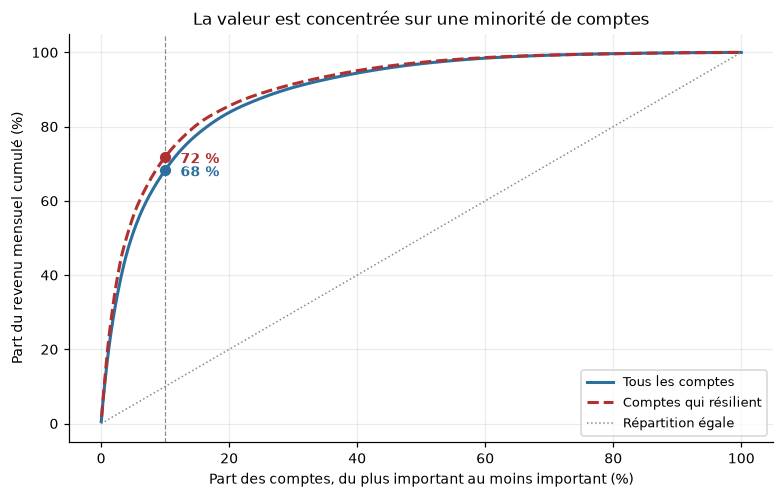

In [2]:
# --- Business orders of magnitude, computed rather than quoted -----------------------
from churn_saas.donnees import charger_bronze, construire_silver
from churn_saas.features import construire_silver_standard
from churn_saas.features import tracer_concentration

# Cleaned data are needed from here on; the cleaning itself is explained in section 7.
bronze = charger_bronze(FICHIER_COMPLET)
catalogue = charger_bronze(FICHIER_CATALOGUE)
silver = construire_silver_standard(bronze, catalogue=catalogue)

churn = silver["churn"].astype(float)
mrr = silver["revenu_mensuel_recurrent_eur"]


def part_portee(valeurs, part):
    # Share of the total carried by the largest `part` of the values.
    v = valeurs.dropna().sort_values(ascending=False)
    return v.head(int(len(v) * part)).sum() / v.sum()


ordres = pd.DataFrame([
    ("Lignes reçues", f"{len(bronze):,}".replace(",", " ")),
    ("Comptes uniques", f"{len(silver):,}".replace(",", " ")
     + f" ({len(bronze) - len(silver)} doublons stricts)"),
    ("Taux de churn", f"{churn.mean():.1%} — {int(churn.sum()):,} comptes".replace(",", " ")),
    ("MRR mensuel total", f"{mrr.sum() / 1e6:.1f} M€"),
    ("MRR porté par les comptes qui résilient",
     f"{mrr[churn == 1].sum() / 1e6:.1f} M€, soit {mrr[churn == 1].sum() / mrr.sum():.0%}"),
    ("Part du MRR portée par 1 % des comptes", f"{part_portee(mrr, 0.01):.0%}"),
    ("Part du MRR portée par 10 % des comptes", f"{part_portee(mrr, 0.10):.0%}"),
    ("Part du MRR perdu portée par 10 % des churners", f"{part_portee(mrr[churn == 1], 0.10):.0%}"),
], columns=["Constat", "Valeur"])
afficher_tableau(ordres, titre="Ordres de grandeur du portefeuille")

tracer_concentration(mrr, churn)
plt.show()

**Conséquence de cadrage.** La valeur est très concentrée : traiter les 10 % de churners les plus importants
couvrirait près des trois quarts du revenu à risque. Le problème n'est donc pas de détecter *tous* les
départs, mais de détecter ceux qui comptent. Cela oriente la solution vers une **priorisation par valeur**
plutôt que vers une maximisation du rappel global (voir section 9).

**Périmètre temporel — hypothèse de lecture des données.** Le jeu de données est un **instantané** : chaque
ligne décrit un compte et l'issue observée à son échéance, sans horodatage de la décision. Les 1 400
résiliations ne sont donc pas un flux mensuel mais un cumul sur la période couverte. Hypothèse retenue pour
raisonner en volumétrie : ces résiliations se répartissent sur environ douze mois, soit de l'ordre de
**115 à 120 échéances à risque par mois**. Cette hypothèse est explicitée car elle conditionne le
dimensionnement de la capacité ci-dessous ; elle serait à remplacer par le calendrier réel des échéances en
situation opérationnelle.

**Articulation avec la fenêtre de décision.** Le scoring est mensuel, mais la décision se prend à l'échéance
contractuelle de chaque compte. Le lot mensuel n'a donc pas vocation à traiter tout le portefeuille : il
cible les comptes dont l'échéance approche, croisés avec leur score de risque (cf. section 11).

**Capacité de traitement — hypothèse structurante.** Le nombre de comptes actionnables par mois est une
contrainte dure, indépendante du modèle. Hypothèse retenue : **≈ 140 comptes par mois**, soit l'ordre de
grandeur permettant de couvrir les 10 % de churners les plus valorisés. Cette valeur est à confirmer auprès
du commanditaire ; elle détermine directement le point de fonctionnement du modèle.

**Journal de bord [C1] — complément :**
- Décision : établir les ordres de grandeur métier avant la modélisation, et non après. Motif : ils
  déterminent le type de solution à construire — ici, un outil de priorisation et non un détecteur exhaustif.
- Décision : traiter la capacité CSM comme une contrainte de cadrage et non comme un paramètre d'ajustement
  a posteriori. Motif : un modèle qui signale plus de comptes que l'équipe ne peut en traiter ne produit
  aucune action supplémentaire.
- Correction tardive, signalée : trois écarts entre segments publiés au cadrage étaient surestimés d'un
  facteur deux, calculés sur des catégories mal orthographiées. Ils ont été corrigés en phase 3 (§ 6.4) ;
  la conclusion du cadrage — aucun segment ne justifie une règle métier à la place d'un modèle — en sort
  renforcée.

### Cycle de vie du projet et positionnement des sections

La démarche suit un cycle de vie itératif, et non un enchaînement linéaire. Le plan du notebook étant imposé
et séquentiel, cette table établit la correspondance entre les deux lectures.

```mermaid
flowchart LR
    A[Cadrage] --> B[Données]
    B --> C[Features]
    C --> D[Modélisation]
    D --> E[Évaluation]
    E --> F[Packaging]
    F --> G[Industrialisation]
    G --> H[Monitoring]
    H -. dérive / nouvelle donnée .-> B
    E -. score insuffisant .-> C
    D -. signal faible .-> A
```

*(Le diagramme est reproduit par la figure générée ci-dessous, Jupyter ne rendant pas nativement la syntaxe
Mermaid.)*

| Étape du cycle | Sections du notebook |
|---|---|
| **A — Cadrage** | 2 (besoin, contraintes, critères) · 4 (cadre éthique et réglementaire) |
| **B — Données** | 3 (sources, gouvernance, cycle de vie) · 5 (chargement, contrôles) |
| **C — Features** | 6 (analyse exploratoire) · 7 (nettoyage, transformations, variables construites) |
| **D — Modélisation** | 8 (familles, baseline, démarche) · 9 (entraînement, validation) |
| **E — Évaluation** | 9 (validation avant industrialisation) · 12 (performance et impacts en exploitation) |
| **F — Packaging** | 10 (sérialisation, versioning, fiche modèle) |
| **G — Industrialisation** | 10 (chaîne CI/CD, intégration) · 11 (architecture cible) |
| **H — Monitoring** | 13 (dérive, seuils, réentraînement) |

**Écart assumé entre le cycle et le plan imposé.** Le règlement place l'implémentation (10) et l'architecture
(11) *avant* la mesure de performance (12), alors que le cycle évalue avant de packager. Il n'y a pas de
contradiction : l'évaluation se déroule en deux temps distincts. La **validation avant mise en service**
(section 9) décide si le modèle mérite d'être industrialisé ; la **mesure en exploitation** (section 12)
vérifie ce qu'il produit réellement une fois déployé. Le plan du notebook suit l'ordre du règlement ; la
démarche réelle suit le cycle.

**Les boucles de rétroaction** sont documentées là où elles se sont produites : *exploration → cadrage* en
§ 6.4, *exploration → préparation* en § 6.3 et § 7, *modélisation → cadrage* en section 8, *évaluation →
features* en section 9, *monitoring → données* en section 13. Le journal des itérations (Annexe D) les
récapitule.

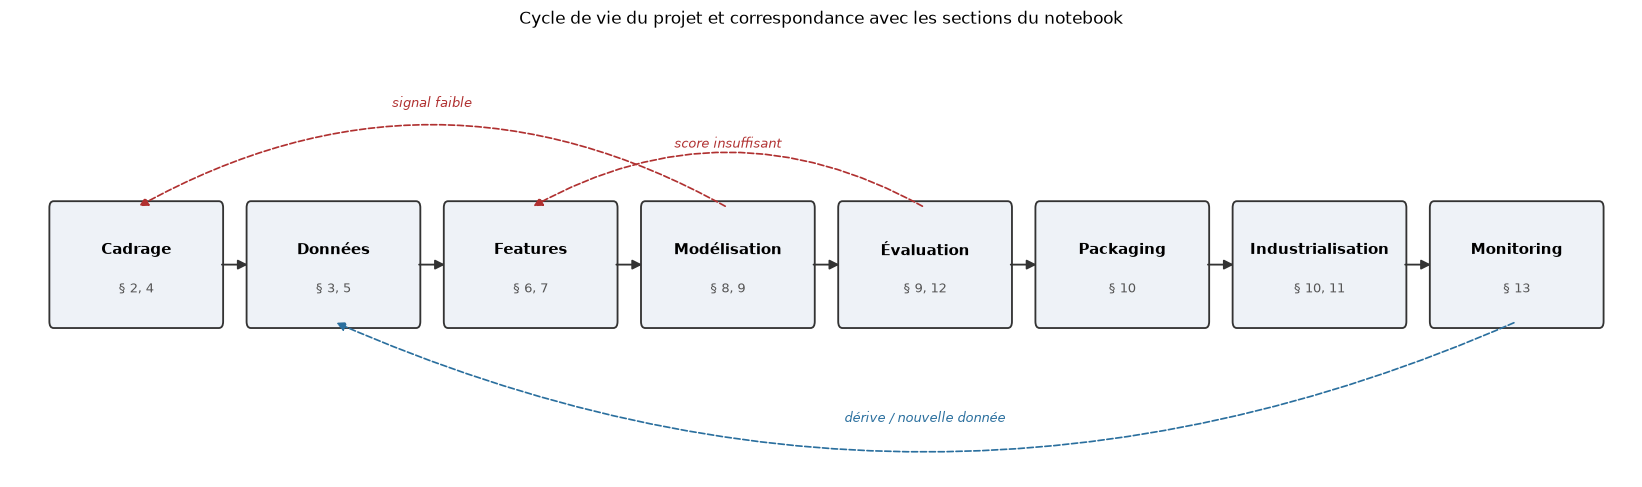

In [3]:
# Figure: project lifecycle (matplotlib rendering of the Mermaid diagram above)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

etapes = ["Cadrage", "Données", "Features", "Modélisation",
          "Évaluation", "Packaging", "Industrialisation", "Monitoring"]
sections = ["2, 4", "3, 5", "6, 7", "8, 9", "9, 12", "10", "10, 11", "13"]

fig, ax = plt.subplots(figsize=(15, 4.5))
largeur, hauteur = 1.55, 0.7

for i, (etape, sec) in enumerate(zip(etapes, sections)):
    x = i * 1.85
    ax.add_patch(FancyBboxPatch((x, 0), largeur, hauteur,
                                boxstyle="round,pad=0.04", linewidth=1.2,
                                edgecolor="#333333", facecolor="#eef2f7"))
    ax.text(x + largeur / 2, 0.44, etape, ha="center", va="center",
            fontsize=10, fontweight="bold")
    ax.text(x + largeur / 2, 0.20, f"§ {sec}", ha="center", va="center",
            fontsize=8.5, color="#555555")
    if i < len(etapes) - 1:
        ax.add_patch(FancyArrowPatch((x + largeur, hauteur / 2), (x + 1.85, hauteur / 2),
                                     arrowstyle="-|>", mutation_scale=13,
                                     linewidth=1.2, color="#333333"))

# Feedback loops
boucles = [
    (3, 0, 1.30, "signal faible", "#b03030"),   # Modelling -> Framing
    (4, 2, 1.05, "score insuffisant", "#b03030"),  # Evaluation -> Features
]
for src, dst, haut, libelle, couleur in boucles:
    xs = src * 1.85 + largeur / 2
    xd = dst * 1.85 + largeur / 2
    ax.add_patch(FancyArrowPatch((xs, hauteur), (xd, hauteur),
                                 connectionstyle=f"arc3,rad=0.28",
                                 arrowstyle="-|>", mutation_scale=12, linewidth=1.1,
                                 linestyle="--", color=couleur))
    ax.text((xs + xd) / 2, haut, libelle, ha="center", va="bottom",
            fontsize=8.5, color=couleur, style="italic")

# Monitoring -> Data (drawn underneath)
xs, xd = 7 * 1.85 + largeur / 2, 1 * 1.85 + largeur / 2
ax.add_patch(FancyArrowPatch((xs, 0), (xd, 0),
                             connectionstyle="arc3,rad=-0.22",
                             arrowstyle="-|>", mutation_scale=12, linewidth=1.1,
                             linestyle="--", color="#2a6f9e"))
ax.text((xs + xd) / 2, -0.55, "dérive / nouvelle donnée", ha="center", va="top",
        fontsize=8.5, color="#2a6f9e", style="italic")

ax.set_xlim(-0.4, len(etapes) * 1.85)
ax.set_ylim(-0.95, 1.7)
ax.axis("off")
ax.set_title("Cycle de vie du projet et correspondance avec les sections du notebook",
             fontsize=11, pad=14)
plt.tight_layout()
plt.show()

## 3. Données : disponibilité, gouvernance et alternatives — journal de bord [C1] [C3]

**Sources fournies.**

| Fichier | Contenu | Usage |
|---|---|---|
| `data/raw/churn_saas_complet.csv` | 5 035 lignes, 29 colonnes | Entraînement et évaluation |
| `data/raw/churn_saas_echantillon.csv` | 50 lignes, mêmes colonnes | Simulation du lot mensuel (§ 10) |
| `data/raw/catalogue_plans.csv` | 4 plans : prix par siège, fonctionnalités, SLA, stockage, support dédié | Jointure sur `plan` |

**Gouvernance et propriété.** Données internes (usage, facturation, support), propriété de l'éditeur. Le
champ `commentaire_csm` est un texte libre susceptible de contenir des données personnelles : il est
analysé en § 4 et exclu du modèle.

**Disponibilité et accès — vérifications effectuées.**

| Point contrôlé | Constat | Où |
|---|---|---|
| Existence et intégrité des fichiers | Présents, empreintes SHA-256 conformes au manifeste | cellule ci-dessous |
| Encodage | BOM UTF-8 en tête de fichier, retiré à la lecture | § 5 |
| Clé de jointure `plan` | `STARTER` / `Starter` : **54,3 % d'appariement sans normalisation**, 100 % avec | cellule ci-dessous |
| Doublons | 35 lignes strictement identiques | § 6.1 |
| Droits d'usage | Données internes, usage interne d'aide à la décision | § 4 |

**Le défaut le plus coûteux ne fait pas de bruit.** Sans normalisation de la casse, la jointure avec le
catalogue ne lève aucune erreur : les lignes non appariées disparaissent simplement — 2 302 comptes, près
de la moitié du jeu. C'est le premier défaut silencieux du projet, et il a fixé une règle de travail :
tester en priorité ce qui casse sans bruit.

In [4]:
# --- Join control and data integrity -------------------------------------------------
from churn_saas.donnees import charger_manifeste, controler_jointure, verifier_manifeste

afficher_tableau(controler_jointure(bronze, catalogue, cle="plan"),
                 titre="Jointure avec le catalogue : sans puis avec normalisation de la clé")

manifeste = charger_manifeste(RACINE / "data" / "manifeste_v1.0.json")
afficher_tableau(verifier_manifeste(manifeste, racine=RACINE),
                 titre="Les fichiers lus sont-ils ceux que le manifeste décrit ?")

méthode de jointure,taux d'appariement,lignes perdues
Sur la valeur brute,54.3%,2302
"Après normalisation (casse, espaces)",100.0%,0


source,présent,empreinte attendue,empreinte constatée,conforme
jeu complet,True,2fc45e8c3c74d3dd…,2fc45e8c3c74d3dd…,True
échantillon,True,680f5371c406f47a…,680f5371c406f47a…,True
catalogue des plans,True,c94f6f52652532c5…,c94f6f52652532c5…,True


**Solutions alternatives en cas d'indisponibilité des données.** Ces scénarios sont anticipés car ils
conditionnent la viabilité de la solution en production, pas seulement dans ce notebook.

| Indisponibilité | Alternative retenue |
|---|---|
| Perte d'accès au référentiel des plans | Dégradation maîtrisée : le modèle tourne sans les variables du catalogue, au prix d'une performance moindre, à mesurer ; le revenu manquant ne peut alors plus être reconstruit (§ 7) |
| Variable d'usage manquante pour un compte | Médiane apprise à l'entraînement, ou reconstruction si la ligne le permet (§ 7). **Pas d'indicateur de manque** : l'absence d'une valeur reçue n'est pas un signal (mesuré en § 6.1) |
| Taux de manquants anormal sur un lot | Le contrat de données le signale au-delà de 10 % et bloque le lot au-delà de 50 % (§ 5) |
| Indisponibilité complète de l'historique d'usage | Repli sur un modèle restreint aux variables contractuelles et de facturation, moins performant mais opérationnel |
| Volumétrie insuffisante pour réentraîner | Maintien du modèle en place, alerte au commanditaire, réentraînement différé |

**Modèle de stockage retenu.**

| Objet | Support | Versionné dans Git | Motif |
|---|---|---|---|
| Sources (bronze) | CSV dans `data/raw/` | **Oui** | 2 Mo : Git suffit, et c'est la référence de tout le reste |
| Manifeste | `data/manifeste_v1.0.json` | **Oui** | Empreintes des sources et des jeux dérivés : c'est le contrat de reproductibilité |
| Jeux dérivés (silver, gold) | Parquet dans `data/processed/` | Non | Recalculables depuis sources + code ; le typage survit à l'aller-retour, contrairement au CSV |
| Scores produits | Base relationnelle (PostgreSQL) | Non | On les interroge, on ne les versionne pas |

Une base orientée documents (aucun schéma variable) et un entrepôt distribué (volumétrie très inférieure au
seuil de pertinence) ont été écartés.

**Un revirement documenté : Git-LFS.** Les CSV avaient d'abord été placés sous Git-LFS. Un clone sans
l'extension récupère des pointeurs de 128 octets au lieu de 700 000 — **sans aucune erreur**. À ce volume,
LFS ajoute un risque sans bénéfice ; il a été retiré (registre, E-201).

**Une empreinte qui dépendait du système.** L'empreinte des jeux dérivés était calculée différemment sous
Windows et sous Linux (fins de ligne). Le manifeste écrit sur un poste ne pouvait donc pas correspondre à
celui de l'intégration continue. Le défaut, présent depuis la phase 2, n'a été vu qu'en phase 4, quand un
test a commencé à comparer le manifeste versionné à ce que produit le code.

**Cycle de vie du jeu de données.**

| Étape | Contenu | Durée / rythme | Responsable |
|---|---|---|---|
| Collecte | Extraction depuis les systèmes d'usage, facturation et support | Mensuelle | Équipe Data |
| Préparation | Nettoyage, contrat de données, jointure, variables construites (§ 5 à 7) | À chaque extraction | Équipe Data |
| Instantané d'entraînement | Figé, empreinte enregistrée au manifeste | À chaque réentraînement (trimestriel) | Équipe Data |
| Exploitation | Scoring, écriture des résultats dans le CRM | Mensuelle | Équipe Data / Ops CRM |
| Conservation des scores | Historique nécessaire au suivi de dérive | À arbitrer avec le DPO | DPO |
| Archivage | Instantanés conservés pour audit et retour arrière | Alignée sur les versions de modèle actives | Équipe Data |
| Purge | Suppression au-delà de la durée retenue | Automatisée | Équipe Data / DPO |

**Soumission aux parties prenantes.** Ce cycle de vie est présenté au DPO pour validation des durées de
conservation et de la base légale, au commanditaire pour l'arbitrage sur la profondeur d'historique, et à
l'équipe infrastructure pour la faisabilité de l'archivage et de la purge automatisée. La durée de
conservation des scores est le point ouvert : le suivi de dérive demande de la profondeur, la minimisation
des données demande l'inverse.

**Journal de bord [C1] / [C3] :**
- Décision : normaliser la clé de jointure, et **mesurer** l'effet plutôt que le supposer (54,3 % → 100 %).
- Décision : versionner les sources dans Git et les jeux dérivés par empreinte, plutôt que par LFS ou DVC.
  Motif : à 2 Mo, la simplicité est la robustesse ; DVC deviendrait pertinent au-delà de quelques
  instantanés (registre, E-202).
- Décision : documenter des scénarios de dégradation plutôt que de supposer les données toujours
  disponibles. Motif : un pipeline qui échoue dès qu'une source manque n'est pas exploitable en production.
- Décision révisée : l'indicateur de valeur manquante, envisagé au cadrage comme signal de désengagement,
  **n'est pas retenu** pour les colonnes reçues. Motif : l'écart de churn mesuré ne dépasse pas 4,2 points
  (§ 6.1). La conclusion inverse vaut pour une colonne construite (§ 6.3).
- Décision : laisser ouverte la durée de conservation des scores plutôt que de la fixer unilatéralement.
  Motif : l'arbitrage entre suivi de dérive et minimisation des données relève du DPO et du commanditaire.

## 4. Enjeux éthiques, sociétaux et conformité — journal de bord [C2]

**Risques de biais identifiés.**
- `secteur`, `pays`, `taille_entreprise` : variables catégorielles pouvant agir comme proxys de discrimination
  indirecte (ex. sous-priorisation systématique d'un secteur ou d'un pays). À surveiller en post-hoc (taux de
  score de risque par groupe).
- `groupe_experimentation` (bucket A/B) : ne doit pas être utilisé comme feature prédictive (artefact
  expérimental, pas un signal métier stable) — risque de sur-apprentissage d'un effet de test interne.

**RGPD / données personnelles.**
- `client_id` : identifiant pseudonymisé mais reliable à une entreprise cliente — à exclure du modèle
  (aucune valeur prédictive, uniquement identifiant).
- `commentaire_csm` : champ libre pouvant contenir des données personnelles ou des jugements subjectifs sur des
  personnes physiques → exclusion du modèle, traitement séparé si exploité un jour (NLP) avec base légale à
  vérifier.

**Conséquences métier des erreurs.**
- Faux négatif (client à risque non détecté) : perte du client, perte de MRR, aucune action corrective déclenchée.
- Faux positif (client sain classé à risque) : coût d'une action de rétention "inutile" (remise, appel CSM),
  de l'ordre de 135 € (temps CSM chargé et geste commercial pondéré).
- **L'asymétrie existe mais n'est pas uniforme.** Le coût d'un faux négatif étant proportionnel à la valeur du
  compte, le rapport C_FN/C_FP varie de **1,5 pour un compte du premier décile à plus de 300 pour un compte du
  dernier décile**. Affirmer que le faux négatif coûte « structurellement » plus cher serait donc faux pour une
  partie du portefeuille : sur les plus petits comptes, les deux erreurs ont un coût comparable.
- → la conséquence n'est pas un seuil global privilégiant le rappel, mais une **règle de décision propre à
  chaque compte**, détaillée en section 9. Le rappel reste prioritaire sur la précision pour les comptes à
  forte valeur, qui concentrent l'essentiel du revenu à risque.

**Variables à écarter pour raisons éthiques/anti-fuite (détail méthodologique en section 7) :**
`client_id` (identifiant), `sante_compte_fin_periode` (fuite temporelle), `commentaire_csm` (texte libre non
structuré / sensible), `groupe_experimentation` (artefact expérimental).

**Journal de bord [C2] :**
- Décision : ne pas utiliser le score de churn comme déclencheur automatique d'action commerciale défavorable
  (ex. augmentation tarifaire) — usage strictement en aide à la décision humaine.

**Cadres de référence applicables.**
- **RGPD** (règlement UE 2016/679) : base légale du traitement (intérêt légitime de l'éditeur pour la
  rétention client), minimisation des données, durée de conservation, droit d'opposition. `commentaire_csm`
  et `client_id` sont traités au titre de ce cadre.
- **Règlement européen sur l'IA (AI Act, UE 2024/1689)** : le système relève de la catégorie « risque
  minimal ». Il ne s'agit ni d'un scoring de crédit, ni d'un usage RH, ni d'une notation sociale — les
  obligations renforcées ne s'appliquent donc pas. L'obligation retenue volontairement est celle de
  **transparence** : les CSM savent qu'un score algorithmique alimente leur priorisation.
- **Lignes directrices européennes pour une IA digne de confiance** (groupe d'experts de haut niveau,
  Commission européenne) : les principes de supervision humaine, de robustesse technique et
  d'explicabilité structurent les choix de ce notebook — la supervision humaine est garantie par le refus
  de toute décision automatisée (voir journal de bord).
- **Recommandations de la CNIL sur l'IA** : analyse d'impact non obligatoire ici (pas de données sensibles
  au sens de l'article 9, pas de décision produisant des effets juridiques), mais le registre des
  traitements doit être mis à jour.

**Dilemmes éthiques identifiés.**

1. **Cibler un client à risque peut accélérer son départ.** Une sollicitation de rétention mal calibrée
   (remise défensive, appel inhabituel) signale au client qu'il est considéré comme partant et peut
   déclencher une réflexion qu'il n'avait pas engagée. *Position retenue :* le score déclenche une action
   de valeur (accompagnement, formation, revue d'usage), jamais un geste commercial défensif immédiat.
   Le CSM reste libre de ne pas agir.
2. **Concentrer l'effort sur les comptes à forte valeur crée une inégalité de traitement.** Prioriser par
   `MRR × probabilité de churn` revient à délaisser structurellement les petits comptes, qui sont aussi
   ceux dont le départ est le moins coûteux. *Position retenue :* la priorisation par valeur est assumée
   comme une décision commerciale, mais un volume minimal d'actions est réservé aux petits comptes afin
   d'éviter un effet d'abandon systématique. L'arbitrage appartient au commanditaire, pas au modèle.

**Acteurs informés des risques identifiés.**

| Acteur | Risque porté à sa connaissance | Attendu |
|---|---|---|
| Commanditaire (direction Customer Success) | Dilemmes 1 et 2, limites du modèle | Arbitrage sur la politique de priorisation |
| DPO / juriste | Base légale, `commentaire_csm`, durée de conservation | Validation de la conformité RGPD, mise à jour du registre |
| Équipes CSM | Nature probabiliste du score, absence d'automatisation | Compréhension de l'outil, remontée des faux positifs |
| Équipe technique | Variables exclues et motifs | Respect des exclusions en production |

**Journal de bord [C2] — complément :**
- Décision : documenter les deux dilemmes plutôt que de les trancher unilatéralement. Le choix de politique
  de priorisation relève du commanditaire ; le rôle du concepteur est de rendre l'arbitrage visible.
- Décision : retenir l'obligation de transparence auprès des CSM alors que l'AI Act ne l'impose pas pour un
  système à risque minimal. Motif : la supervision humaine n'est effective que si l'utilisateur sait qu'un
  algorithme intervient.

### Conséquence éthique de la priorisation par valeur

La section 9 retient un classement des comptes par **valeur espérée** (probabilité × valeur du compte) plutôt
que par probabilité seule. Ce choix est économiquement fondé, mais il a une conséquence qu'il serait
malhonnête de passer sous silence : **il rend les petits comptes structurellement moins prioritaires**.

L'ampleur de l'effet est mesurable. Le seuil de probabilité économiquement rationnel varie de 0,40 pour un
compte du premier décile de valeur à 0,003 pour un compte du dernier décile — un facteur 130. À probabilité
de départ égale, un petit compte ne sera donc pratiquement jamais contacté.

**Ce n'est pas une discrimination au sens juridique** : la valeur d'un compte est un critère commercial
légitime, sans lien avec une caractéristique protégée. Mais c'est un arbitrage qui doit être posé
explicitement, pour trois raisons :

1. Il peut produire un effet d'auto-réalisation — les petits comptes délaissés résilient davantage, ce qui
   renforce leur faible valeur estimée au cycle suivant.
2. Il peut entrer en tension avec un engagement commercial d'égalité de traitement entre clients.
3. Il concentre le risque : le portefeuille de petits comptes se dégrade sans que l'indicateur global de
   rétention pondérée par la valeur ne le signale.

**Mesures de limitation retenues.**

| Mesure | Modalité |
|---|---|
| Quota réservé | Une part du volume mensuel d'actions est allouée aux comptes hors priorisation par valeur |
| Suivi séparé | Le taux de rétention est suivi par segment de taille, pas seulement en agrégat |
| Traitement différencié | Les petits comptes relèvent d'actions à faible coût unitaire (campagne, contenu d'accompagnement) plutôt que d'un contact individuel |
| Arbitrage explicite | La pondération valeur/volume est validée par le commanditaire, pas fixée par l'équipe technique |

**Journal de bord [C2] — complément :**
- Décision : quantifier l'effet de la priorisation par valeur (facteur 130 entre déciles extrêmes) plutôt que
  de la mentionner qualitativement. Motif : un arbitrage n'est discutable par le commanditaire que s'il est
  chiffré.
- Décision : ne pas corriger l'effet dans le modèle, mais le compenser dans la politique d'action. Motif :
  altérer le score pour le rendre « équitable » masquerait l'arbitrage au lieu de l'exposer ; la correction
  relève de la décision métier, pas de l'algorithme.


### Vérifications mesurées

Deux affirmations de cette section sont des faits vérifiables ; elles sont vérifiées ici plutôt que
supposées.

**Le champ de texte libre contient-il des données personnelles ?** Dire qu'il *pourrait* en contenir est
confortable et invérifiable. Il est donc analysé automatiquement — adresses électroniques, numéros de
téléphone, noms de personnes, liens. Les exemples affichés sont **masqués par le programme** avant
d'apparaître : montrer du texte libre brut dans un document remis à un jury serait en soi une divulgation.

In [5]:
# --- Sensitive data: classification and free-text scan ------------------------------
from churn_saas.donnees import exemples_anonymises, scanner_texte_libre, table_sensibilite

afficher_tableau(table_sensibilite(list(bronze.columns)), titre="Colonnes sensibles et traitement retenu")
afficher_tableau(scanner_texte_libre(bronze["commentaire_csm"]),
                 titre="`commentaire_csm` : motifs de données personnelles recherchés")
print("Exemples masqués :", *exemples_anonymises(bronze["commentaire_csm"], n=3), sep="\n  - ")

Colonne,Nature,Pourquoi c'est sensible,Traitement retenu
client_id,Pseudonyme,Identifiant réversible vers une entreprise cliente via le CRM,"Conservé pour la restitution, exclu des variables explicatives"
commentaire_csm,Donnée personnelle possible,Texte libre pouvant nommer des personnes ou porter des jugements,Exclue du modèle et du jeu gold ; non exportée hors du système source
pays,Donnée d'entreprise,"Pays de facturation, peut servir de variable indirecte de discrimination","Conservée, mais surveillée dans l'analyse d'équité"
secteur,Donnée d'entreprise,"Secteur d'activité, variable indirecte possible","Conservée, surveillée dans l'analyse d'équité"
taille_entreprise,Donnée d'entreprise,"Segment de taille, corrélé à la valeur du compte","Conservée, surveillée dans l'analyse d'équité"
revenu_mensuel_recurrent_eur,Donnée commerciale confidentielle,Revenu d'un client identifiable : information sensible au sens contractuel,"Conservée en interne, jamais diffusée hors périmètre autorisé"
valeur_vie_client_eur,Donnée commerciale confidentielle,Valorisation d'un client identifiable,"Utilisée en pondération de décision, jamais comme variable explicative"
groupe_experimentation,Donnée de process,Appartenance à un test A/B : sans portée RGPD mais non métier,"Exclue du modèle, utile pour construire un groupe témoin"


Motif recherché,Occurrences,Part des champs renseignés
adresse e-mail,0,0.00%
numéro de téléphone,0,0.00%
prénom ou nom cité,0,0.00%
URL,0,0.00%


Exemples masqués :
  - Mécontentement exprimé au support.
  - Faible adoption des sièges.
  - Client très satisfait et actif.


**Décision.** Aucun motif de donnée personnelle n'est détecté, mais le champ reste **exclu** : le motif est
réglementaire (minimisation, finalité), pas statistique. Même très prédictif, il resterait exclu.

**Les variables indirectes servent-elles de substitut à une discrimination ?** Pays, secteur et taille
d'entreprise ne sont pas des caractéristiques protégées, mais pourraient en être des substituts. Les
supprimer par précaution donnerait une **illusion d'équité** : le modèle reconstituerait l'information par
d'autres colonnes, et plus aucun indicateur ne permettrait de le voir. Elles sont donc conservées et
**surveillées** — écarts mesurés ci-dessous, sur les catégories normalisées (§ 6.4).

In [6]:
# --- Churn spread across potentially sensitive segments ------------------------------
from churn_saas.features import taux_cible_par_segment

ecarts = []
for colonne in ("taille_entreprise", "secteur", "pays"):
    profil = taux_cible_par_segment(silver, colonne, "churn")
    ecarts.append({"segment": colonne, "modalités": len(profil),
                   "taux le plus bas (%)": profil["taux cible (%)"].min(),
                   "taux le plus haut (%)": profil["taux cible (%)"].max(),
                   "écart (points)": round(profil["taux cible (%)"].max()
                                           - profil["taux cible (%)"].min(), 1)})
afficher_tableau(pd.DataFrame(ecarts), titre="Écart de taux de churn entre modalités (seuil d'alerte : 15 points)")

segment,modalités,taux le plus bas (%),taux le plus haut (%),écart (points)
taille_entreprise,4,23.4,31.7,8.3
secteur,7,23.4,30.4,7.0
pays,6,24.8,30.9,6.1


**Lecture.** Aucun segment n'écarte de plus de 15 points : aucune règle métier simple (« surveiller tel
secteur ») ne concurrence un modèle, et aucun segment n'est exposé de façon disproportionnée *dans les
données*. Ce constat porte sur les données, pas encore sur le modèle : l'**équité des décisions du modèle**
— taux de comptes signalés par segment — sera mesurée en section 12, une fois le modèle entraîné.

**Journal de bord [C2] — complément :**
- Décision : vérifier par un scan automatique ce qui pouvait être supposé. Motif : une précaution
  invérifiable ne se défend pas devant un jury, une mesure si.
- Décision : garder et surveiller les variables indirectes plutôt que de les retirer. Motif : les retirer
  supprimerait la capacité de mesurer le biais sans supprimer le biais (registre, E-203).

## 5. Chargement et compréhension des données [C3]

**Principe : tout lire en texte d'abord.** Le niveau *bronze* lit chaque colonne comme du texte, sans
laisser pandas deviner les types. Une inférence automatique masquerait précisément les défauts que la
préparation doit traiter : un nombre écrit « 33,3 » deviendrait silencieusement une chaîne, sans que
personne ne sache si c'était voulu.

La cellule suivante produit l'état des lieux « avant » : types, manquants, cardinalité, rôle déclaré de
chaque colonne, et défauts de qualité détectés avec leur conséquence s'ils n'étaient pas traités.

In [7]:
# --- Bronze level: inventory, declared schema, quality audit -------------------------
from churn_saas.donnees import auditer_qualite, decrire_schema, inventaire

print(f"Bronze : {bronze.shape[0]} lignes × {bronze.shape[1]} colonnes, toutes lues en texte")
afficher_tableau(decrire_schema(bronze), titre="Schéma déclaré : rôle de chaque colonne")
afficher_tableau(auditer_qualite(bronze), titre="Défauts détectés et conséquence s'ils n'étaient pas traités")

Bronze : 5035 lignes × 29 colonnes, toutes lues en texte


colonne,role,forme attendue,manquants %,valeurs distinctes,exemple
client_id,identifiant,directement exploitable,0.00,5000,CLI-002447
date_souscription,contractuel,date en formats mêlés,0.00,1415,31/01/2024
jour_souscription,contractuel,directement exploitable,0.00,7,mercredi
secteur,signalétique,directement exploitable,5.02,28,Finance
pays,signalétique,directement exploitable,3.99,6,France
taille_entreprise,signalétique,directement exploitable,0.00,12,TPE
plan,contractuel,directement exploitable,0.00,16,STARTER
anciennete_mois,contractuel,directement exploitable,0.00,36,12
sieges_souscrits,contractuel,directement exploitable,0.00,468,3
utilisateurs_actifs,usage,directement exploitable,0.00,316,0


défaut,portée,conséquence si non traité
Doublons stricts,35 lignes sur 5035,Sur-représentation de comptes identiques : le modèle apprend deux fois les mêmes exemples et les métriques sont optimistes
BOM UTF-8 en tête de fichier,absent après lecture utf-8-sig,La première colonne s'appelle ﻿client_id : toute sélection par nom échoue sans message explicite
Nombres stockés en texte,"5 colonnes : taux_adoption_pct, heures_usage_30j, delai_reponse_support_h, revenu_mensuel_recurrent_eur, valeur_vie_client_eur","Colonnes traitées comme catégorielles : une valeur = une modalité, toute relation d'ordre est perdue"
Dates en formats mêlés,"1621 en JJ/MM/AAAA, 1705 en AAAA-MM-JJ",Parsing partiel : les formats non reconnus deviennent NaT sans alerte
Casse et espaces hétérogènes,"secteur (21 au lieu de 7), plan (12 au lieu de 4), taille_entreprise (8 au lieu de 4) — 26 modalités en trop","Deux effets. La jointure sur `plan` échoue silencieusement, les lignes non appariées disparaissent sans erreur. Et chaque orthographe devient une catégorie à l'encodage : le modèle voit plusieurs catégories rares là où le métier en a une, répartit le signal entre elles, et toute lecture d'importance devient trompeuse"


**Ce que montre l'audit.**

| Défaut | Portée | Traitement (§ 7) |
|---|---|---|
| BOM UTF-8 | 1re colonne nommée `\ufeffclient_id` | Retiré à la lecture (`utf-8-sig`) |
| Doublons stricts | 35 lignes | Retirés, en deux passes |
| Nombres stockés en texte | 5 colonnes : virgule décimale, `%`, `€`, **et l'unité « h » sur 570 délais** | Conversion générique, sans perte |
| Dates en trois formats | `AAAA-MM-JJ`, `JJ/MM/AAAA`, `12 Jan 2024` | Lecture format par format |
| Casse et espaces hétérogènes | 26 catégories en trop sur 5 colonnes | Une seule orthographe par catégorie |

**Le rôle de chaque colonne est déclaré avant toute transformation.** Une colonne qui arriverait sans rôle
documenté serait une colonne dont personne n'a décidé du sort : un test bloque ce cas. Six colonnes ne
peuvent pas être variables explicatives, pour six motifs distincts — identifiant, cible principale, cible
secondaire, information postérieure à la décision, texte libre, artefact de process.

### Le contrat de données

Les contrôles ci-dessus décrivent ; le **contrat** décide. Neuf contrôles s'appliquent à chaque lot, **à
l'entraînement comme au lot mensuel**, avec un statut lisible : conforme, à surveiller, bloquant. Le même
contrat des deux côtés est la protection contre le *training-serving skew* : des données préparées
différemment en production produisent des scores faux, sans aucune erreur.

In [8]:
# --- Full chain run, data contract included -------------------------------------------
from churn_saas.features import executer_pipeline

resultat = executer_pipeline(FICHIER_COMPLET, FICHIER_CATALOGUE)

afficher_tableau(resultat.contrat, titre="Contrat de données sur le jeu de référence")
afficher_tableau(resultat.journal, titre="Ce que chaque étape de la chaîne a fait")

contrôle,attendu,observé,statut
Colonnes attendues présentes,29 colonnes documentées,toutes présentes,conforme
Aucune valeur perdue à la conversion,0 valeur présente devenue manquante,0,conforme
`client_id` unique,1 ligne par compte,0 compte(s) en double,conforme
Valeurs dans leur plage de définition,"16 plages (taux 0-100, CSAT 1-5, compteurs >= 0)",aucune valeur hors plage,conforme
Invariants métier respectés,"actifs <= sièges, utilisées <= total, taux d'adoption = actifs / sièges",aucun écart,conforme
Date cohérente avec le jour de semaine déclaré,date_souscription tombe le jour indiqué par jour_souscription,0 date(s) en désaccord sur 5000,conforme
Une seule orthographe par modalité,aucune variante de casse ou d'espaces,aucune variante,conforme
Taux de manquants par colonne,"<= 10 % (surveillance), <= 50 % (blocage)",maximum delai_reponse_support_h : 10.0 %,conforme
Cible `churn` binaire,"valeurs dans {0, 1}, aucune manquante",0 manquante(s),conforme


niveau,opération,lignes,colonnes,effet
bronze,"Lecture brute, tout en texte",5035,29,Aucune transformation : les défauts restent visibles
silver,"Doublons, typage, normalisation, jointure catalogue",5000,34,"35 doublons retirés, 5 colonnes issues du catalogue"
contrat,Contrat de données (mêmes contrôles qu'au lot mensuel),5000,34,"9 contrôles, statut global : conforme"
silver+,Variables dérivées (ratios d'usage),5000,39,5 variables ajoutées
reconstruction,Zéros structurels et valeurs recalculées ligne à ligne,5000,39,"revenu_mensuel_recurrent_eur : 150, taux_adoption_pct : 250"
gold,Retrait des colonnes interdites,5000,19,"20 colonnes retirées : client_id, code_datacenter, commentaire_csm, compte_sans_utilisateur_actif, couleur_theme_interface, date_souscription, fonctionnalites_incluses, fonctionnalites_total, groupe_experimentation, pays, prix_mensuel_par_siege_eur, quota_stockage_go, sante_compte_fin_periode, sla_reponse_h, support_dedie, taux_activation, taux_couverture_fonc, tickets_par_actif, usage_par_actif, valeur_vie_client_eur"
X / y,Séparation de la cible,5000,18,"Cible `churn` isolée, taux : 28.0%"


**Lecture.** Les neuf contrôles sont conformes sur le jeu de référence. Deux d'entre eux méritent d'être
soulignés, parce qu'ils auraient **bloqué les deux défauts silencieux** trouvés en phase 4 : la perte de
valeurs à la conversion (570 délais), et la cohérence entre la date de souscription et le jour de semaine
déclaré (960 dates inversées). C'est l'argument qui justifie le contrat, plus qu'une liste de bonnes
pratiques.

**Contrôles de cohérence — valeurs de référence.** Tout écart après exécution signale un problème de
chargement ou de conversion ; chacune est figée par un test de non-régression. Les taux de manquants sont
mesurés sur le fichier tel que reçu, comme publiés en phase 2 ; ils diffèrent d'au plus 0,1 point sur les
5 000 comptes uniques.

| Contrôle | Valeur de référence |
|---|---|
| Lignes brutes | 5 035 |
| Doublons stricts | 35 → 5 000 comptes uniques |
| Taux de churn | 28,0 % |
| `commentaire_csm` manquant | 55,4 % |
| `delai_reponse_support_h` manquant | 10,0 % (21,4 % affichés avant la correction de l'unité « h », § 7.1) |
| `csat` manquant | 8,0 % |
| `heures_usage_30j` manquant | 6,1 % |
| `taux_adoption_pct`, `retards_paiement_12m`, `secteur` manquants | 5,0 % |
| `pays`, `nb_integrations` manquants | 4,0 % |
| `revenu_mensuel_recurrent_eur` manquant | 3,0 % |
| Variables explicatives du jeu gold | 18 (25 avant la sélection de la phase 5) |

**Journal de bord [C3] :**
- Décision : dresser un état des lieux systématique avant toute transformation, pour documenter
  objectivement le « avant / après » nettoyage.
- Décision : exécuter le même contrat de données à l'entraînement et au lot mensuel. Motif : c'est la seule
  façon de garantir que le modèle reçoit en production des données préparées comme celles qu'il a apprises.

## 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord [C3]

L'exploration n'est pas une formalité qui précède le vrai travail : **c'est elle qui le décide**. La
stratégie d'imputation, le traitement des valeurs extrêmes, le choix de la métrique et des familles de
modèles découlent de ce que cette section constate. Chaque sous-section se termine par la décision qu'elle
a produite.

### 6.1 Doublons et valeurs manquantes

**Deux questions sur les doublons, pas une.** Une ligne strictement identique à une autre est un accident
d'export : on la supprime sans rien perdre. Un même compte présent deux fois avec des **valeurs
différentes** est autre chose : aucune règle automatique ne peut dire quelle ligne est juste.

contrôle,nombre,conséquence
Lignes strictement identiques,35,Le modèle apprend deux fois le même exemple et ses métriques sont flattées
Doublons sur la clé `client_id`,35,Même compte présent plusieurs fois avec des valeurs différentes : aucune déduplication automatique n'est possible


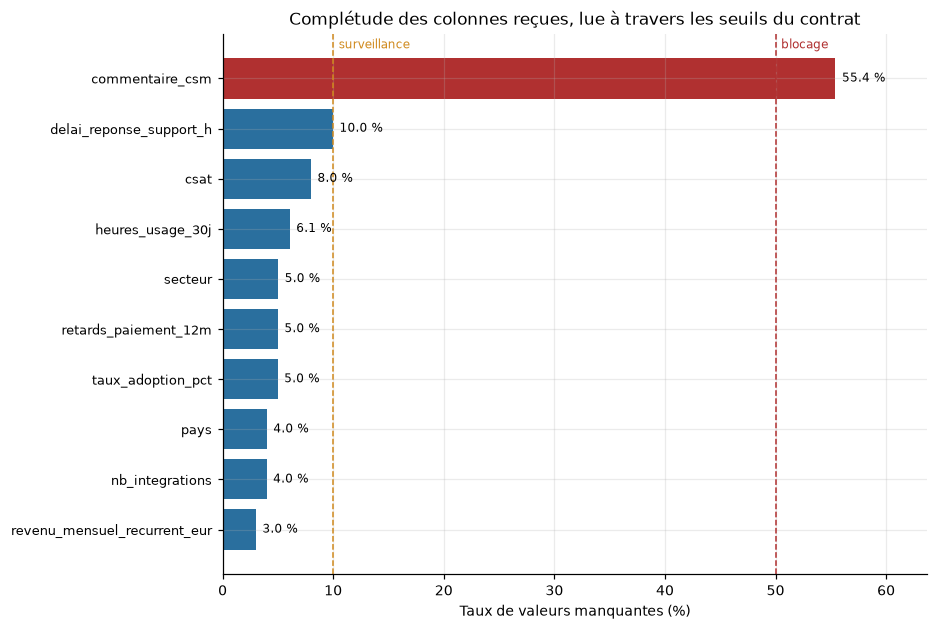

colonne,manquants,cible si renseignée,cible si absente,écart (points),taux global (%)
pays,200,27.8,32.0,4.2,28.0
retards_paiement_12m,250,28.2,24.4,-3.8,28.0
nb_integrations,200,28.1,24.5,-3.6,28.0
heures_usage_30j,300,28.2,25.0,-3.2,28.0
secteur,250,28.1,25.6,-2.5,28.0
csat,400,28.2,25.8,-2.4,28.0
taux_adoption_pct,250,28.1,26.0,-2.1,28.0
revenu_mensuel_recurrent_eur,150,28.0,26.7,-1.4,28.0
delai_reponse_support_h,500,28.0,28.2,0.2,28.0


In [9]:
# --- Duplicates and missing values ---------------------------------------------------
from churn_saas.donnees import mecanisme_manquants, profil_doublons, profil_manquants
from churn_saas.donnees.profilage import SEUIL_MANQUANTS_CRITIQUE, SEUIL_MANQUANTS_SURVEILLANCE
from churn_saas.features import tracer_completude

afficher_tableau(profil_doublons(bronze, cle="client_id"), titre="Doublons : stricts et sur la clé")

# Measured on the file as received, as published in phase 2.
manquants = profil_manquants(bronze)
tracer_completude(manquants, SEUIL_MANQUANTS_SURVEILLANCE, SEUIL_MANQUANTS_CRITIQUE)
plt.show()

colonnes_recues = [c for c in manquants.loc[manquants["manquants"] > 0, "colonne"]
                   if c != "commentaire_csm"]
afficher_tableau(mecanisme_manquants(silver, cible="churn", colonnes=colonnes_recues),
                 titre="L'absence d'une valeur reçue est-elle un signal ? (écart de churn, en points)")

**Lecture.** Les 35 doublons sont tous stricts : la clé `client_id` identifie bien un compte unique, et
la déduplication est sans risque. Les manquants des colonnes reçues vont de 3 à 10 % ; le texte libre
(55 %) est exclu pour un motif réglementaire (§ 4).

**L'absence est-elle un signal ?** Deux vérifications indépendantes concordent. L'écart de taux de churn
entre comptes où la valeur est présente et absente ne dépasse pas **4,2 points**, pour un taux de 28 % ; et
l'absence du délai de support ne coïncide pas avec l'absence de ticket, cause structurelle envisagée. Les
colonnes reçues manquent donc **au hasard** : les combler par une valeur statistique est légitime, et un
indicateur de manque n'apporterait rien.

> **Décision → § 7.** Médiane pour les colonnes numériques reçues, apprise sur les seuls plis
> d'entraînement ; pas d'indicateur de manque (registre, E-204).

### 6.2 Distributions et valeurs extrêmes

In [10]:
# --- Distributions and extreme values ------------------------------------------------
from churn_saas.donnees import bornes_valeurs_extremes, profil_distributions

colonnes_cles = ["revenu_mensuel_recurrent_eur", "heures_usage_30j", "sieges_souscrits",
                 "tickets_support_90j", "derniere_connexion_jours", "anciennete_mois"]
afficher_tableau(profil_distributions(silver, colonnes_cles), titre="Distributions des variables clés")

bas, haut = bornes_valeurs_extremes(mrr)
hors = (mrr < bas) | (mrr > haut)
print(f"Règle IQR sur le revenu : {hors.mean():.1%} des comptes seraient écartés, "
      f"portant {mrr[hors].sum() / mrr.sum():.0%} du revenu total.")

colonne,min,médiane,moyenne,max,moyenne/médiane,asymétrie
revenu_mensuel_recurrent_eur,9.11,682.03,3543.20,89402.85,5.20,4.60
derniere_connexion_jours,0.00,2.00,7.58,200.00,3.79,4.54
sieges_souscrits,1.00,28.00,74.32,898.00,2.65,3.57
heures_usage_30j,0.00,5.65,12.67,170.20,2.24,2.29
tickets_support_90j,0.00,2.00,2.54,17.00,1.27,1.11
anciennete_mois,1.00,10.00,10.81,36.00,1.08,0.41


Règle IQR sur le revenu : 13.6% des comptes seraient écartés, portant 76% du revenu total.


**Lecture.** Le revenu mensuel moyen vaut plus de cinq fois le revenu médian : une minorité de très gros
comptes tire la moyenne vers le haut. Deux décisions en découlent.

- **La médiane, jamais la moyenne**, pour combler une valeur manquante : la moyenne attribuerait à un client
  ordinaire le revenu d'un client cinq fois plus gros (registre, E-302).
- **Aucune valeur extrême n'est retirée.** La règle classique de Tukey écarterait 13,6 % des comptes —
  environ un sur sept — qui portent **76 % du revenu**. Ce ne sont pas des erreurs de saisie : ce sont les
  clients stratégiques que le projet doit protéger (registre, E-301).

### 6.3 La découverte qui a changé la préparation

Les ratios d'usage divisent par le nombre d'utilisateurs actifs. Quand celui-ci vaut zéro, la division
produit une valeur manquante. Le réflexe serait de la traiter comme les autres. **Ce serait une erreur
coûteuse.**

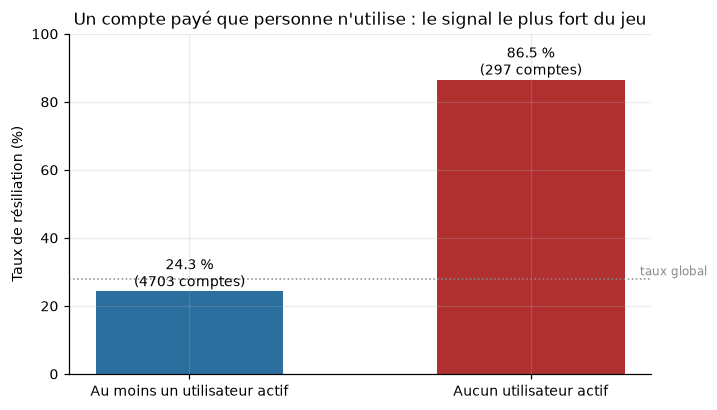

colonne,manquants,cible si renseignée,cible si absente,écart (points),taux global (%)
tickets_par_actif,297,24.3,86.5,62.2,28.0
usage_par_actif,581,24.5,54.9,30.4,28.0


In [11]:
# --- Accounts without any active user --------------------------------------------------
from churn_saas.features import tracer_compte_abandonne

tracer_compte_abandonne(silver)
plt.show()
afficher_tableau(mecanisme_manquants(resultat.silver, cible="churn",
                                     colonnes=["tickets_par_actif", "usage_par_actif"]),
                 titre="Manquants des ratios construits : écart de churn")

**Lecture.** Ces valeurs manquantes **ne sont pas des données manquantes**. Elles décrivent un compte que
l'entreprise facture et que plus personne n'utilise : 297 comptes, qui résilient à **86,5 %** contre
24,3 % pour les autres — **62 points d'écart, le signal le plus fort du jeu de données**. Les combler par
la médiane remplacerait ce signal par la valeur d'un compte ordinaire, sans qu'aucune métrique ne signale
la perte.

> **Décision → § 7.** Le signal devient une variable explicite, `compte_sans_utilisateur_actif`, déclarée
> *avant* le calcul des ratios. Elle survit à toute imputation, et un conseiller peut la lire.

**Boucle de rétroaction exploration → préparation.** La conclusion du § 6.1 — « l'absence n'est pas un
signal » — est vraie pour les colonnes **reçues**. Elle ne se transpose pas aux colonnes **construites**,
dont les trous sont produits par le calcul lui-même. Généraliser aurait coûté le meilleur prédicteur.

### 6.4 Des catégories fantômes

colonne,avant,après
secteur,21,7
taille_entreprise,8,4
plan,12,4
pays,6,6
code_datacenter,4,4


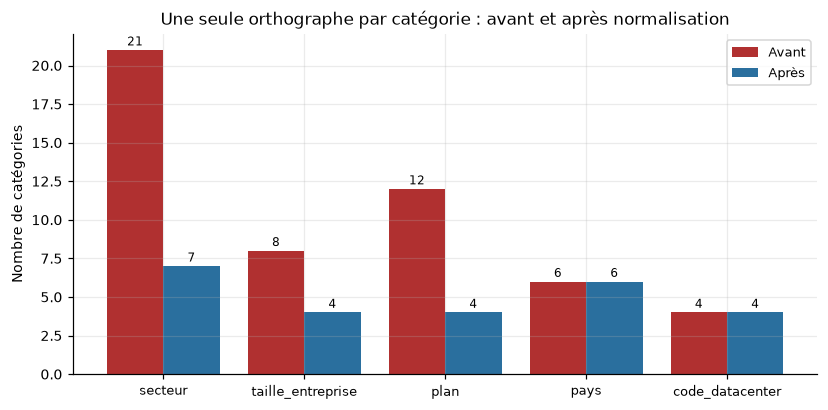

In [12]:
# --- Category fragmentation, before and after normalisation -----------------------------
from churn_saas.features import tracer_fragmentation

sans_normalisation = construire_silver(bronze, colonnes_categorielles=[])
colonnes_cat = ["secteur", "taille_entreprise", "plan", "pays", "code_datacenter"]
fragmentation = pd.DataFrame({
    "colonne": colonnes_cat,
    "avant": [sans_normalisation[c].dropna().nunique() for c in colonnes_cat],
    "après": [silver[c].dropna().nunique() for c in colonnes_cat],
})
afficher_tableau(fragmentation, titre="Nombre de catégories par colonne")
tracer_fragmentation(fragmentation)
plt.show()

**Lecture.** Le jeu reçu compte 21 secteurs pour 7, 12 formules d'abonnement pour 4, 8 tailles
d'entreprise pour 4 : `TPE`, `tpe` et ` TPE ` étaient trois catégories. La normalisation de la phase 2
ne s'appliquait qu'à la **clé de jointure**, pas aux valeurs enregistrées. Laissé en l'état, l'encodage
aurait produit une colonne par orthographe : le modèle aurait vu plusieurs catégories rares là où le métier
en a une, réparti le signal entre elles, et toute lecture d'importance serait devenue trompeuse.

**Boucle de rétroaction exploration → cadrage.** Ce défaut avait faussé **trois chiffres publiés au
cadrage** : les écarts de churn entre segments étaient surestimés d'un facteur deux (13 à 17 points au lieu
de 7 à 8), une variante orthographique marginale fixant l'extrême. Corrigés, ils **renforcent** la
conclusion du cadrage : aucun segment ne se détache assez pour qu'une règle métier remplace un modèle.

> **Décision → § 7.** Une seule orthographe par catégorie — la plus fréquente, pour qu'un livrable affiche
> `TPE` et non `tpe` — appliquée aux valeurs et pas seulement à la clé.

### 6.5 Le déséquilibre de la cible et des catégories

mesure,valeur
Positifs (churn),1 400
Négatifs,3 600
Taux de positifs,28.0%
Ratio négatifs / positifs,2.6 : 1
Exactitude d'un modèle trivial,72.0% — d'où l'inutilité de cette métrique
Qualification,déséquilibre modéré


variable,modalités,plus fréquente,plus rare,rapport max/min,modalités < 50
secteur,7,Commerce (905),Public (398),2.3,0
pays,6,France (2691),Canada (384),7.0,0
taille_entreprise,4,PME (2068),GE (360),5.7,0
plan,4,Pro (1772),Enterprise (551),3.2,0


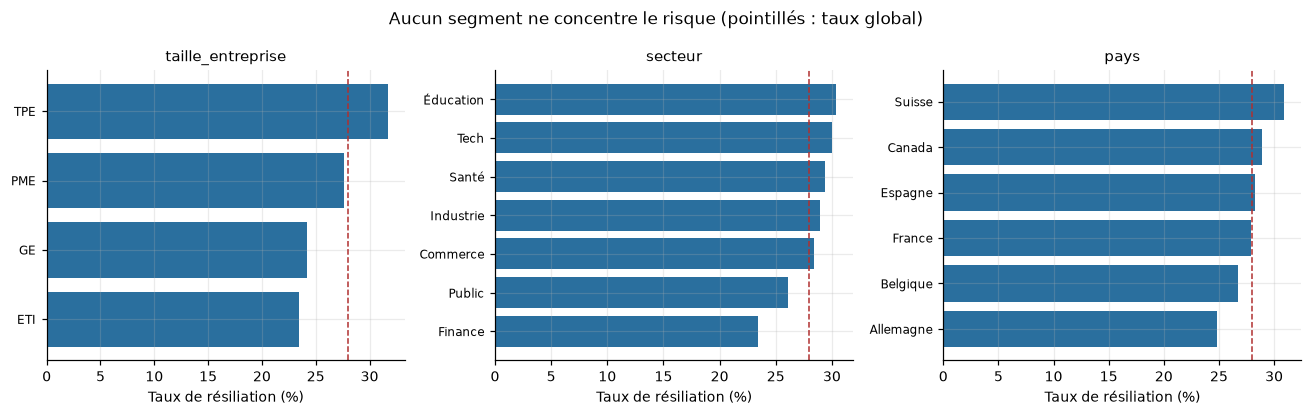

In [13]:
# --- Target and category imbalance ---------------------------------------------------
from churn_saas.features import desequilibre_categories, desequilibre_cible
from churn_saas.features import tracer_risque_par_segment

afficher_tableau(desequilibre_cible(resultat.y), titre="Déséquilibre de la cible")
afficher_tableau(desequilibre_categories(silver, ["secteur", "pays", "taille_entreprise", "plan"]),
                 titre="Déséquilibre des variables catégorielles")
tracer_risque_par_segment(silver, ["taille_entreprise", "secteur", "pays"])
plt.show()

**Lecture.** Le déséquilibre de la cible est **modéré** (28 %, 2,6 négatifs pour 1 positif), pas sévère.
Un modèle trivial prédisant « reste » partout atteindrait 72 % d'exactitude sans aucune valeur.

> **Décisions → § 8 et 9.**
> - Critère de sélection : **PR-AUC**, et non l'exactitude (registre, E-308).
> - Rééquilibrage par **pondération des classes**, comparée à l'ajustement du point de fonctionnement et
>   jamais cumulée d'emblée ; pas de rééchantillonnage synthétique, qui fabriquerait des clients
>   inexistants (registre, E-305).
> - Ne pas surjouer l'argument du déséquilibre à l'oral : il est réel mais mesuré.

Aucune catégorie n'a moins de 50 comptes : les taux par segment sont fiables, et aucun regroupement de
modalités rares n'est nécessaire.

### 6.6 Ce qui sépare la cible : corrélations, redondances, tendances, fuite

variable,corrélation,sens,notable
nb_integrations,-0.371,diminue le risque,True
derniere_connexion_jours,0.353,augmente le risque,True
anciennete_mois,-0.325,diminue le risque,True
taux_adoption_pct,-0.306,diminue le risque,True
retards_paiement_12m,0.303,augmente le risque,True
csat,-0.279,diminue le risque,True
tickets_support_90j,0.270,augmente le risque,True
fonctionnalites_utilisees,-0.257,diminue le risque,True
delai_reponse_support_h,0.253,augmente le risque,True
connexions_30j,-0.237,diminue le risque,True


variable A,variable B,corrélation
sieges_souscrits,revenu_mensuel_recurrent_eur,0.916
connexions_30j,heures_usage_30j,0.900
sieges_souscrits,utilisateurs_actifs,0.851
utilisateurs_actifs,revenu_mensuel_recurrent_eur,0.804


variable,correlation_cible,motif_connu
sante_compte_fin_periode,-0.881,fuite temporelle — information postérieure à la décision


variable,forme
derniere_connexion_jours,croissante
tickets_support_90j,croissante
delai_reponse_support_h,croissante
anciennete_mois,décroissante
sieges_souscrits,décroissante
utilisateurs_actifs,décroissante
taux_adoption_pct,décroissante
connexions_30j,décroissante
heures_usage_30j,décroissante
fonctionnalites_utilisees,décroissante


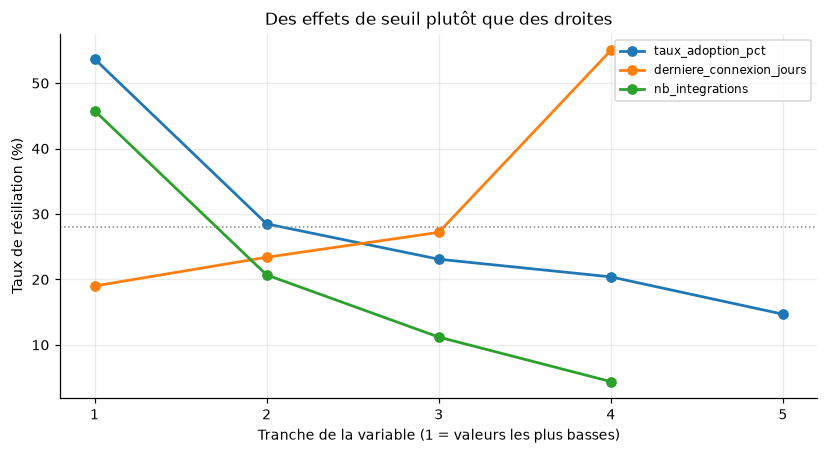

In [14]:
# --- Correlations, redundancies, non-monotone trends, leakage ---------------------------
from churn_saas.features import (correlations_cible, correlations_entre_variables,
                                 detecter_fuite_suspecte, monotonie, tendance_par_tranche)
from churn_saas.features import tracer_tendances

numeriques = resultat.X.select_dtypes("number")
afficher_tableau(correlations_cible(numeriques, resultat.y.astype(float)).head(10),
                 titre="Les dix variables les plus liées au churn")
afficher_tableau(correlations_entre_variables(numeriques),
                 titre="Paires de variables redondantes (corrélation > 0,80)")

candidats = silver.drop(columns=["churn", "client_id", "commentaire_csm"]).select_dtypes("number")
afficher_tableau(detecter_fuite_suspecte(candidats, silver["churn"].astype(float)),
                 titre="Contrôle générique de fuite : corrélation suspecte avec la cible")

profils = {c: tendance_par_tranche(resultat.silver, c, "churn")
           for c in numeriques.columns if resultat.silver[c].nunique() > 5}
formes = pd.DataFrame({"variable": list(profils), "forme": [monotonie(p) for p in profils.values()]})
afficher_tableau(formes.sort_values("forme"), titre="Forme de la relation avec le churn, par variable")
# Three variables whose effect is concentrated in an extreme bucket (threshold effect).
tracer_tendances({v: profils[v] for v in ("taux_adoption_pct", "derniere_connexion_jours",
                                          "nb_integrations")},
                 taux_global=resultat.y.astype(float).mean() * 100)
plt.show()

**Lecture, en quatre constats.**

1. **Les signaux sont multiples et modérés.** Intégrations, dernière connexion, compte sans utilisateur
   actif, ancienneté, adoption et retards de paiement se situent tous entre 0,30 et 0,37 de corrélation :
   aucun ne suffit seul, ce qui plaide pour un modèle plutôt qu'une règle.
2. **Une corrélation faible n'est pas une raison d'écarter une variable** : elle ne voit que les relations
   simples et par paires (registre, E-303). Inversement, cinq colonnes ne prennent **qu'une valeur par
   formule d'abonnement** (prix, SLA, quota, support dédié, fonctionnalités) : elles répètent `plan`.
   Elles sont réduites à `plan` (§ 7.3, arbitrage de la phase 5).
3. **Le contrôle générique de fuite désigne une seule variable**, `sante_compte_fin_periode` (corrélation
   −0,88), sans qu'on lui ait donné de nom à chercher. C'est un score calculé en fin de période, donc
   *après* la décision du client : elle est exclue (§ 7), et la démonstration chiffrée de son effet sur le
   modèle est faite en section 8.
4. **Les relations sont monotones, mais pas linéaires.** Mesurée par tranches, chaque variable varie dans
   un seul sens — la seule exception, le revenu, tient à un écart de 0,3 point, du bruit plutôt qu'un
   retournement. En revanche, l'essentiel de l'effet se concentre souvent dans une tranche extrême : 54 %
   de churn dans le premier cinquième du taux d'adoption, 15 à 29 % dans les quatre autres. Un **effet de
   seuil** est mal décrit par une droite ; un arbre de décision le capte naturellement. C'est l'argument,
   issu de l'observation, pour comparer une famille linéaire et une famille d'arbres.

**Journal de bord [C3] — impact de l'EDA sur la stratégie de modélisation :**

| Constat | Décision | Où |
|---|---|---|
| Manques au hasard sur les colonnes reçues (≤ 4,2 points) | Médiane apprise dans le pli, pas d'indicateur | § 7 |
| Revenu très asymétrique, extrêmes réels | Médiane plutôt que moyenne ; aucune valeur retirée | § 7 |
| Ratios non définis sur 297 comptes abandonnés (62 points) | Indicateur explicite, déclaré avant les ratios | § 7 |
| 26 catégories fantômes | Une orthographe par catégorie, sur les valeurs | § 7 |
| Déséquilibre modéré (28 %) | PR-AUC, pondération des classes, pas de SMOTE | § 8, 9 |
| Relations monotones mais à effet de seuil | Comparer une famille linéaire et une famille d'arbres, plutôt que choisir d'avance | § 8 |
| Fuite détectée sans être cherchée par son nom | Exclusion par règle générale (aucune variable postérieure à la décision) | § 7, 8 |
| Cinq attributs de formule redondants avec `plan` | Réduits à `plan` (arbitrage de la phase 5) | § 7.3 |

## 7. Préparation des données (nettoyage, manquants, transformations, features) — journal de bord [C3]

La préparation transforme les données reçues en un **jeu d'apprentissage figé**. Elle suit trois niveaux,
la convention usuelle en ingénierie des données :

| Niveau | Contenu | Pour qui |
|---|---|---|
| **Bronze** | Données brutes, telles que reçues, tout en texte | Personne — c'est la référence |
| **Silver** | Nettoyées, typées, rapprochées du catalogue, **fidèles à la source** | Un humain, un outil de restitution |
| **Gold** | Prêtes pour l'apprentissage : variables construites, trous structurels comblés, valeurs reconstruites, colonnes interdites retirées | Le modèle |

**La même chaîne sert à l'entraînement et au lot mensuel.** Les deux appellent les mêmes fonctions —
`construire_silver_standard` puis `preparer_gold` — et un test vérifie que, sur les mêmes données, elles
produisent un jeu gold identique à l'octet. Avant la phase 4, le lot mensuel reconstruisait ses données à
sa façon, sans convertir les nombres ni les dates : un *training-serving skew* que rien n'aurait signalé.

In [15]:
# --- The shared chain, shown where it is explained -----------------------------------
from churn_saas.features import construire_silver_standard, preparer_gold

afficher_source(construire_silver_standard)
afficher_source(preparer_gold)

**Source — `churn_saas.features.pipeline.construire_silver_standard`**

```python
def construire_silver_standard(
    bronze: pd.DataFrame, catalogue: pd.DataFrame | None = None, **options: Any
) -> pd.DataFrame:
    """Silver built with the project's column lists - the one entry point for every caller.

    Until phase 4 the monthly batch called `construire_silver` without these lists: it
    would have scored on numbers left as text and unparsed dates, while training used
    converted ones. Same function, different preparation - the training-serving skew.
    """
    parametres: dict[str, Any] = {
        "colonnes_decimales": list(COLONNES_DECIMALES),
        "colonnes_dates": list(COLONNES_DATES),
        "colonnes_entieres": list(COLONNES_ENTIERES),
    }
    parametres.update(options)
    return construire_silver(bronze, catalogue=catalogue, **parametres)

```

**Source — `churn_saas.features.pipeline.preparer_gold`**

```python
def preparer_gold(
    silver: pd.DataFrame, enrichir: bool = True, garder: list[str] | None = None
) -> PreparationGold:
    """Silver -> gold, identically for training and for the monthly batch.

    Order: usage ratios, structural zeros, deterministic reconstruction, exclusions. The
    statistical imputation is *not* here: it is learnt inside the model pipeline, on
    training folds only.

    Zeros and reconstruction apply to the gold path only. Silver stays faithful to the
    source - a reader sees a missing revenue as missing, the exploration still sees the
    NaN of abandoned accounts - and the data contract, run on silver, keeps measuring the
    real gaps of incoming data.
    """
    enrichi = ajouter_ratios_usage(silver) if enrichir else silver.copy()
    reconstruit, bilan = reconstruire_valeurs_deterministes(combler_ratios_structurels(enrichi))
    return PreparationGold(
        silver_enrichi=enrichi,
        gold=construire_gold(reconstruit, garder=garder),
        reconstructions=bilan,
    )

```

'def preparer_gold(\n    silver: pd.DataFrame, enrichir: bool = True, garder: list[str] | None = None\n) -> PreparationGold:\n    """Silver -> gold, identically for training and for the monthly batch.\n\n    Order: usage ratios, structural zeros, deterministic reconstruction, exclusions. The\n    statistical imputation is *not* here: it is learnt inside the model pipeline, on\n    training folds only.\n\n    Zeros and reconstruction apply to the gold path only. Silver stays faithful to the\n    source - a reader sees a missing revenue as missing, the exploration still sees the\n    NaN of abandoned accounts - and the data contract, run on silver, keeps measuring the\n    real gaps of incoming data.\n    """\n    enrichi = ajouter_ratios_usage(silver) if enrichir else silver.copy()\n    reconstruit, bilan = reconstruire_valeurs_deterministes(combler_ratios_structurels(enrichi))\n    return PreparationGold(\n        silver_enrichi=enrichi,\n        gold=construire_gold(reconstruit, garde

### 7.1 Deux défauts silencieux, trouvés en mesurant

La phase 2 avait coché « fonctions de nettoyage » sur la foi du code. La phase 4 a **mesuré** ce qu'elles
produisaient, et deux défauts sont apparus. Aucun ne levait d'erreur ; tous deux auraient faussé le modèle.

**Premier défaut : une unité effaçait 570 valeurs.** Des délais de support arrivaient écrits « 3.1 h ». La
conversion retirait les espaces et les symboles monétaires, pas la lettre ; `to_numeric` transformait le
reste en valeur manquante. La colonne affichait 21,4 % de trous au lieu de 10,0 %.

La correction est générique — toute unité en lettres collée à un nombre — mais surtout, un **garde-fou
indépendant du format** compare chaque colonne avant et après conversion : une valeur présente dans la
source et absente après conversion arrête la chaîne. Le prochain format inattendu sera arrêté de la même
façon.

In [16]:
# --- Conversion: the primitive, its guard, and what the old rule lost ---------------------
from churn_saas.donnees import nettoyer_decimal_texte, pertes_de_conversion

afficher_source(nettoyer_decimal_texte)
afficher_source(pertes_de_conversion)

delais = bronze.drop_duplicates()["delai_reponse_support_h"]
# The rule used until phase 4: spaces and decimal comma handled, letters not.
ancienne_regle = pd.to_numeric(delais.astype(str).str.replace(" ", "").str.replace(",", "."),
                               errors="coerce")
avec_unite = delais.astype(str).str.contains(r"\d\s*h$").sum()
print(f"Délais écrits avec l'unité « h » : {avec_unite}")
print(f"Perdus par l'ancienne règle : {pertes_de_conversion(delais, ancienne_regle).sum()}")
print(f"Perdus par la règle actuelle : {pertes_de_conversion(delais, nettoyer_decimal_texte(delais)).sum()}")

**Source — `churn_saas.donnees.silver.nettoyer_decimal_texte`**

```python
def nettoyer_decimal_texte(serie: pd.Series) -> pd.Series:
    """Convert a numeric column stored as text ("1 234,50 EUR", "33,3 %", "3.1 h") into numbers.

    Unconvertible text still becomes NaN rather than raising: this primitive must never
    stop a batch on its own. Detecting what it lost is the job of `pertes_de_conversion`,
    which `construire_silver` runs on every converted column.
    """
    texte = serie.astype(str)
    for symbole in SYMBOLES_A_RETIRER:
        texte = texte.str.replace(symbole, "", regex=False)
    texte = texte.str.replace(UNITE_EN_LETTRES, "", regex=True)
    return pd.to_numeric(texte.str.replace(",", ".", regex=False), errors="coerce")

```

**Source — `churn_saas.donnees.silver.pertes_de_conversion`**

```python
def pertes_de_conversion(avant: pd.Series, apres: pd.Series) -> pd.Series:
    """Rows holding a value before conversion and none after it.

    This is the generic guard against the defect `nettoyer_decimal_texte` can only
    mitigate: it targets no column name and no format, it compares presence before and
    after. A missing value that was already missing is not a loss.
    """
    texte = avant.astype("string").str.strip()
    present = avant.notna() & texte.notna() & texte.ne("") & texte.str.casefold().ne("nan")
    return present & apres.isna()

```

Délais écrits avec l'unité « h » : 570
Perdus par l'ancienne règle : 570
Perdus par la règle actuelle : 0


**Second défaut : 960 dates lues jour et mois inversés.** Les dates arrivaient sous trois formats. La
lecture automatique (`format="mixed", dayfirst=True`) lisait « 2024-02-06 » comme le **2 juin** : 960 dates
au format international sur 1 694, soit 19 % du jeu, toutes lues, aucune vide — rien n'avait l'air faux.

Ce qui l'a révélé est une colonne que rien ne désignait : **le jour de la semaine de la souscription**, que
la source fournit. Une date mal lue ne tombe presque jamais le bon jour. Ce témoin est devenu un contrôle
du contrat de données. Chaque format est désormais lu explicitement, et une date dont le format n'est pas
déclaré devient une perte de conversion plutôt qu'une supposition.

In [17]:
# --- Dates: explicit formats, checked against the stated weekday --------------------------
from churn_saas.donnees import parser_dates_multiformat

afficher_source(parser_dates_multiformat)

JOURS = dict(enumerate(["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"]))
source = bronze.drop_duplicates()
texte = source["date_souscription"].astype(str)
declare = source["jour_souscription"].str.strip().str.casefold()
iso = texte.str.match(r"^\d{4}-\d{2}-\d{2}$")
ambigues = texte.str.match(r"^(0?[1-9]|1[0-2])/(0?[1-9]|1[0-2])/")


def accord(lues, masque):
    # Share (%) of dates falling on the weekday stated by the source.
    return (lues.dt.dayofweek.map(JOURS)[masque] == declare[masque]).mean() * 100


temoin = pd.DataFrame([
    ("Dates ISO, ancienne lecture (mixed, dayfirst)", iso.sum(),
     accord(pd.to_datetime(texte, format="mixed", dayfirst=True), iso)),
    ("Dates ISO, lecture explicite", iso.sum(), accord(parser_dates_multiformat(texte), iso)),
    ("Dates JJ/MM ambiguës, lues jour en premier", ambigues.sum(),
     accord(parser_dates_multiformat(texte), ambigues)),
    ("Dates JJ/MM ambiguës, si lues mois en premier", ambigues.sum(),
     accord(pd.to_datetime(texte.where(ambigues), format="%m/%d/%Y"), ambigues)),
    ("Toutes les dates, lecture explicite", len(texte), accord(parser_dates_multiformat(texte), texte.notna())),
], columns=["Lecture", "Dates", "Accord avec le jour déclaré (%)"]).round(1)
afficher_tableau(temoin, titre="Le jour de semaine déclaré, témoin de la lecture des dates")

**Source — `churn_saas.donnees.silver.parser_dates_multiformat`**

```python
def parser_dates_multiformat(
    serie: pd.Series, formats: tuple[str, ...] = FORMATS_DATE
) -> pd.Series:
    """Parse mixed date formats (YYYY-MM-DD, DD/MM/YYYY, "12 Jan 2024"), one format at a time.

    Each value is read by the first declared format that fits it. A value matching none of
    them becomes NaT, which `construire_silver` reports as a conversion loss instead of
    guessing.

    Day-first for slash dates is a measured choice, not a convention. The source carries a
    witness: `jour_souscription`, the weekday of the subscription. Read this way, all 5,000
    dates agree with it; reading the 955 ambiguous slash dates month-first, only 15 % would
    (phase 4, pinned in the non-regression tests).
    """
    texte = serie.astype("string").str.strip()
    resultat = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[ns]")
    for format_ in formats:
        lues = pd.to_datetime(texte, format=format_, errors="coerce")
        resultat = resultat.where(resultat.notna(), lues)
    return resultat

```

Lecture,Dates,Accord avec le jour déclaré (%)
"Dates ISO, ancienne lecture (mixed, dayfirst)",1694,48.2
"Dates ISO, lecture explicite",1694,100.0
"Dates JJ/MM ambiguës, lues jour en premier",955,100.0
"Dates JJ/MM ambiguës, si lues mois en premier",955,15.1
"Toutes les dates, lecture explicite",5000,100.0


**Lecture.** Avec l'ancienne lecture, moins de la moitié des dates internationales tombaient le jour
déclaré ; avec la lecture explicite, **les 5 000 dates concordent**. Le même témoin tranche l'ambiguïté des
dates à barres obliques : lues jour en premier, toutes concordent ; lues mois en premier, 15 % seulement.
La convention française n'est plus une hypothèse, c'est une mesure.

### 7.2 Doublons, catalogue et catégories

- **Doublons en deux passes.** Une première sur le texte brut, une seconde une fois les valeurs typées et
  normalisées : « 12,5 » et « 12.5 » décrivant le même compte ne font alors plus qu'un. Un compte qui reste
  en double avec des **valeurs différentes arrête la chaîne** : aucune règle ne peut dire quelle ligne est
  juste (registre, E-407). Le cas n'existe pas dans ces données ; s'il apparaît, il sera vu.
- **Catalogue typé.** Lu en texte comme toute source, le catalogue apportait ses prix, SLA et quotas sous
  forme de chaînes : l'encodage en aurait fait des catégories, « 12 » et « 25 € » sans relation d'ordre.
  Chaque colonne est désormais convertie si — et seulement si — la conversion est sans perte ;
  `support_dedie` (« Oui »/« Non ») reste du texte.
- **Une orthographe par catégorie** (§ 6.4), la plus fréquente servant de libellé.

### 7.3 Ce qui n'entre pas dans le modèle

L'exclusion des colonnes interdites se fait au passage silver → gold. La règle est **générale** — aucune
information postérieure à la décision, aucun identifiant, aucune donnée personnelle, aucune redondance — et
non une liste de noms : chaque colonne porte son propre motif, lu ici dans le code.

In [18]:
# --- Exclusions, each with its own motive ---------------------------------------------
from churn_saas.donnees import table_exclusions

afficher_tableau(table_exclusions(), titre="Colonnes exclues des variables explicatives")

colonne,motif d'exclusion
client_id,"identifiant — aucun pouvoir prédictif, risque de mémorisation"
code_datacenter,"leurre — étalon du bruit pendant la sélection, retiré du modèle final (phase 5)"
commentaire_csm,RGPD — texte libre susceptible de contenir des données personnelles
compte_sans_utilisateur_actif,"variable construite — apport non significatif mesuré (phase 5, bloc B)"
couleur_theme_interface,"leurre — étalon du bruit pendant la sélection, retiré du modèle final (phase 5)"
date_souscription,"date brute — encodée telle quelle, une catégorie par jour ; anciennete_mois porte déjà l'information"
fonctionnalites_incluses,doublon — même information que fonctionnalites_total
fonctionnalites_total,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
groupe_experimentation,artefact de process interne — pas une variable métier
pays,"sous le plancher des leurres (deux modèles), retrait sans perte (phase 5, bloc C)"


Les motifs ne sont pas interchangeables : la grille sépare l'exclusion **éthique** (C2 — texte libre,
artefact de process) de l'exclusion **technique** (C3 — fuite, identifiant, doublon, date brute, attribut de
formule). Trois exclusions datent de la phase 4, cinq de la phase 5 :

- `date_souscription` : encodée telle quelle, une date devient une catégorie par jour, inconnue au scoring ;
  `anciennete_mois` porte déjà l'information.
- `fonctionnalites_incluses` : copie exacte de `fonctionnalites_total`, apportée par le catalogue.
- `taux_activation` : le ratio construit en phase 5 était `taux_adoption_pct` divisé par 100. La colonne
  source, lue par le métier, est conservée (arbitrage du porteur).
- **Phase 5 —** `prix_mensuel_par_siege_eur`, `sla_reponse_h`, `quota_stockage_go`, `support_dedie` et
  `fonctionnalites_total` ne prennent qu'une valeur par formule : `plan` porte déjà toute leur information.
  Gardées, elles donnaient six fois la même information à quatre valeurs au modèle, et rendaient les
  coefficients d'une régression logistique illisibles. Avec `plan` seul, le modèle ne dépend plus du
  catalogue en production (scénario de perte du référentiel, § 3) ; le catalogue reste utile pour
  reconstruire le revenu.

Deux variables **leurres**, `couleur_theme_interface` et `code_datacenter`, sont au contraire
**conservées** : elles n'ont aucune raison d'influencer un départ, et c'est précisément ce que l'analyse
d'importance devra montrer en section 9, plutôt que de les écarter par intuition.

### 7.4 Les valeurs manquantes : quatre raisons de manquer, quatre traitements

Une valeur manque pour des raisons différentes, et chaque raison appelle un traitement différent. Les
quatre familles sont traitées dans cet ordre.

| Famille | Colonnes | Traitement | Où dans la chaîne |
|---|---|---|---|
| **Trou structurel** | ratios par utilisateur des 297 comptes sans utilisateur actif | Zéro par convention, l'indicateur portant le sens | chemin du gold |
| **Valeur reconstructible** | revenu mensuel (150), taux d'adoption (250) | Recalcul ligne à ligne à partir des autres colonnes | chemin du gold, **après** le contrat |
| **Manque au hasard** | délai, satisfaction, heures d'usage, intégrations, retards | Médiane, apprise sur les seuls plis d'entraînement | chaîne du modèle |
| **Catégorie manquante** | secteur, pays | Modalité « Non renseigné » | chaîne du modèle |

**Pourquoi la reconstruction après le contrat.** Placée avant, elle ferait mesurer au contrat 0 % de
revenu manquant là où la source en a 3 % : la surveillance mensuelle de la qualité des données entrantes
deviendrait aveugle. Le silver reste fidèle à la source ; seul le gold est complété.

In [19]:
# --- Families 1 and 2: structural zeros, row-by-row reconstruction ------------------------
from churn_saas.donnees import REGLES_RECONSTRUCTION
from churn_saas.features import combler_ratios_structurels

afficher_source(combler_ratios_structurels)
afficher_tableau(pd.DataFrame([{"colonne": r.colonne, "règle": r.formule,
                                "ingrédients": ", ".join(r.ingredients)}
                               for r in REGLES_RECONSTRUCTION]),
                 titre="Règles de reconstruction, déclarées comme données")
afficher_tableau(resultat.reconstructions, titre="Ce que la reconstruction a comblé")

# The rule is checked where the truth is known: the 4,850 observed revenues.
connu = silver["revenu_mensuel_recurrent_eur"].dropna()
regle = (silver["sieges_souscrits"].astype(float) * silver["prix_mensuel_par_siege_eur"]).loc[connu.index]
erreur_regle = ((regle - connu).abs() / connu).median()
erreur_mediane = ((connu.median() - connu).abs() / connu).median()
print(f"Revenu reconstruit, comparé aux {len(connu)} revenus connus : erreur médiane {erreur_regle:.1%}")
print(f"Médiane globale, sur les mêmes comptes : erreur médiane {erreur_mediane:.1%}")

**Source — `churn_saas.features.construction.combler_ratios_structurels`**

```python
def combler_ratios_structurels(df: pd.DataFrame) -> pd.DataFrame:
    """Set the per-user ratios to 0 where there is no active user (phase 4).

    With no active user, a per-user ratio is undefined, not unknown. The value 0 is a
    convention; the indicator `compte_sans_utilisateur_actif` carries the meaning. For
    usage the convention matches the data (hours are always 0 or missing there); for
    tickets it does not - 210 such accounts still open tickets - which is why the model
    must read the indicator, not the ratio.

    Filling them here separates the two causes of NaN. What remains is genuinely unknown
    (hours missing on an account that has users) and goes to the median imputation of the
    model pipeline. Applied on the way to gold only: silver keeps the NaN the exploration
    reads, so the phase 3 demonstration stays reproducible.
    """
    out = df.copy()
    if "compte_sans_utilisateur_actif" not in out.columns:
        return out
    sans_actif = pd.to_numeric(out["compte_sans_utilisateur_actif"], errors="coerce").eq(1)
    for ratio in RATIOS_PAR_ACTIF:
        if ratio in out.columns:
            out.loc[sans_actif, ratio] = 0.0
    return out

```

colonne,règle,ingrédients
revenu_mensuel_recurrent_eur,sièges souscrits × prix mensuel par siège,"sieges_souscrits, prix_mensuel_par_siege_eur"
taux_adoption_pct,"utilisateurs actifs ÷ sièges souscrits × 100, une décimale","utilisateurs_actifs, sieges_souscrits"


colonne,règle,manquants avant,reconstruits,manquants après,statut
revenu_mensuel_recurrent_eur,sièges souscrits × prix mensuel par siège,150,150,0,appliquée
taux_adoption_pct,"utilisateurs actifs ÷ sièges souscrits × 100, une décimale",250,250,0,appliquée


Revenu reconstruit, comparé aux 4850 revenus connus : erreur médiane 8.9%
Médiane globale, sur les mêmes comptes : erreur médiane 91.4%


**Lecture.** La reconstruction n'est pas affirmée, elle est **vérifiée là où la vérité est connue** :
appliquée aux 4 850 comptes dont le revenu est observé, la règle sièges × prix se trompe de 9 % en valeur
médiane ; la médiane globale, que le modèle aurait reçue sinon, se trompe de 91 %. Le taux d'adoption, lui,
est exactement le rapport actifs ÷ sièges : la reconstruction est exacte.

Le zéro des ratios structurels est une **convention**, pas une estimation : pour l'usage, il correspond aux
données (les heures valent toujours 0 ou sont manquantes sur ces comptes) ; pour les tickets, non — 210 de
ces comptes en ouvrent encore. C'est l'indicateur `compte_sans_utilisateur_actif`, et non le ratio, que le
modèle doit lire.

**Familles 3 et 4 : l'imputation statistique est apprise, donc placée dans le modèle.** C'est la seule
étape de la préparation qui apprend des données, et donc la seule qui puisse fuir : apprise sur toute la
table, elle laisserait le jeu de test influencer les valeurs sur lesquelles le modèle s'entraîne. Elle vit
dans la chaîne scikit-learn, ajustée pli par pli — un test vérifie que la médiane apprise est celle du pli,
pas celle de la table.

In [20]:
# --- Families 3 and 4: learnt inside the model pipeline -------------------------------------
from churn_saas.modelisation import construire_preprocesseur

afficher_source(construire_preprocesseur)

restants = resultat.X.isna().sum()
afficher_tableau(restants[restants > 0].rename("manquants restants").reset_index()
                 .rename(columns={"index": "colonne"}),
                 titre="Manquants qui atteignent le modèle (imputés dans chaque pli)")

**Source — `churn_saas.modelisation.baseline.construire_preprocesseur`**

```python
def construire_preprocesseur(X: pd.DataFrame) -> ColumnTransformer:
    """Preparation chain: impute then encode, per column type.

    `OneHotEncoder` rather than `LabelEncoder`: `secteur`, `pays` and `plan` are nominal.
    Ordinal encoding would introduce an arbitrary ordering that a linear model would read
    as a magnitude relation.
    """
    numeriques = X.select_dtypes(include="number").columns.tolist()
    categorielles = [c for c in X.columns if c not in numeriques]

    return ColumnTransformer(
        [
            (
                "num",
                Pipeline(
                    [
                        # Median rather than mean: MRR is heavily skewed
                        # (median 682 EUR, mean 3,543 EUR). The mean would import that
                        # skew into every imputed value.
                        ("imputation", SimpleImputer(strategy="median")),
                        ("echelle", StandardScaler()),
                    ]
                ),
                numeriques,
            ),
            (
                "cat",
                Pipeline(
                    [
                        # An explicit category rather than the most frequent one
                        # (phase 4): the mode would inflate the dominant sector or country
                        # and bias the per-segment fairness analysis; an explicit
                        # "missing" label keeps the gap visible, and usable by the model.
                        (
                            "imputation",
                            SimpleImputer(strategy="constant", fill_value=MODALITE_MANQUANTE),
                        ),
                        (
                            "encodage",
                            # min_frequency groups rare categories: without it a category
                            # seen twice would get its own column and invite overfitting.
                            OneHotEncoder(handle_unknown="ignore", min_frequency=0.01),
                        ),
                    ]
                ),
                categorielles,
            ),
        ],
        remainder="drop",
    )

```

colonne,manquants restants
secteur,250
heures_usage_30j,300
nb_integrations,200
delai_reponse_support_h,500
csat,400
retards_paiement_12m,250


### 7.5 Variables construites

| Variable | Définition | Ce qu'elle dit |
|---|---|---|
| `compte_sans_utilisateur_actif` | 1 si aucun utilisateur actif | Un compte payé que personne n'utilise — le signal le plus fort (§ 6.3) |
| `taux_couverture_fonc` | fonctionnalités utilisées ÷ fonctionnalités du plan | Le client exploite-t-il ce qu'il paie ? |
| `usage_par_actif` | heures d'usage ÷ utilisateurs actifs | Intensité d'usage par personne |
| `tickets_par_actif` | tickets ÷ utilisateurs actifs | Pression sur le support, rapportée à la taille du compte |

Chaque ratio est protégé contre la division par zéro : une valeur infinie se propagerait silencieusement
jusqu'aux coefficients du modèle.

**Ce que la mesure a décidé (phase 5, § 8.B).** L'apport de ces variables n'a pas été supposé : le même modèle
a été entraîné avec et sans elles, sur les mêmes 25 plis. Elles **n'apportent rien** — ni à la régression
logistique, ni à la forêt aléatoire — parce que les variables brutes portent déjà ce qu'elles disent. Par la
règle fixée d'avance, elles sont **retirées du modèle**. Elles restent calculées dans le jeu silver, où un
conseiller peut lire, par exemple, qu'un compte n'a plus aucun utilisateur actif.

### 7.6 Le jeu d'apprentissage figé

In [21]:
# --- Frozen gold dataset: what the model will learn from -------------------------------------
from churn_saas.features import verifier_jeux_derives

afficher_tableau(verifier_jeux_derives(resultat, manifeste),
                 titre="Le jeu produit est-il celui que le manifeste décrit ?")
X, y = resultat.X, resultat.y
print(f"Jeu d'apprentissage : {X.shape[0]} comptes × {X.shape[1]} variables explicatives, "
      f"taux de churn {y.astype(float).mean():.1%}")

jeu,fichier présent,empreinte attendue,empreinte constatée,conforme
silver,True,835f0c2ece91740d…,835f0c2ece91740d…,True
gold,True,f97c430bcdfcd750…,f97c430bcdfcd750…,True


Jeu d'apprentissage : 5000 comptes × 18 variables explicatives, taux de churn 28.0%


Le jeu d'apprentissage est **figé** : son empreinte est enregistrée au manifeste et un test vérifie à
chaque exécution que le code produit toujours exactement ce jeu, quel que soit le système d'exploitation.
Un modèle entraîné dessus pourra citer cette empreinte dans sa fiche (§ 10).

**Journal de bord [C3] — choix techniques et alternatives écartées :**

| Décision | Alternative écartée | Motif | Registre |
|---|---|---|---|
| Conversion générique + garde-fou de perte | Liste de symboles à retirer | Une liste ne couvre que les formats prévus ; le suivant est perdu en silence | — |
| Lecture explicite des dates, témoin du jour de semaine | `format="mixed", dayfirst=True` | Inversait 960 dates sans en laisser une vide | E-406 |
| Compte en conflit : la chaîne s'arrête | Garder la ligne la plus complète | Aucune règle ne sait quelle ligne est juste | E-407 |
| Modalité « Non renseigné » | Modalité la plus fréquente | Gonflerait le segment dominant et fausserait l'analyse d'équité | E-403 |
| Zéro conventionnel + indicateur | Médiane pour les ratios structurels | Mélangerait un trou non défini à un trou inconnu | E-404 |
| Reconstruction sièges × prix | Médiane globale du revenu | 9 % d'erreur contre 91 % | E-405 |
| Médiane apprise dans le pli | KNN, imputation itérative | Manques au hasard de 3 à 10 % : gain faible, opacité supérieure | E-402 |
| Aucune valeur extrême retirée | Z-score, IQR | Retirerait les clients stratégiques | E-301 |
| — | « Dernière valeur connue » | Un seul instantané par compte | E-401 |

**Problèmes rencontrés et corrections apportées :**
- Deux défauts silencieux (unité « h », dates ISO) découverts en mesurant ce que la phase 2 avait coché ;
  corrigés, puis protégés par des tests génériques qui ne nomment aucune colonne.
- Une erreur de raisonnement, signalée : une première mesure censée valider la lecture des dates était
  calculée sur des dates elles-mêmes mal lues. La conclusion était juste pour un format, la mesure ne
  l'établissait pas ; elle a été remplacée par le témoin du jour de semaine.
- Le lot mensuel préparait ses données autrement que l'entraînement : il appelle désormais la même chaîne.

Tous les éléments écartés, différés ou en attente d'arbitrage sont tenus dans un **registre généré**
(`docs/05.REGISTRE_elements_ecartes.md`) : aucune colonne ne peut disparaître du modèle sans y figurer.

### 7.7 Feature engineering (phase 5) — préalables

Avant de découper le jeu et de comparer des modèles, la phase 5 a figé trois points. Les arbitrages et les
seuils de décision ont été arrêtés le 01/10/2026, **avant** tout résultat
(`docs/00.README_choix_methodologiques.md` § 7 bis). Le carnet de travail
`notebooks/05_feature_engineering.ipynb` détaille la démarche ; l'essentiel est reporté ici.

**Le catalogue réduit à `plan`.** Les colonnes apportées par le catalogue et `fonctionnalites_total`
disent-elles autre chose que la formule d'abonnement ?

In [22]:
# --- One value per plan? ----------------------------------------------------------------
from churn_saas.config import EXCLUES_ATTRIBUT_FORMULE

afficher_tableau(silver[["plan", *EXCLUES_ATTRIBUT_FORMULE]].drop_duplicates()
                 .sort_values("prix_mensuel_par_siege_eur"),
                 titre="Attributs de chaque formule : une seule valeur par plan")
exclusions = table_exclusions()
afficher_tableau(exclusions[exclusions["colonne"].isin(EXCLUES_ATTRIBUT_FORMULE)],
                 titre="Exclusions de la phase 5, avec leur motif")

plan,prix_mensuel_par_siege_eur,sla_reponse_h,quota_stockage_go,support_dedie,fonctionnalites_total
Starter,12,24,10,Non,8
Pro,25,12,100,Non,16
Business,45,6,500,Oui,26
Enterprise,80,3,2000,Oui,40


colonne,motif d'exclusion
fonctionnalites_total,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
prix_mensuel_par_siege_eur,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
quota_stockage_go,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
sla_reponse_h,"attribut de la formule — une seule valeur par plan, information portée par `plan`"
support_dedie,"attribut de la formule — une seule valeur par plan, information portée par `plan`"


**Lecture.** Chaque attribut ne prend qu'une valeur par formule : gardées, ces cinq colonnes répétaient six
fois la même information à quatre valeurs, et rendaient illisibles les coefficients d'une régression
logistique. Elles sont exclues ; le gold passe de 31 à 26 colonnes, soit 25 variables explicatives, et le
modèle ne dépend plus du catalogue en production.

**La valeur vie client encode-t-elle l'issue ?** Elle pondère chaque compte dans la règle de décision. Elle
vaut 18,9 mois de revenu chez les comptes qui restent, 15,6 chez ceux qui partent : si elle avait été
calculée en connaissant la durée de vie réelle, l'impact mesuré serait gonflé (C8). On l'explique par les
variables connues avant la décision, puis par les mêmes plus l'issue ; seuils de lecture fixés d'avance :
gain de R² < 0,01, effet < 10 %.

indicateur,valeur
Comptes analysés,4850.000
"Mois de revenu, comptes qui restent (médiane)",18.860
"Mois de revenu, comptes qui partent (médiane)",15.580
"Ancienneté, comptes qui restent (mois, médiane)",12.000
"Ancienneté, comptes qui partent (mois, médiane)",6.000
"Variance expliquée sans l'issue (R², validation croisée)",0.895
"Variance expliquée avec l'issue (R², validation croisée)",0.895
Gain de R² apporté par l'issue,0.000
"Effet de l'issue sur la valeur, à variables égales (%)",3.808
La valeur encode-t-elle l'issue ?,0.000


La valeur encode-t-elle l'issue ? non


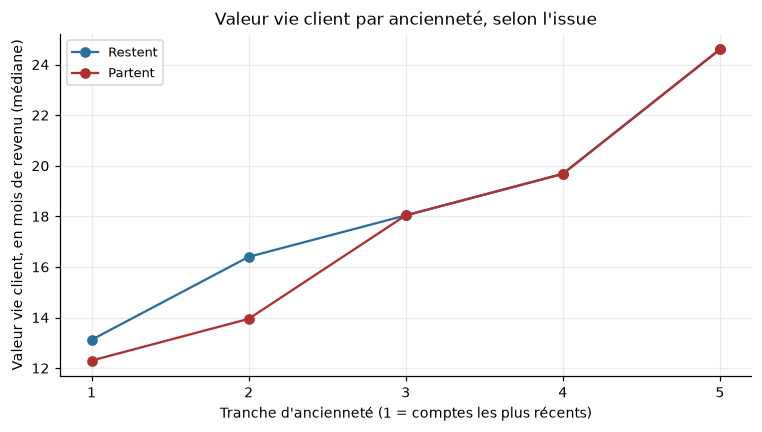

In [23]:
# --- Diagnostic of the lifetime value (arbitrage 3) ---------------------------------------
from churn_saas.evaluation import diagnostiquer_valeur_vie, valeur_encode_l_issue
from churn_saas.features import tracer_valeur_vie_par_anciennete

diagnostic = diagnostiquer_valeur_vie(X.select_dtypes("number"), silver["valeur_vie_client_eur"],
                                      silver["revenu_mensuel_recurrent_eur"], silver["churn"],
                                      silver["anciennete_mois"])
afficher_tableau(diagnostic.round(3), titre="La valeur vie client, expliquée sans puis avec l'issue")
print("La valeur encode-t-elle l'issue ?", "oui" if valeur_encode_l_issue(diagnostic) else "non")
tracer_valeur_vie_par_anciennete(silver)
plt.show()

**Lecture.** Sans l'issue, les variables connues avant la décision expliquent près de 90 % de la variance
de la valeur ; avec l'issue, pas davantage. Les deux courbes se confondent dès la troisième tranche
d'ancienneté : l'écart global vient surtout de la **composition** des groupes — les comptes qui partent ont
6 mois d'ancienneté médiane, ceux qui restent 12. **La valeur observée évaluera la règle de décision**
(registre, E-508).

**Journal de bord [C3] — phase 5, préalables :**
- Décision : réduire le catalogue à `plan`. Alternatives écartées : variable ordinale, prix seul, tout garder
  (registre, E-505, E-506).
- Décision : évaluer avec la valeur vie client observée, après diagnostic plutôt que par précaution.
- Décision : retirer les deux leurres du modèle final une fois la sélection faite ; ils servent d'abord
  d'étalon du bruit.

## 8. Choix du modèle et démarche scientifique (baseline, modèles, comparaison) — journal de bord [C4]

**Démarche scientifique.**
1. **Baseline** : régression logistique (interprétable, rapide, référence pour juger la valeur ajoutée d'un
   modèle plus complexe).
2. **Modèle(s) de comparaison** : au moins une deuxième famille — arbre de décision ensembliste (Random Forest ou
   Gradient Boosting type XGBoost/LightGBM) pour capter des interactions non-linéaires.
3. **Split train/test** stratifié sur `churn` (classe déséquilibrée), + validation croisée stratifiée (K-Fold) en
   phase d'entraînement.
4. **Prévention de la fuite** : les colonnes interdites sont retirées au passage au gold, chacune avec son
   motif (§ 7.3) ; l'imputation statistique est apprise **dans chaque pli d'entraînement**, jamais sur toute la
   table (§ 7.4) ; aucun choix n'est fait sur le jeu de test (§ 8.A). La fuite temporelle est **démontrée** au
   § 8.A.

**Métriques retenues (exigence de l'énoncé) :**
- Courbe ROC + AUC (obligatoire).
- Matrice de confusion.
- Courbe précision-rappel + PR-AUC (informative en classe déséquilibrée).

**Journal de bord [C4] :**
- Décision : stratifier le split sur `churn` pour préserver le ratio de classes dans train/test.
- Décision : encoder les catégorielles avec `OneHotEncoder` (modèles linéaires/arbres) plutôt que `LabelEncoder`
  pour éviter d'introduire un ordre artificiel sur des variables nominales (`secteur`, `pays`, `plan`...).
- Décision : standardiser les variables numériques uniquement pour la régression logistique (inutile pour les
  modèles à base d'arbres).

**Nature du résultat produit.** Le modèle est **probabiliste** : il renvoie une probabilité d'appartenance à
la classe « churn », non une décision. La conversion en décision binaire résulte d'un seuil explicite, choisi
sur une hypothèse de coût métier (section 9). Cette distinction est structurante pour l'usage : un CSM peut
trier ses comptes par probabilité décroissante sans se limiter au seuil retenu.

**Performance attendue, définie avant l'entraînement.**

| Critère | Cible | Motif |
|---|---|---|
| Discrimination | PR-AUC supérieure à celle de la baseline | En deçà, le modèle complexe ne se justifie pas |
| Rappel sur les comptes à forte valeur | Prioritaire sur la précision | Coût d'un faux négatif proportionnel à la valeur du compte (section 4) |
| Temps d'inférence | < 1 s pour 5 000 comptes | Contrainte d'architecture batch (section 11) |
| Temps de réentraînement | < 10 min | Compatible avec un rythme trimestriel |
| Interprétabilité | Importance des variables restituable | Exigence d'explicabilité auprès des CSM |

**Familles d'algorithmes envisagées et arbitrage.**

| Famille | Retenue | Motif |
|---|---|---|
| Modèles linéaires (régression logistique) | Oui — baseline | Interprétable, rapide, référence de comparaison |
| Ensembles d'arbres (Random Forest, Gradient Boosting) | Oui — candidat | Capte les interactions non linéaires |
| SVM | Non | Coût de calcul élevé, interprétabilité faible, gain attendu nul sur données tabulaires de cette taille |
| Réseaux de neurones | Non | Volumétrie insuffisante (~5 000 lignes), coût énergétique et complexité injustifiés |

**Évaluation des solutions sur étagère.** Trois alternatives au développement sur mesure ont été examinées :

| Option | Évaluation | Décision |
|---|---|---|
| Module de scoring churn intégré au CRM | Boîte noire, non auditable, variables imposées | Écartée — incompatible avec l'exigence d'explicabilité |
| Plateforme AutoML managée | Rapide, mais coût récurrent et dépendance fournisseur | Écartée — volumétrie trop faible pour justifier le coût |
| Modèle pré-entraîné généraliste | Aucun modèle public pertinent sur ce domaine | Sans objet |

Le développement sur mesure est retenu : la volumétrie est modeste, le besoin d'explicabilité est fort, et
le coût de possession d'une solution managée serait disproportionné.

**Éco-conception et sobriété.**
- Le jeu de données tient en mémoire ; aucun recours à une infrastructure distribuée n'est nécessaire.
- La recherche d'hyperparamètres est bornée (grille restreinte, validation croisée à 5 folds) plutôt
  qu'exhaustive : le gain marginal d'une recherche étendue ne compense pas son coût de calcul.
- Un modèle léger est préféré à performance équivalente. Si la régression logistique égale le Random
  Forest en PR-AUC, elle est retenue — moindre coût d'inférence, moindre coût de maintenance.
- La fréquence de réentraînement trimestrielle (section 13) est un arbitrage entre fraîcheur du modèle et
  consommation de calcul. Un réentraînement mensuel quadruplerait le coût pour un gain non démontré.
- Ces éléments sont portés à la connaissance de l'équipe technique et du commanditaire au titre du coût
  total de possession (section 11).

**Journal de bord [C4] — complément :**
- Décision : fixer les cibles de performance **avant** l'entraînement plutôt que de les constater après.
  Motif : une cible définie a posteriori s'ajuste au résultat obtenu et ne démontre rien.
- Décision : écarter les réseaux de neurones sans les tester. Motif : sur 5 000 lignes tabulaires, le
  résultat est prévisible et le coût de calcul serait engagé sans hypothèse de gain.

### Nature du déséquilibre et conséquence sur le critère de sélection

Le taux de churn est de **28 %**. Le déséquilibre est donc **modéré**, non sévère. Deux conséquences :

- Le PR-AUC reste le critère de sélection retenu, mais son écart avec le ROC-AUC sera moins marqué qu'en
  classe rare. L'argument du déséquilibre ne doit pas être surjoué.
- La pondération `class_weight='balanced'` est un levier utile mais non décisif ; son apport réel sera
  mesuré, non supposé.

L'exactitude reste écartée : un modèle prédisant systématiquement « pas de churn » atteindrait 72 %
d'exactitude sans aucune valeur.

### Fondement de la règle de décision

Pour un compte de probabilité estimée *p*, signaler coûte en espérance (1−*p*) × C_FP, ne rien faire coûte
*p* × C_FN. L'action devient rationnelle lorsque :

$$p > \frac{C_{FP}}{C_{FP} + C_{FN}} \quad \Longleftrightarrow \quad p^* = \frac{1}{1 + r}, \quad r = \frac{C_{FN}}{C_{FP}}$$

Le seuil ne dépend donc pas des coûts absolus mais de leur **rapport**. Sur la courbe ROC, cela correspond à
la droite d'iso-performance de pente *m* = (C_FP/C_FN) × ((1−π)/π), avec π le taux de churn ; le point de
fonctionnement optimal est le point de tangence entre cette droite et la courbe.

La mise en œuvre et le chiffrage de *r* sont traités en section 9.

**Journal de bord [C4] — complément :**
- Décision : fonder le seuil sur une règle de décision explicite plutôt que sur une valeur conventionnelle
  (0,5) ou sur l'optimisation d'un score composite comme le F1. Motif : le F1 suppose un coût symétrique des
  erreurs, hypothèse fausse dans un modèle de revenus récurrents.

### Boucle de rétroaction : modélisation → cadrage

Deux retours au cadrage ont eu lieu au cours du projet. Ils sont documentés ici parce qu'ils ont modifié la
définition même du problème, et non seulement le choix d'un algorithme.

**Itération 1 — Performance anormalement élevée et redéfinition de l'horizon d'information.**

Un premier modèle entraîné sur l'ensemble des variables disponibles atteint une performance suspecte. Une
AUC proche de la perfection sur un problème de churn n'est pas un succès mais un symptôme : elle signale
qu'une variable contient l'information que l'on cherche à prédire.

L'examen de l'importance des variables désigne `sante_compte_fin_periode`, un score calculé **en fin de
période**, donc postérieur à la décision de résiliation. La variable n'est pas fausse, elle est
**indisponible au moment où la prédiction doit être faite**.

Le retour au cadrage a consisté à expliciter une frontière temporelle qui n'avait pas été formalisée : quelles
informations sont connues **avant** l'échéance contractuelle, et lesquelles ne le sont qu'**après**. Cette
distinction, ajoutée aux hypothèses de la section 2, est devenue le critère d'inclusion des variables en
section 7. La variable est écartée, et la performance retombe à un niveau plausible — ce qui constitue la
confirmation du diagnostic. **Démonstration chiffrée au § 8.A** : la même régression logistique, sur les mêmes
plis, passe d'une AUC de 0,891 sans la variable à 0,999 avec elle.

**Itération 2 — Concentration de la valeur et redéfinition de l'objectif.**

L'analyse du portefeuille révèle que 10 % des comptes qui résilient portent 72 % du revenu perdu. Cette
observation, faite au moment de préparer la décision métier, a invalidé l'objectif initialement posé —
maximiser le rappel global — au profit d'un objectif de **priorisation par valeur**.

Le cadrage de la section 2 a été repris en conséquence : ajout de la capacité de traitement comme contrainte
structurante, et reformulation du critère de réussite métier. La conséquence sur la règle de décision est
traitée en section 9, et la conséquence éthique en section 4.

**Journal de bord [C4] — complément :**
- Une performance élevée a été traitée comme une alerte, non comme un résultat. Motif : sur un problème de
  churn, une AUC quasi parfaite est plus vraisemblablement une fuite qu'une réussite.
- Le retour au cadrage a été préféré à la simple suppression de la variable fautive. Motif : supprimer
  `sante_compte_fin_periode` sans formaliser la règle générale — aucune variable postérieure à la décision —
  aurait laissé le problème ouvert pour les variables futures.

### Reconsidération : outillage d'optimisation et d'explicabilité

Ces outils ont changé deux fois de statut. Écartés au cadrage, retenus le 26/09, ils ont été **réarbitrés le
01/10, avant tout résultat de modélisation** ; chaque revirement est consigné (registre, règle 9).

| Outil | Décision du 01/10 | Motif |
|---|---|---|
| **Optuna** | Écarté — `GridSearchCV` retenu | L'espace compte 44 combinaisons : la grille est exhaustive en quelques minutes et donne directement les courbes de validation. L'élagage n'économise que sur un grand espace (E-501) |
| **CodeCarbon** | Écarté, chiffres à l'appui | Toute la phase 5 représente un quart d'heure de calcul sur le poste et quelques grammes de CO₂e pour dix exécutions : la mesure ne changerait aucune décision. Le temps de calcul est mesuré et converti à la place (E-502, `docs/06.SOBRIETE_calcul.md`) |
| **MLflow** | Différé à la phase 10 | Il tracera le modèle final ; les comparaisons de la phase 5 tiennent dans ce notebook (D-06) |
| **SHAP** | À arbitrer après le choix du modèle | Si la régression logistique est retenue, coefficient × valeur donne une explication locale exacte, sans SHAP (A-03) |

**Conséquence sur la sobriété.** Elle est désormais **chiffrée** plutôt que déclarée : temps mesurés sur le
poste de développement, convertis en énergie et en CO₂e par une formule explicite, hypothèses sourcées.

**Précaution d'usage de SHAP.** Une valeur de Shapley est une **attribution**, pas une
cause. Elle indique la contribution d'une variable à l'écart entre cette prédiction et la
prédiction moyenne — pas ce qui ferait rester le client. Présenter une attribution comme
un levier d'action serait une sur-interprétation, du même ordre que sur-interpréter une
variable leurre.


### 8.A Avant tout modèle : découpage et validation du jeu (phase 5)

Le jeu de test est mis de côté **une fois** et ne servira **qu'une fois**, pour l'évaluation finale : aucun
seuil, aucune variable, aucun réglage ne sera choisi dessus. Avant d'entraîner un modèle à comparer, cinq
contrôles vérifient la séparation et le jeu, chacun contre une règle fixée le 01/10/2026.

In [24]:
# --- The split, recorded in the manifest -----------------------------------------------------
import json

from churn_saas.donnees import decouper_entrainement_test, resume_decoupage
from churn_saas.features import parties_du_decoupage, verifier_decoupage

afficher_source(decouper_entrainement_test)
parties = parties_du_decoupage(resultat)
afficher_tableau(resume_decoupage(parties), titre="Les deux parties et leur taux de churn")
manifeste_courant = json.loads((RACINE / "data" / "manifeste_v1.0.json").read_text(encoding="utf-8"))
afficher_tableau(verifier_decoupage(resultat, manifeste_courant),
                 titre="Le découpage recalculé est-il celui que le manifeste enregistre ?")

**Source — `churn_saas.donnees.gold.decouper_entrainement_test`**

```python
def decouper_entrainement_test(
    X: pd.DataFrame, y: pd.Series, part_test: float = PART_TEST, graine: int = GRAINE
) -> Decoupage:
    """Stratified split: the test part is set aside once and used once (arbitrage 1).

    Stratified on the target so both parts keep the 28 % churn rate; seeded so the very
    same accounts land in the test part on every machine. Validation happens inside the
    training part, by cross-validation - there is no fixed validation set (choix § 7 bis).
    """
    X_a, X_t, y_a, y_t = train_test_split(
        X, y, test_size=part_test, stratify=y, random_state=graine
    )
    return Decoupage(X_a, X_t, y_a, y_t, part_test, graine)

```

partie,comptes,taux de churn (%),conforme
entraînement,4000.0,28.0,NaN
test,1000.0,28.0,NaN
écart (points),NaN,0.0,True


élément,enregistré,recalculé,conforme
graine,42,42,True
part_test,0.2,0.2,True
stratifie_sur,churn,churn,True
comptes_entrainement,4000,4000,True
comptes_test,1000,1000,True
taux_churn_entrainement,0.28,0.28,True
taux_churn_test,0.28,0.28,True
empreinte_comptes_test,c0e443d62fa63a85b1b8,c0e443d62fa63a85b1b8,True
empreinte_entrainement,e7e227fb5b08889c5205,e7e227fb5b08889c5205,True
empreinte_test,b48cd06d8d4ba890934a,b48cd06d8d4ba890934a,True


Calculs de la phase 5 déjà enregistrés à l'identique : rien n'est recalculé.


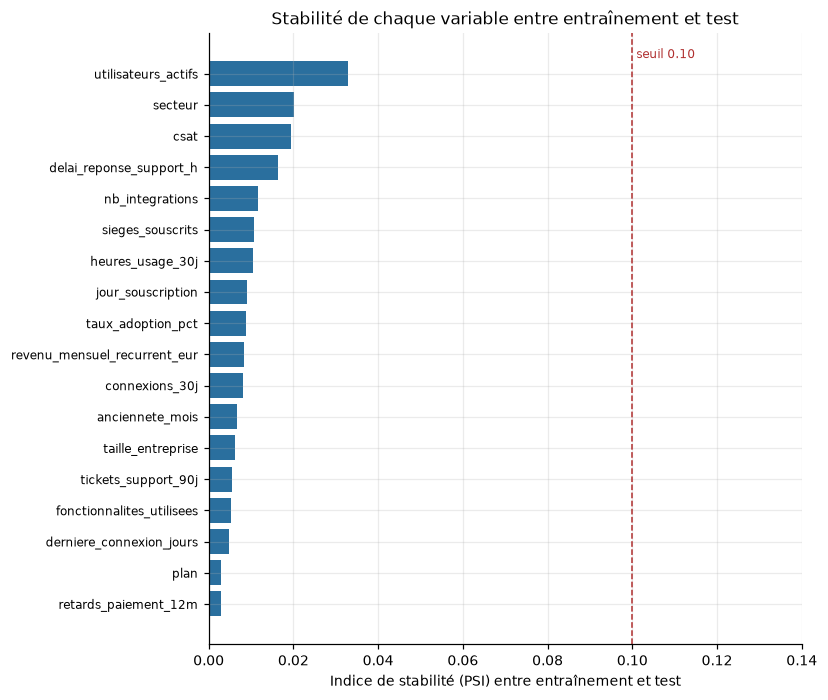

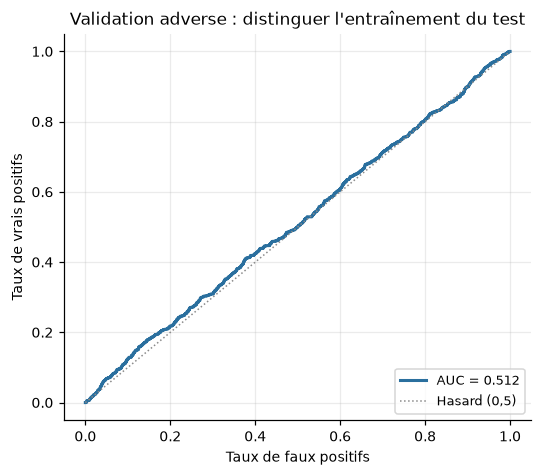

In [25]:
# --- Stability of each variable, and adversarial validation ---------------------------------
# Phase 5's heavy computations are recorded once, with the execution identity, and only
# redone when the code, the data or the protocol change (tools/selection_variables.py, B1).
import importlib.util

from churn_saas import config
from churn_saas.features import tracer_psi, tracer_validation_adverse
from churn_saas.monitoring import rapport_derive

_specification = importlib.util.spec_from_file_location(
    "selection_variables", RACINE / "tools" / "selection_variables.py")
_phase5 = importlib.util.module_from_spec(_specification)
_specification.loader.exec_module(_phase5)
phase5 = _phase5.en_objets(_phase5.executer())

rapport = rapport_derive(parties.X_entrainement, parties.X_test, list(X.columns),
                         config.SEUIL_PSI_DECOUPAGE)
tracer_psi(rapport, config.SEUIL_PSI_DECOUPAGE)
plt.show()
adverse = phase5["adverse"]
tracer_validation_adverse(adverse["taux_faux_positifs"], adverse["taux_vrais_positifs"], adverse["auc"])
plt.show()

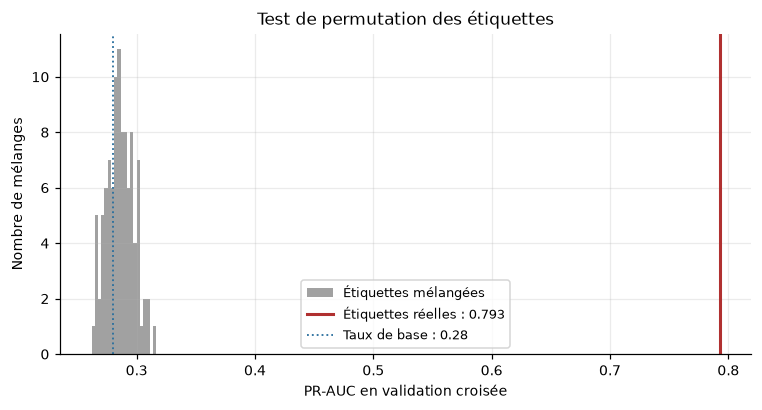

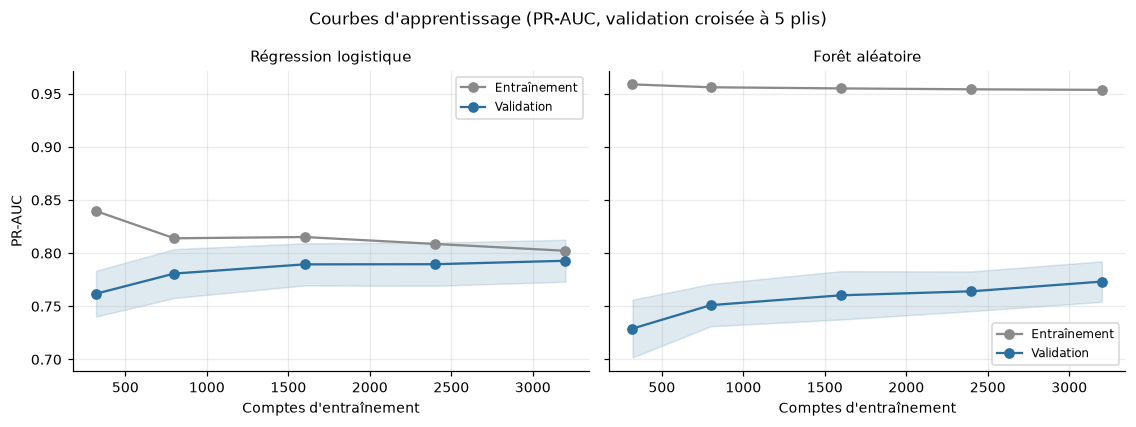

In [26]:
# --- Label permutation test and learning curves (recorded, see above) --------------------------
from churn_saas.features import tracer_courbes_apprentissage, tracer_permutation
from churn_saas.modelisation import construire_baseline, construire_candidat

permutation = phase5["permutation"]
tracer_permutation(permutation["scores_permutes"], permutation["score"],
                   float(parties.y_entrainement.mean()))
plt.show()
courbes = phase5["courbes"]
tracer_courbes_apprentissage(courbes)
plt.show()

In [27]:
# --- Every check against the rule fixed beforehand ----------------------------------------------
ecart = abs(parties.y_entrainement.mean() - parties.y_test.mean()) * 100
lr, foret = courbes["Régression logistique"].iloc[-1], courbes["Forêt aléatoire"].iloc[-1]
afficher_tableau(pd.DataFrame([
    ("Stratification", f"écart {ecart:.1f} point", f"< {config.ECART_STRATIFICATION_MAX_PTS}",
     ecart < config.ECART_STRATIFICATION_MAX_PTS),
    ("Stabilité (PSI maximal)", f"{rapport['psi'].max():.3f}", f"< {config.SEUIL_PSI_DECOUPAGE}",
     not rapport["alerte"].any()),
    ("Validation adverse (AUC)", f"{adverse['auc']:.3f}", f"< {config.SEUIL_AUC_ADVERSE}",
     adverse["conforme"]),
    ("Test de permutation", f"{permutation['score']:.3f} contre {permutation['moyenne_permutee']:.3f}"
     f" mélangée, p = {permutation['p_valeur']:.3f}", f"p < {config.SEUIL_P_PERMUTATION}",
     permutation["conforme"]),
    ("Convergence, régression", f"écart {lr['écart entraînement - validation']:.3f}",
     "courbes qui se rejoignent", lr["écart entraînement - validation"] < 0.05),
    ("Convergence, forêt", f"écart {foret['écart entraînement - validation']:.3f}",
     "courbes qui se rejoignent", foret["écart entraînement - validation"] < 0.05),
], columns=["Contrôle", "Mesure", "Règle", "Conforme"]),
    titre="Séparation et jeu, contre les règles fixées le 01/10/2026")

Contrôle,Mesure,Règle,Conforme
Stratification,écart 0.0 point,< 1.0,True
Stabilité (PSI maximal),0.033,< 0.1,True
Validation adverse (AUC),0.512,< 0.6,True
Test de permutation,"0.793 contre 0.286 mélangée, p = 0.010",p < 0.05,True
"Convergence, régression",écart 0.009,courbes qui se rejoignent,True
"Convergence, forêt",écart 0.180,courbes qui se rejoignent,False


**La fuite, démontrée.** L'itération 1 du projet (ci-dessus) raconte qu'un premier modèle « devinait »
l'issue grâce à `sante_compte_fin_periode`, un score calculé en fin de période. La démonstration est refaite
ici : même modèle, mêmes plis, sans puis avec la variable, dans la seule partie d'entraînement.

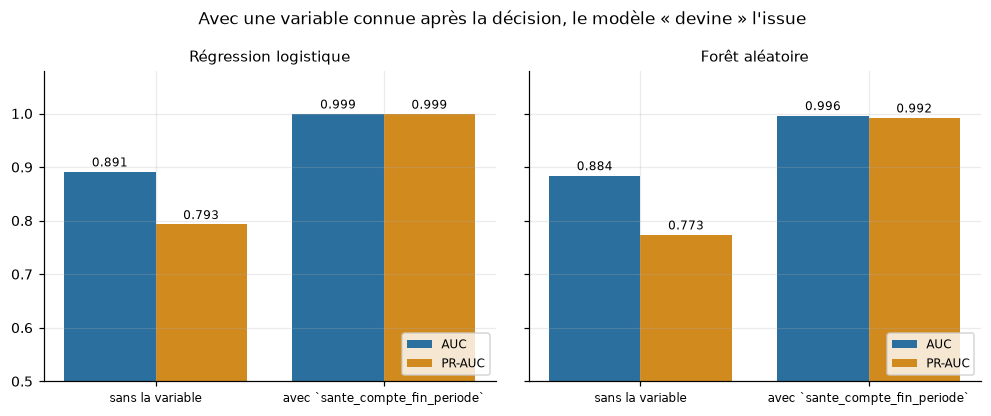

In [28]:
# --- Leak demonstration: same model, same folds, without then with the end-of-period score ---------
from churn_saas.features import tracer_demonstration_fuite

fuites = phase5["fuites"]
tracer_demonstration_fuite(fuites)
plt.show()

**Lecture.** Avec la variable, les deux modèles atteignent une AUC de 0,996 à 0,999 : une performance
quasi parfaite sur un problème de churn n'est pas un succès, c'est le **symptôme** qu'une variable contient la
réponse. Sans elle, la performance retombe à un niveau plausible (AUC 0,89). Le contrôle générique de fuite
(§ 6.6) l'avait désignée sans qu'on lui donne de nom ; la règle générale — aucune variable postérieure à la
décision — l'exclut (§ 7.3).

**Lecture.** La séparation est représentative : 28,0 % de churn dans chaque partie, aucune variable instable,
et un classifieur ne distingue pas l'entraînement du test (AUC proche de 0,5). La chaîne ne fuit pas : sur des
étiquettes mélangées cent fois, le modèle plafonne au taux de base, contre 0,79 sur les vraies. Le jeu
suffit : la régression logistique plafonne dès 1 600 comptes.

La forêt aléatoire, elle, **apprend par cœur** l'entraînement avec ses réglages actuels (écart de 0,19 entre
entraînement et validation) : c'est un défaut de **régularisation**, pas un manque de données, que la grille
d'hyperparamètres devra corriger (section 9). À ce stade, la régression logistique valide mieux (0,79 contre
0,77), mais la forêt n'a pas encore été réglée.

**Un défaut silencieux trouvé en chemin.** Le rapport de dérive lisait toute variable catégorielle comme
« sans alerte » (indice numérique → valeur manquante). Corrigé et testé : il servira en production (§ 13).

**Sobriété.** Tout le calcul de la phase 5 représente environ un quart d'heure sur le portable de
développement, et moins de deux grammes de CO₂e pour dix exécutions complètes (chiffrage généré :
`docs/06.SOBRIETE_calcul.md`). CodeCarbon est écarté, chiffres à l'appui (registre, E-502).

**Journal de bord [C4] [C5] — découpage et validation :**
- Décision : test de 20 % sous scellés et validation croisée 5 × 5, plutôt qu'un jeu de validation fixe
  (≈ 280 départs, ±5 points sur le rappel ; registre, E-503).
- Décision : enregistrer le découpage au manifeste, empreintes à l'appui. Motif : prouver que le jeu de test
  n'a jamais bougé.
- Constat : la forêt sur-apprend ; à régulariser avant toute comparaison.

### 8.B Les variables construites apportent-elles quelque chose ? (phase 5)

Le carnet `05_feature_engineering.ipynb` (§ 4 et 5) détaille la démarche ; l'essentiel est reporté ici. Toutes
les comparaisons se font sur **les mêmes 25 plis** (5 × 5, même graine), sur les 25 variables candidates
d'avant la sélection, dans la seule partie d'entraînement. Règle fixée le 01/10 : une variable construite est
gardée si son gain dépasse un écart-type entre plis.

modèle,PR-AUC référence,PR-AUC candidat,gain moyen,écart-type entre plis,plis où le candidat gagne,gain significatif
Régression logistique,0.790998,0.790244,-0.000755,0.019636,0.4,False
Forêt aléatoire,0.7711,0.769496,-0.001604,0.022122,0.32,False


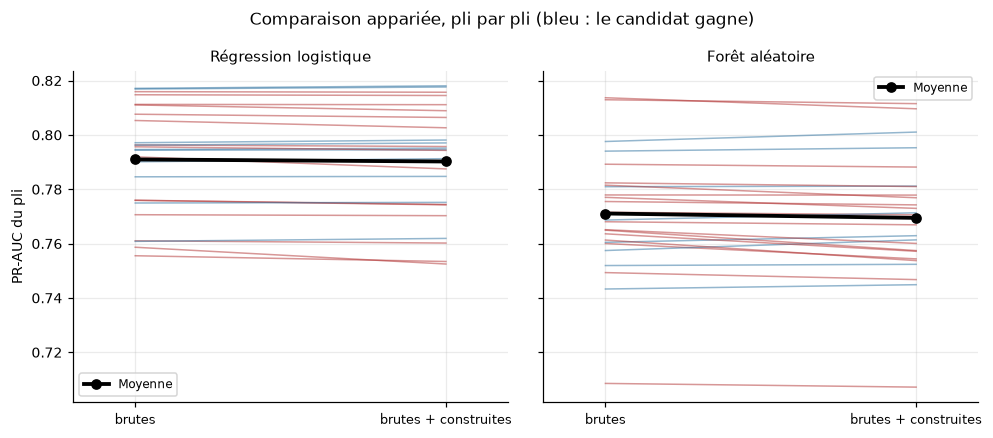

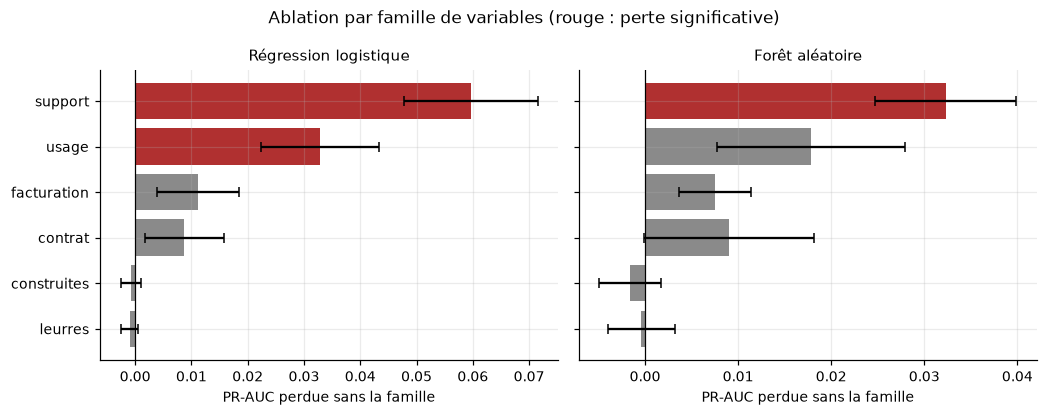

In [29]:
# --- Paired comparison and ablation by family (both models, recorded) ---------------------
from churn_saas.features import (parties_avant_selection, resumer_apport, tracer_ablation,
                                 tracer_courbes_appariees)

candidates_parties = parties_avant_selection(resultat)
XC, yC = candidates_parties.X_entrainement, candidates_parties.y_entrainement
apports = phase5["apports"]
afficher_tableau(pd.DataFrame({nom: resumer_apport(s, "brutes", "brutes + construites")
                               for nom, s in apports.items()}).T.round(4).reset_index(names="modèle"),
                 titre="Apport des variables construites")
tracer_courbes_appariees(apports, "brutes", "brutes + construites")
plt.show()
tracer_ablation(phase5["ablations"])
plt.show()

**Lecture.** Les variables construites **ne font rien gagner**, à aucun des deux modèles : le gain moyen est
légèrement négatif, sous un écart-type, et les plis se partagent entre gains et pertes. Par la règle fixée
d'avance, elles ne sont pas gardées. Le signal des comptes sans utilisateur actif existe bien (86,5 % de
churn), mais les variables brutes le portent déjà ; l'indicateur reste dans le jeu silver pour le lecteur.
L'ablation confirme par un second chemin : le **support** est la famille la plus porteuse, puis l'**usage** ;
retirer les variables construites ou les leurres ne coûte rien.

### 8.C Quelles variables garder ? (phase 5)

**Importance par permutation contre le plancher des leurres.** Les deux leurres mesurent le bruit. Une variable
est candidate au retrait si son importance ne dépasse pas ce plancher **pour les deux modèles**, puis retirée
seulement si son retrait ne coûte pas plus d'un écart-type.

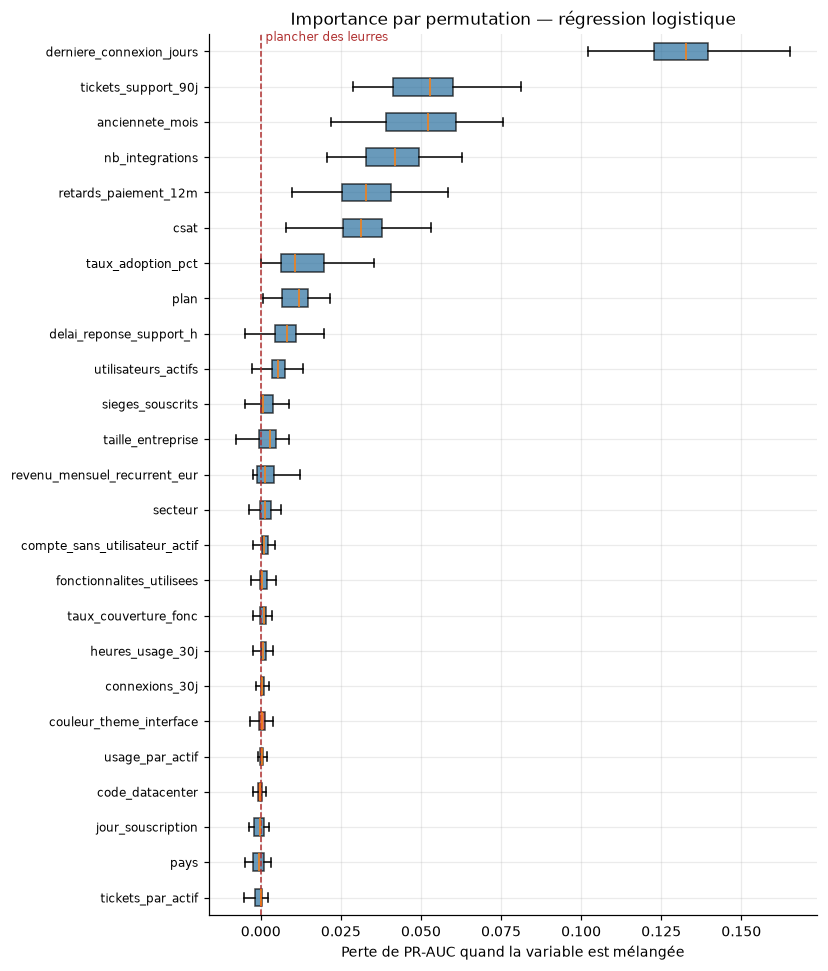

variable,perte moyenne,écart-type entre plis,retrait sans perte
usage_par_actif,-0.0001,0.0202,True
pays,-0.0016,0.0202,True


variable,perte moyenne,écart-type entre plis,retrait sans perte
usage_par_actif,-0.0001,0.0225,True
pays,-0.0012,0.0225,True


modèle,PR-AUC référence,PR-AUC candidat,gain moyen,écart-type entre plis,plis où le candidat gagne,gain significatif
Régression logistique,0.790244,0.7933,0.003057,0.020227,0.92,False
Forêt aléatoire,0.769496,0.772689,0.003193,0.022451,0.76,False


colonne,motif d'exclusion
code_datacenter,"leurre — étalon du bruit pendant la sélection, retiré du modèle final (phase 5)"
compte_sans_utilisateur_actif,"variable construite — apport non significatif mesuré (phase 5, bloc B)"
couleur_theme_interface,"leurre — étalon du bruit pendant la sélection, retiré du modèle final (phase 5)"
pays,"sous le plancher des leurres (deux modèles), retrait sans perte (phase 5, bloc C)"
taux_couverture_fonc,"variable construite — apport non significatif mesuré (phase 5, bloc B)"
tickets_par_actif,"variable construite — apport non significatif mesuré (phase 5, bloc B)"
usage_par_actif,"variable construite — apport non significatif mesuré (phase 5, bloc B)"


Variables du modèle : 18 — jour_souscription, secteur, taille_entreprise, plan, anciennete_mois, sieges_souscrits, utilisateurs_actifs, taux_adoption_pct, connexions_30j, heures_usage_30j, fonctionnalites_utilisees, nb_integrations, derniere_connexion_jours, tickets_support_90j, delai_reponse_support_h, csat, retards_paiement_12m, revenu_mensuel_recurrent_eur


In [30]:
# --- Importance against the decoys' floor, confirmation, final set (recorded) ------------------
from churn_saas.config import EXCLUES_PAR_SELECTION
from churn_saas.features import LEURRES, tracer_importances

importances = phase5["importances"]
tracer_importances(importances["Régression logistique"], LEURRES,
                   "Importance par permutation — régression logistique")
plt.show()
for nom, table in phase5["confirmations"].items():
    afficher_tableau(table, titre=f"Retrait des candidates — {nom}")

retenues = [c for c in XC.columns if c not in EXCLUES_PAR_SELECTION]
final = phase5["final"]
afficher_tableau(pd.DataFrame({nom: resumer_apport(s, "25 candidates", f"{len(retenues)} retenues")
                               for nom, s in final.items()}).T.round(4).reset_index(names="modèle"),
                 titre="La sélection complète coûte-t-elle quelque chose ?")
afficher_tableau(exclusions[exclusions["colonne"].isin(EXCLUES_PAR_SELECTION)],
                 titre="Retraits de la sélection, avec leur motif")
print(f"Variables du modèle : {X.shape[1]} — {', '.join(X.columns)}")

**Lecture.** Deux variables passent sous le plancher des leurres pour les deux modèles, `usage_par_actif` et
`pays`, et leur retrait ne coûte rien. La sélection complète — quatre variables construites, `pays` et les deux
leurres, soit sept retraits — **ne coûte rien non plus** : le jeu final fait même très légèrement mieux sur la
plupart des plis. Aucun facteur d'inflation de la variance n'atteint 10 depuis la réduction du catalogue.

**Le jeu du modèle : 18 variables.** Retirer `pays` du modèle n'empêche pas de vérifier l'équité par pays : elle
se mesure sur les décisions du modèle, croisées avec le pays conservé dans le jeu silver (section 12).

**Journal de bord [C3] [C5] — sélection des variables :**
- Décision : appliquer les règles fixées avant les résultats, y compris quand elles retirent une variable
  construite qui portait le signal le plus spectaculaire de l'exploration. Motif : les variables brutes le
  portent déjà, et un modèle plus simple s'explique mieux.
- Décision : exiger le plancher pour **les deux** modèles avant de proposer un retrait, et une seconde preuve
  (retrait sans perte) avant de l'appliquer.
- Constat : les importances négatives de la forêt aléatoire confirment son sur-apprentissage (§ 8.A) ; elle
  sera réglée avant d'être comparée à la régression logistique.

### 8.D Les références : protocole d'évaluation et baselines (phase 6)

Avant de chercher un meilleur modèle, il faut savoir contre quoi il se mesurera. Le **protocole d'évaluation**
est écrit dans `evaluation/protocole.py` avant tout résultat : les 25 plis partagés avec la phase 5, dans la
seule partie d'entraînement ; la PR-AUC comme critère principal ; la ROC-AUC exigée par l'énoncé ; le rappel et
la précision dans les **10 % de comptes les plus risqués** ; et la **calibration**, parce que la règle de
décision multiplie la probabilité par la valeur du compte.

Trois références sont mesurées : la baseline **naïve** (le taux de base pour tous), une **règle métier** —
classer par ancienneté de la dernière connexion, ce qu'un CSM ferait sans modèle — et la **régression
logistique** du cadrage. Le carnet `06_baseline.ipynb` détaille la démarche.

référence,PR-AUC,ROC-AUC,rappel haut,précision haut,Brier,erreur de calibration
naïve,0.280 ± 0.000,0.500 ± 0.000,0.102 ± 0.014,0.287 ± 0.040,0.202 ± 0.000,0.000 ± 0.000
règle métier,0.530 ± 0.019,0.674 ± 0.019,0.258 ± 0.011,0.723 ± 0.031,—,—
régression logistique,0.793 ± 0.019,0.892 ± 0.011,0.331 ± 0.007,0.926 ± 0.019,0.133 ± 0.007,0.114 ± 0.012


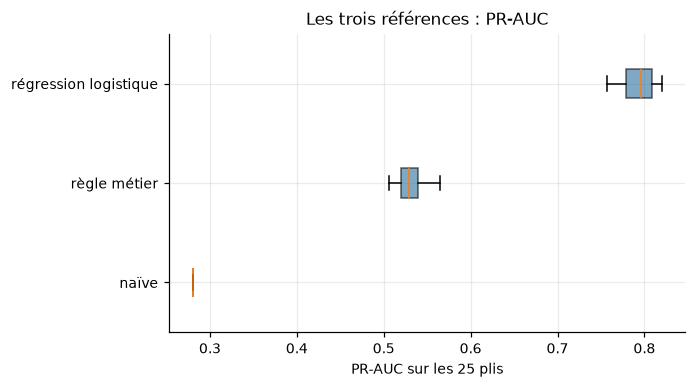

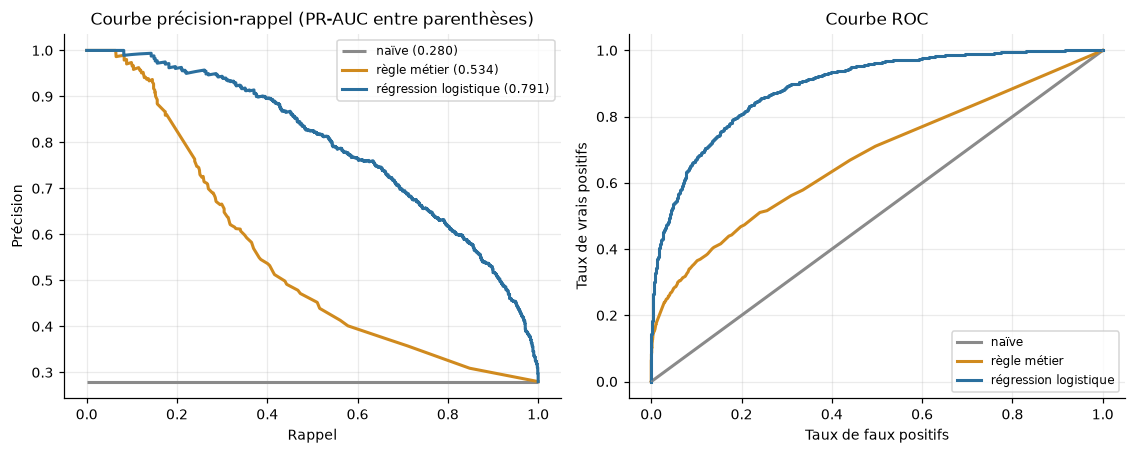

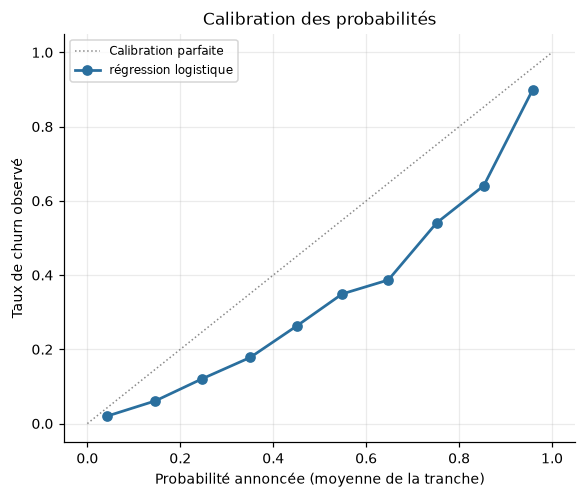

Erreur de calibration de la régression logistique : 0.115 (seuil fixé d'avance : 0.05)


In [31]:
# --- The three baselines under the protocol ----------------------------------------------------
from churn_saas.evaluation import erreur_calibration, evaluer_selon_protocole, resumer
from churn_saas.features import tracer_baselines, tracer_calibration, tracer_courbes_pr_roc
from churn_saas.modelisation import construire_baseline_metier, construire_baseline_naive

Xe, ye = parties.X_entrainement, parties.y_entrainement
baselines = {
    "naïve": evaluer_selon_protocole(construire_baseline_naive, Xe, ye),
    "règle métier": evaluer_selon_protocole(construire_baseline_metier, Xe, ye, probabiliste=False),
    "régression logistique": evaluer_selon_protocole(construire_baseline, Xe, ye),
}
afficher_tableau(resumer(baselines).reset_index(names="référence"),
                 titre="Les trois références, moyenne ± écart-type sur les 25 plis")
tracer_baselines({n: r.par_pli for n, r in baselines.items()})
plt.show()
tracer_courbes_pr_roc({nom: (ye, r.hors_pli) for nom, r in baselines.items()})
plt.show()
tracer_calibration({"régression logistique": (ye, baselines["régression logistique"].hors_pli)})
plt.show()
print(f"Erreur de calibration de la régression logistique : "
      f"{erreur_calibration(ye, baselines['régression logistique'].hors_pli):.3f} "
      f"(seuil fixé d'avance : {config.SEUIL_ERREUR_CALIBRATION})")

**Lecture.**
- La **règle métier** fait nettement mieux que le hasard (PR-AUC 0,53 contre 0,28) : la dernière connexion est
  un vrai signal.
- La **régression logistique** la dépasse largement (0,79), **sur chacun des 25 plis** : combiner les variables
  apporte bien plus que la meilleure d'entre elles seule. C'est la réponse à la question « pourquoi un modèle
  plutôt qu'une règle ? ».
- Dans les 10 % de comptes les plus risqués, **plus de 9 signalements sur 10 sont de vrais départs**.
- La régression logistique est **mal calibrée** : elle annonce des probabilités plus élevées que les départs
  observés (erreur ≈ 0,11, au-delà du seuil de 0,05). C'est l'effet attendu de la pondération des classes, qui
  aide à ordonner mais gonfle les probabilités. **La phase 7 calibrera le modèle retenu.**

**Les résultats de référence sont enregistrés** dans `resultats/reference_baseline.json`, pli par pli, avec le
protocole et l'empreinte du jeu gold. La phase 7 se comparera à cette référence figée ; un test vérifie que le
code la reproduit.

**Journal de bord [C4] [C5] — références :**
- Décision : une baseline **métier** en plus de la baseline du cadrage. Motif : un modèle doit prouver qu'il
  vaut mieux que ce qu'un CSM ferait seul, pas seulement mieux que le hasard.
- Décision : mesurer la calibration dès la baseline. Motif : la règle de décision multiplie la probabilité
  par la valeur du compte ; un classement juste avec des probabilités fausses produirait un classement par
  valeur faux.
- Écarté : le seuil fixe de 0,5 et le F1, qui supposent des erreurs de coût égal (registre).

### 8.E Traçabilité des expériences : MLflow (phase 7, bloc 7.0)

Chaque entraînement est désormais tracé dans MLflow, dans un magasin local (`mlruns/`, ouvert par
`make mlflow`). MLflow est un **journal**, pas une source de vérité : le manifeste, `resultats/` et les tests font
foi, et des tests vérifient qu'il dit la même chose qu'eux. La chaîne ci-dessous trace trois runs — forêt
(autolog scikit-learn), XGBoost (autolog xgboost), régression logistique (tracée à la main, matrice de confusion
au haut 10 % en artefact) —, les compare **sur les métriques hors pli du protocole**, enregistre le meilleur au
registre sous l'alias `challenger`, le recharge et score l'échantillon. La recherche par grille est exécutée dans
le carnet `07_suivi_mlflow.ipynb`.

In [32]:
# --- Three tracked runs, compared on out-of-fold metrics, best one registered and reloaded --------
import importlib.util

_specification = importlib.util.spec_from_file_location(
    "pipeline_mlflow", RACINE / "tools" / "pipeline_mlflow.py")
_chaine = importlib.util.module_from_spec(_specification)
_specification.loader.exec_module(_chaine)
bilan_mlflow = _chaine.executer(avec_grille=False)
afficher_tableau(pd.DataFrame(bilan_mlflow["comparaison"]).rename(columns=lambda c: c.split(".")[-1]),
                 titre="mlflow.search_runs() — classement par PR-AUC hors pli")
print(f"Meilleur : {bilan_mlflow['meilleur']} — registre version {bilan_mlflow['version_registre']} "
      f"(alias challenger) ; rechargé, il prédit comme le modèle en mémoire : "
      f"{bilan_mlflow['registre_identique_au_modele_en_memoire']}")

Exécution identique déjà enregistrée (688fc714) : rien n'est recalculé. --forcer pour la rejouer.


runName,pr_auc_cv,rappel_haut_cv,roc_auc_cv,erreur_calibration_cv
regression logistique · manuel,0.7933,0.3305,0.8915,0.1143
xgboost · xgboost.autolog,0.7741,0.3220,0.8799,0.0802
foret · sklearn.autolog,0.7727,0.3177,0.8830,0.1053


Meilleur : regression logistique · manuel — registre version 12 (alias challenger) ; rechargé, il prédit comme le modèle en mémoire : True


**Lecture.** La régression logistique reste en tête (0,793), les modèles d'arbres se groupent autour de 0,77 :
la chaîne MLflow retrouve les chiffres des § 8.B à 8.D, elle les trace sans les changer.

**Le piège de l'autolog.** L'autolog mesure les modèles **sur leurs lignes d'entraînement** : la forêt y affiche
un recall de 0,92, contre 0,32 hors pli au haut du classement. Classés sur ces chiffres, les runs auraient désigné
le modèle qui apprend par cœur. La comparaison ne lit donc que les métriques hors pli communes (registre, E-703).

**Journal de bord [C5] [C6] — suivi des expériences :**
- Décision : un magasin local en chemin absolu, pour qu'un carnet et un outil écrivent au même endroit.
- Décision : journaliser la **chaîne complète** avec sa signature, jamais l'estimateur seul.
- Décision : alias `challenger` pour le meilleur actuel, ni réglé ni calibré ; `champion` attendra la fin de la
  phase 7. Le scoring de l'échantillon vérifie le fonctionnement, il n'évalue rien : le test reste scellé.

## 9. Entraînement, validation et ajustement (sélection du modèle final) — journal de bord [C5]

**Réaligné en phase 7.** Les règles qui décident ont été **validées et committées le 02/10/2026, avant le premier
calcul** (choix méthodologiques § 7 quinquies) ; un test empêche qu'elles changent sans trace.

| # | Règle |
|---|---|
| B1 | Un candidat ne remplace la régression logistique que si son gain de PR-AUC, **apparié sur les 25 plis**, dépasse un écart-type ; à égalité, le plus simple |
| B2 | Calibration sigmoïde ou isotone, choisie dans les plis ; objectif d'erreur sous 0,05 |
| B3 | Grilles bornées : forêt (36 combinaisons), XGBoost (24) |
| B4 | **Une seule** évaluation sur le jeu de test, intervalles à 95 % par bootstrap |
| B5 | Valeur client : régression linéaire contre forêt de régression |


### 9.A Réglage et comparaison à la référence figée (B1, B3)

Les deux familles d'arbres sont réglées sur leur grille, puis mesurées sur les 25 plis du protocole et comparées,
**pli par pli**, aux scores de la régression logistique enregistrés en phase 6 (`resultats/reference_baseline.json`).
Le code est celui de `tools/selection_modele.py` ; un calcul déjà fait à l'identique n'est pas refait.

Sélection identique déjà enregistrée : rien n'est recalculé (--forcer pour la refaire).


famille,modele__class_weight,modele__max_depth,modele__min_samples_leaf,modele__n_estimators,PR-AUC grille,modele__learning_rate,modele__min_child_weight
forêt aléatoire,None,10,5,100,0.7748,NaN,NaN
xgboost,NaN,3,NaN,200,0.7794,0.05,5


modèle,PR-AUC,gain apparié,seuil (1 écart-type),plis gagnés,gain significatif
régression logistique,0.7933,0.0000,0.0188,0,False
forêt aléatoire,0.7738,-0.0195,0.0188,1,False
xgboost,0.7803,-0.0130,0.0188,1,False


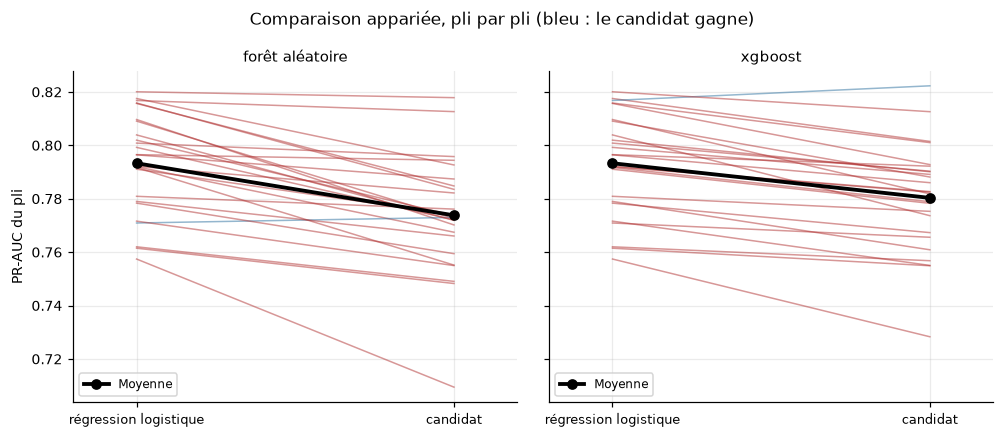

Modèle retenu par la règle B1 : régression logistique


In [33]:
# --- Tuning, paired comparison against the frozen reference (rules B1, B3) ------------------------
import importlib.util
import json


def _outil(nom):
    specification = importlib.util.spec_from_file_location(nom, RACINE / "tools" / f"{nom}.py")
    module = importlib.util.module_from_spec(specification)
    specification.loader.exec_module(module)
    return module


selection = _outil("selection_modele").executer()
afficher_tableau(pd.DataFrame([{"famille": f, **r["meilleurs_parametres"], "PR-AUC grille": r["pr_auc_grille"]}
                               for f, r in selection["reglages"].items()]),
                 titre="Meilleurs réglages trouvés par les grilles")
afficher_tableau(pd.DataFrame(selection["comparaison"]),
                 titre="Comparaison appariée à la régression logistique (25 plis)")
from churn_saas.features import tracer_courbes_appariees

_reference = selection["par_pli"]["régression logistique"]
tracer_courbes_appariees({nom: pd.DataFrame({"régression logistique": _reference, "candidat": valeurs})
                          for nom, valeurs in selection["par_pli"].items() if nom != "régression logistique"},
                         "régression logistique", "candidat")
plt.show()
print("Modèle retenu par la règle B1 :", selection["modele_retenu"])

**Lecture.** Même réglés, la forêt (0,774) et XGBoost (0,780) font **moins bien** que la régression logistique
(0,793), qui gagne sur 24 plis sur 25. Par la règle B1, le modèle le plus simple et le plus explicable est retenu.
Les réglages retenus confirment le constat de la phase 5 : la forêt n'est meilleure que **bridée** (profondeur 10),
et XGBoost préfère des arbres peu profonds (profondeur 3) — le signal est largement additif, ce qu'une régression
capte très bien.

### 9.B Calibration du modèle retenu (B2)

La phase 6 a mesuré une erreur de calibration de 0,114 : la pondération des classes gonfle les probabilités. La
calibration est apprise **dans chaque pli d'entraînement**, par une validation croisée interne.

méthode,PR-AUC,erreur de calibration,erreur hors pli (première répétition)
sigmoid,0.7934,0.0298,0.0097
isotonic,0.7901,0.0318,0.0124


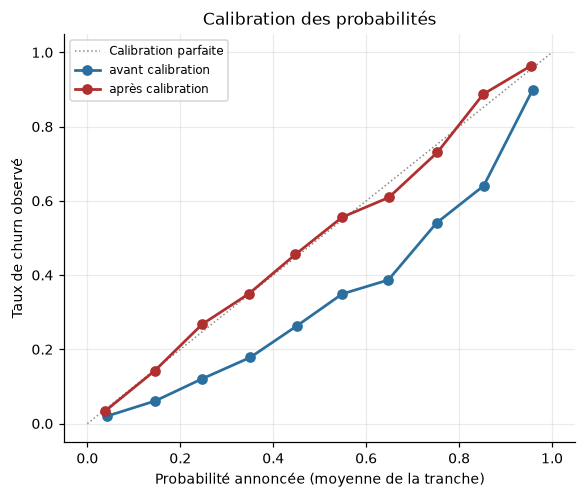

In [34]:
# --- Calibration chosen inside the folds (rule B2) ------------------------------------------------
from churn_saas.evaluation import evaluer_selon_protocole
from churn_saas.features import tracer_calibration
from churn_saas.modelisation import construire_calibre

afficher_tableau(pd.DataFrame(selection["calibration"]["methodes"]).T.reset_index(names="méthode"),
                 titre=f"Méthode retenue : {selection['calibration']['methode_retenue']}")
_brute = evaluer_selon_protocole(construire_baseline, parties.X_entrainement, parties.y_entrainement)
_calibree = evaluer_selon_protocole(construire_calibre(construire_baseline, selection["calibration"]["methode_retenue"]),
                                    parties.X_entrainement, parties.y_entrainement)
tracer_calibration({"avant calibration": (parties.y_entrainement, _brute.hors_pli),
                    "après calibration": (parties.y_entrainement, _calibree.hors_pli)})
plt.show()

**Lecture.** Après calibration sigmoïde, les points rejoignent la diagonale : l'erreur passe de 0,114 à
**0,030**, sous l'objectif de 0,05, et la PR-AUC ne change pas (0,793) — la calibration corrige les probabilités
sans toucher à l'ordre des comptes. La règle de décision pourra multiplier ces probabilités par la valeur des
comptes.

### 9.C L'évaluation unique sur le jeu de test (B4)

Le jeu de test, mis sous scellés en phase 5, a été ouvert **une seule fois**, par `tools/evaluation_finale.py`,
qui refuse toute seconde lecture non motivée. Ce notebook **lit** son résultat ; il ne réévalue pas.

In [35]:
# --- The single test evaluation, read - never recomputed (rule B4) ---------------------------------
from churn_saas.packaging import charger_modele

evaluation = json.loads((RACINE / "resultats" / "evaluation_finale.json").read_text(encoding="utf-8"))
afficher_tableau(pd.DataFrame({"sur le test": evaluation["metriques"],
                               "intervalle à 95 %": {k: f"[{a:.3f} ; {b:.3f}]"
                                                     for k, (a, b) in evaluation["intervalles_95"].items()}})
                 .reset_index(names="métrique"),
                 titre=f"{evaluation['modele']} — {evaluation['comptes_test']} comptes, évalués le {evaluation['date']}")
# The SERVED model (phase 8, decision c): one calibrated copy of the same regression,
# equivalent to the evaluated champion (section 9.G); built from the training part only.
_servi = _outil("modele_servi").executer()
# The file in service is the one the `champion` alias names, hash checked - the very file the API
# loads, through the same CHURN_ALIASES setting (resultats/aliases_modeles.json by default).
import os
from pathlib import Path

from churn_saas.packaging import charger_champion, lire_aliases

_aliases = Path(os.environ.get("CHURN_ALIASES", RACINE / "resultats" / "aliases_modeles.json"))
MODELE_FINAL, fiche_modele = charger_champion(_aliases)
_champion = lire_aliases(_aliases)["champion"]
print(f"Modèle évalué sur le test : 5 copies calibrées — PR-AUC {evaluation['metriques']['PR-AUC']} ; "
      f"modèle servi : {_champion['nom']} {_champion['version']}, alias champion "
      f"(une copie, équivalence démontrée au § 9.G)")

métrique,sur le test,intervalle à 95 %
PR-AUC,0.7612,[0.712 ; 0.806]
ROC-AUC,0.8815,[0.858 ; 0.904]
rappel haut,0.3143,[0.284 ; 0.351]
précision haut,0.8800,[0.810 ; 0.940]
Brier,0.1206,[0.107 ; 0.133]
erreur de calibration,0.0364,[0.028 ; 0.061]


Modèle servi déjà construit à l'identique : rien n'est recalculé.


Modèle évalué sur le test : 5 copies calibrées — PR-AUC 0.7612 ; modèle servi : churn_saas_servi 1.1, alias champion (une copie, équivalence démontrée au § 9.G)


**Lecture.** Sur 1 000 comptes jamais vus, la PR-AUC est de **0,761** [0,712 ; 0,806] : la valeur de validation
croisée (0,793) est dans l'intervalle, le modèle généralise comme le protocole le prévoyait. Dans les 10 % de
comptes les plus risqués, **88 %** des signalements sont de vrais départs. L'erreur de calibration (0,036) reste
sous l'objectif. Le modèle est écrit dans `models/` avec sa fiche, et enregistré au registre MLflow sous l'alias
`champion`.

### 9.D Le modèle secondaire : valeur client des comptes récents (B5)

In [36]:
# --- Lifetime value model for accounts too recent to have one (rule B5) ---------------------------
valeur_vie = _outil("modele_valeur_vie").executer()
afficher_tableau(pd.DataFrame(valeur_vie["r2_log_moyen"], index=["R² (log), moyenne sur 5 plis"]).T
                 .reset_index(names="modèle"),
                 titre=f"Retenu : {valeur_vie['modele_retenu']} (seuil : {valeur_vie['seuil_un_ecart_type']})")

Comparaison identique déjà enregistrée : rien n'est recalculé.


modèle,"R² (log), moyenne sur 5 plis"
régression linéaire,0.8046
forêt de régression,0.8879


**Lecture.** La forêt de régression explique 89 % de la variance du logarithme de la valeur, contre 80 % pour la
régression linéaire : le gain dépasse très largement le seuil, la forêt est retenue. La régression du diagnostic de
la phase 5 atteignait 0,895 parce qu'elle utilisait le logarithme du revenu ; ajouter ce terme maintenant, après
avoir vu le résultat, serait ajuster la comparaison à son issue — la règle fixée d'avance tranche.

**Journal de bord [C5] — phase 7 :**
- Décision : la **régression logistique calibrée** (sigmoïde) est le modèle de churn retenu ; les arbres réglés ne
  font pas mieux. Motif : règle B1, et un modèle additif s'explique compte par compte.
- Décision : la **forêt de régression** estime la valeur client des comptes récents (règle B5).
- Garde-fou conservé : une AUC anormalement élevée déclencherait une recherche de fuite (démonstration au § 8.A).
- Évaluation finale faite **une fois** ; toute seconde lecture exige un motif consigné.

### 9.E Règle de décision économique (phase 9 — règles R1 à R5)

Pour un compte de valeur V et de probabilité de départ p, contacter rapporte en espérance p × V × efficacité, et
coûte un contact. La **valeur espérée nette** p × V × efficacité − coût est positive exactement quand p dépasse le
**seuil propre au compte** p* = coût / (coût + efficacité × V). L'équipe traite les comptes rentables de plus forte
valeur nette, dans la limite de sa capacité. Paramètres (hypothèses du cadrage) : efficacité 0,25, coût d'un contact
135 €, capacité 140 comptes par mois. Calcul sur la **partie d'entraînement**, sans le jeu de test
(`tools/regle_decision.py`).

Règle de décision déjà calculée à l'identique : rien n'est recalculé.


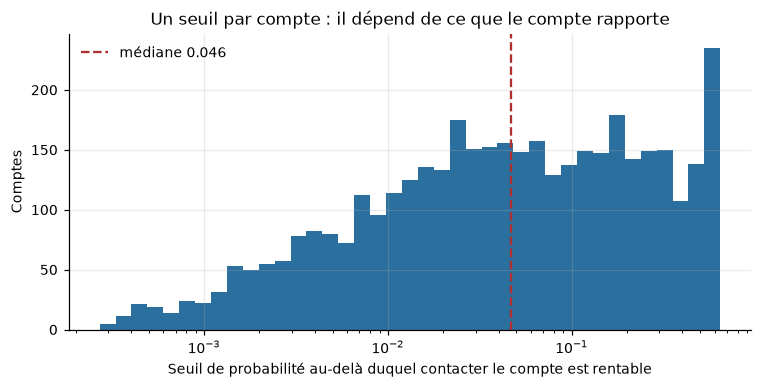

repère,seuil
minimum,0.0003
quantile 5 %,0.0016
quantile 25 %,0.0119
quantile 50 %,0.0464
quantile 75 %,0.1781
quantile 95 %,0.5661
maximum,0.6429
rapport 95 % / 5 %,355.8450


efficacité,coût d'un contact (€),comptes rentables,part rentable,comptes traités (capacité),valeur nette des comptes traités (€)
0.15,94.5,2740,0.6850,112,5229651.0
0.15,135.0,2494,0.6235,112,5225115.0
0.15,175.5,2333,0.5833,112,5220579.0
0.25,94.5,3025,0.7562,112,8723141.0
0.25,135.0,2833,0.7083,112,8718605.0
0.25,175.5,2662,0.6655,112,8714069.0
0.40,94.5,3255,0.8137,112,13963375.0
0.40,135.0,3084,0.7710,112,13958839.0
0.40,175.5,2942,0.7355,112,13954303.0


Stabilité de la liste (R4, 50 rééchantillonnages) : Jaccard moyen 0.87, minimum 0.76 — seuil 0,70 ; comptes traités : 112, taux de départ 62% contre 28%


In [37]:
# --- Decision rule R3 and list stability R4, on the training part ---------------------------------
from churn_saas.features import tracer_seuils

regle_9 = _outil("regle_decision").executer()
tracer_seuils(regle_9["seuils_par_compte"])
plt.show()
afficher_tableau(pd.Series(regle_9["seuils"]).round(4).to_frame("seuil").reset_index(names="repère"),
                 titre="Distribution des seuils rationnels par compte")
afficher_tableau(pd.DataFrame(regle_9["hypotheses"]),
                 titre=f"Comptes rentables selon les hypothèses (capacité ramenée : {regle_9['capacite_ramenee']})")
_st = regle_9["stabilite"]
print(f"Stabilité de la liste (R4, 50 rééchantillonnages) : Jaccard moyen {_st['jaccard_moyen']:.2f}, "
      f"minimum {_st['jaccard_minimum']:.2f} — seuil 0,70 ; comptes traités : {regle_9['comptes_traites']}, "
      f"taux de départ {regle_9['taux_de_depart_des_traites']:.0%} contre {regle_9['taux_de_depart_global']:.0%}")

**Lecture.** Les seuils varient d'un **facteur 356** entre les comptes (quantiles 5 % et 95 %) : un seuil unique
supposerait que tous les comptes se valent. La moitié des comptes mériterait un contact dès 4,6 % de risque, et
**71 % des comptes seraient rentables à contacter** — de 58 % à 81 % selon les hypothèses. La contrainte réelle est
donc la **capacité** de l'équipe, pas la rentabilité. Faire varier l'efficacité ou le coût ne change pas l'ordre de la
liste (facteurs communs à tous les comptes) ; ce qui pourrait la changer, c'est l'incertitude du modèle : réentraîné
sur 50 échantillons différents, il retrouve en moyenne **87 %** de la même liste (minimum 76 %, seuil 70 %).

### 9.F Explicabilité du modèle retenu (B6, option C)

**Décision du 03/10/2026.** En production, l'explication donnée au conseiller vient des **contributions linéaires
exactes** du modèle retenu : pour chaque variable, *coefficient × (valeur du compte − valeur moyenne)*, sur
l'échelle des cotes. C'est ce que calcule SHAP pour un modèle linéaire, mais sans dépendance et sans approximation.
SHAP sert **une fois**, ici, à une autre question : les trois modèles s'appuient-ils sur les mêmes facteurs de
risque ? SHAP ne dit pas quel modèle est le meilleur — le protocole l'a fait (B1) ; il dit sur quoi chacun s'appuie.

Comparaison des explications déjà enregistrée : rien n'est recalculé.


paire,corrélation des rangs (Spearman),variables communes au top 5
régression logistique / forêt aléatoire,0.560,3
régression logistique / xgboost,0.593,3
forêt aléatoire / xgboost,0.961,4


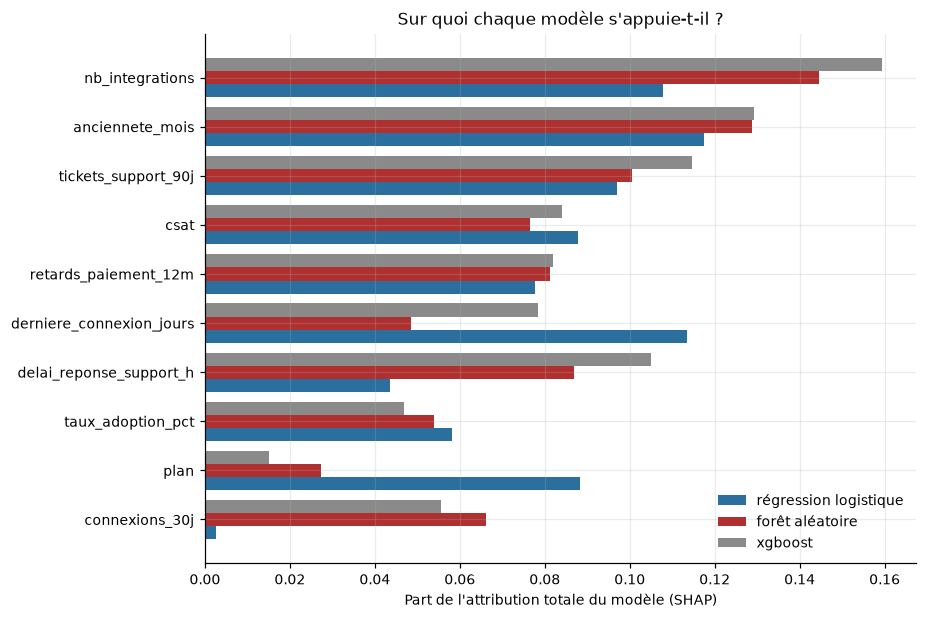

Facteurs du top 5 communs aux trois modèles : nb_integrations, anciennete_mois, tickets_support_90j


In [38]:
# --- Do the three models rely on the same risk factors? (SHAP, recorded once) ------------------------
from churn_saas.features import tracer_facteurs_compares

explications = _outil("comparaison_explicabilite").executer()
afficher_tableau(pd.DataFrame(explications["accords"]), titre="Accord entre les modèles sur leurs facteurs")
tracer_facteurs_compares(pd.DataFrame(explications["parts"]))
plt.show()
print("Facteurs du top 5 communs aux trois modèles :", ", ".join(explications["top_5_commun_aux_trois"]))

**Lecture.** Les **intégrations**, l'**ancienneté** et les **tickets de support** figurent parmi les cinq premiers
facteurs des trois modèles : le constat ne dépend pas du modèle choisi. La forêt et XGBoost s'accordent presque
parfaitement (corrélation des rangs 0,96). La régression s'en distingue sur deux points : elle donne plus de poids à
la **dernière connexion**, moins au **délai de réponse du support** — un effet de seuil que les arbres captent et
qu'une relation linéaire résume moins bien. La régression reste retenue : elle classe mieux (B1), et c'est ce
classement que le conseiller reçoit, avec son explication exacte ci-dessous.

In [39]:
# --- In production: the advisor's explanation, from the exact linear contributions -------------------
from churn_saas.evaluation import contributions_lineaires, expliquer_par_contributions, motif_lisible

_risque = pd.Series(MODELE_FINAL.predict_proba(parties.X_entrainement)[:, 1], index=parties.X_entrainement.index)
_contributions, _base = contributions_lineaires(MODELE_FINAL, parties.X_entrainement.head(500),
                                                parties.X_entrainement)
print(f"Exactitude : écart maximal entre base + contributions et le score du modèle = "
      f"{abs(_base + _contributions.sum(axis=1) - np.mean([c.estimator.decision_function(parties.X_entrainement.head(500)) for c in MODELE_FINAL.calibrated_classifiers_], axis=0)).max():.1e}")
for compte in _risque.nlargest(3).index:
    print(f"Compte {compte} — risque {_risque[compte]:.0%} — "
          + motif_lisible(expliquer_par_contributions(MODELE_FINAL, parties.X_entrainement, compte,
                                                      fond=parties.X_entrainement)))

Exactitude : écart maximal entre base + contributions et le score du modèle = 1.8e-15


Compte 2004 — risque 100% — Facteurs principaux : derniere_connexion_jours (136.0) augmente le risque ; tickets_support_90j (12.0) augmente le risque ; csat (1.0) augmente le risque.
Compte 1340 — risque 100% — Facteurs principaux : derniere_connexion_jours (200.0) augmente le risque ; plan (Enterprise) diminue le risque ; anciennete_mois (19.0) diminue le risque.


Compte 1904 — risque 100% — Facteurs principaux : derniere_connexion_jours (147.0) augmente le risque ; nb_integrations (0.0) augmente le risque ; taux_adoption_pct (0.0) augmente le risque.


**Journal de bord [C4] [C8] — explicabilité :**
- Décision (B6, option C) : contributions linéaires exactes en production, SHAP réservé à l'analyse. Motif : pour le
  modèle retenu, l'explication linéaire est exacte et sans dépendance ; SHAP apporte la comparaison entre modèles.
- Constat : trois facteurs communs aux trois modèles — robustesse de l'analyse indépendante du modèle.
- Limite : une contribution est une **attribution**, pas une cause ; les variables corrélées (sièges, revenu,
  connexions) se partagent leur contribution.

### 9.G Réglage, surapprentissage et ressources (phase 8)

Les règles ont été **validées avant le calcul** — commit de décision archivé dans `docs/livraisons/` (choix méthodologiques § 7 sexies). Le calcul est
celui de `tools/reglage_modele.py` ; un calcul déjà fait à l'identique n'est pas refait. Les ressources ont été
**mesurées sur le poste de développement**.

Réglage identique déjà enregistré : rien n'est recalculé.


C,class_weight,PR-AUC validation,écart-type,PR-AUC entraînement,écart entraînement - validation
0.01,None,0.7936,0.0195,0.7981,0.0045
0.01,balanced,0.7931,0.0193,0.7972,0.0041
0.03,None,0.7943,0.0192,0.8010,0.0068
0.03,balanced,0.7940,0.0191,0.8000,0.0060
0.10,None,0.7940,0.0187,0.8028,0.0089
0.10,balanced,0.7938,0.0189,0.8016,0.0078
0.30,None,0.7935,0.0186,0.8034,0.0099
0.30,balanced,0.7935,0.0187,0.8021,0.0086
1.00,None,0.7932,0.0184,0.8036,0.0103
1.00,balanced,0.7933,0.0185,0.8022,0.0089


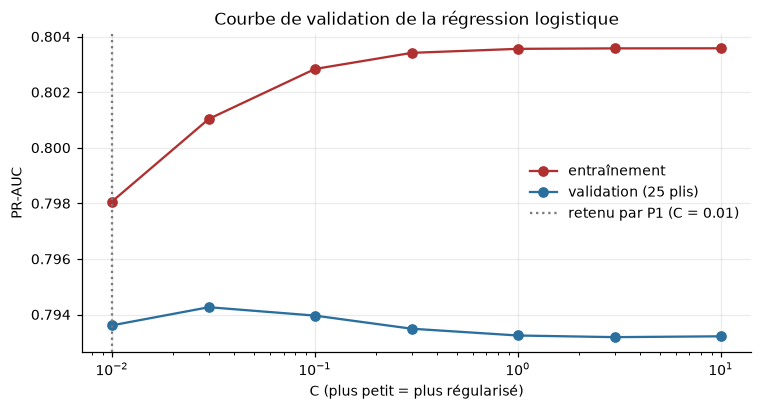

contrôle,mesure,seuil
S1 · écart entraînement − validation (max de la grille),0.0104,"≤ 0,05"
S3 · optimisme de la sélection (validation imbriquée),-0.0010,"≤ 0,01"
S4 · écart final de la courbe d'apprentissage,0.0051,"≤ 0,02"
S5 · erreur de calibration,0.0318,"< 0,05"


modèle,PR-AUC,gain apparié,seuil (1 écart-type),plis gagnés,gain significatif
régression logistique,0.7933,0.0000,0.0188,0,False
régression logistique réglée,0.7936,0.0003,0.0188,14,False


In [40]:
# --- Grid of the retained regression, overfitting checks S1 to S5 -------------------------------------
from churn_saas.features import tracer_courbe_validation

reglage_8, ressources_8 = _outil("reglage_modele").executer()
afficher_tableau(pd.DataFrame(reglage_8["grille"]).round(4),
                 titre="Grille de la régression logistique (25 plis) — PR-AUC d'entraînement et de validation")
tracer_courbe_validation(pd.DataFrame(reglage_8["courbe_validation_C"]), reglage_8["reglage_retenu"]["C"])
plt.show()
_s = reglage_8["surapprentissage"]
afficher_tableau(pd.DataFrame([
    ["S1 · écart entraînement − validation (max de la grille)", round(_s["S1_ecart_max_grille"], 4), "≤ 0,05"],
    ["S3 · optimisme de la sélection (validation imbriquée)", round(_s["S3"]["optimisme"], 4), "≤ 0,01"],
    ["S4 · écart final de la courbe d'apprentissage", round(_s["S4_ecart_final"], 4), "≤ 0,02"],
    ["S5 · erreur de calibration", round(_s["S5_erreur_calibration"], 4), "< 0,05"],
], columns=["contrôle", "mesure", "seuil"]), titre="Surveillance du surapprentissage")
afficher_tableau(pd.DataFrame(reglage_8["P2_comparaison"]), titre="P2 — le réglage remplace-t-il le champion ?")

**Lecture.** La grille est **plate** : moins de 0,002 entre toutes les combinaisons, pour un écart-type de 0,019.
P1 désigne la plus régularisée des combinaisons équivalentes (`C` = 0,01), mais P2 ne remplace le champion que par
un gain significatif : +0,0003, le **champion reste** (`C` = 1, pondération équilibrée). **Aucun signe de
surapprentissage** : les courbes d'entraînement et de validation restent à moins de 0,011 l'une de l'autre, et la
validation imbriquée ne trouve aucun optimisme dû à la sélection (−0,001).

In [41]:
# --- P4: resources of the three tuned models, and the served model ----------------------------------
afficher_tableau(pd.DataFrame(ressources_8["mesures"]), titre="Ressources (poste de développement)")
afficher_tableau(pd.DataFrame(_servi["mesures"]).T.reset_index(names="variante"),
                 titre="Champion évalué contre modèle servi (cette machine)")
afficher_tableau(pd.Series(_servi["equivalence"]).to_frame("valeur").reset_index(names="critère"),
                 titre="Équivalence du modèle servi (décision c ; jeu de test non relu, décision i)")
afficher_tableau(pd.Series(_servi["hyperparametres"]).astype(str).to_frame("valeur").reset_index(names="paramètre"),
                 titre="Paramètres retenus du modèle servi")

modèle,entraînement (s),lot de 5 000 comptes (s),un compte (ms),taille (Ko),mémoire de pointe à l'entraînement (Mo),énergie d'un entraînement (Wh),PR-AUC (25 plis),famille
régression logistique (calibrée),0.483,0.080,36.32,27.2,2.9,0.00335,0.7936,regression_logistique
forêt aléatoire réglée,0.473,0.076,17.73,2682.1,2.8,0.00329,0.7738,foret_aleatoire
xgboost réglé,0.122,0.021,6.42,231.4,2.6,0.00085,0.7803,xgboost


variante,PR-AUC (25 plis),erreur de calibration (25 plis),un compte (ms),lot de 5 000 comptes (s)
champion évalué (5 copies calibrées),0.7934,0.0298,73.19,0.175
modèle servi (une copie calibrée),0.7933,0.0303,14.36,0.035


critère,valeur
gain apparié du modèle servi,-0.0001
seuil (1 écart-type),0.0189
équivalent en performance,True
corrélation de rang des probabilités,0.99987
écart moyen des probabilités,0.0024
écart maximal des probabilités,0.0274
comptes comparés,partie d'entraînement (le jeu de test n'est pas relu : décision i)
calibration conforme,True
budget d'un compte respecté,True
budget du lot respecté,True


paramètre,valeur
famille,régression logistique
C,1.0
class_weight,balanced
penalty,l2
solver,lbfgs
max_iter,2000
calibration,sigmoid
copies calibrées,1
plis de calibration,5
graine,42


**Lecture.** Appliquée à la lettre, P4 désignait XGBoost : sa moyenne (0,780) tombe dans l'écart-type de la
régression. Mais la comparaison appariée de B1 le montre moins bon sur 24 plis sur 25 : ce n'est pas une
équivalence. Le vrai enjeu de ressources était la **latence d'un compte** : 57 ms sur le poste, pour un budget de
50 ms, parce que le champion interroge cinq copies calibrées. **Décision c** : une seule copie calibrée, même PR-AUC
(écart apparié −0,0001), même calibration, mêmes classements (0,9999), cinq fois plus rapide. **Décision i** : le
jeu de test n'est pas relu ; le résultat publié reste celui du champion évalué, et l'équivalence est démontrée
ci-dessus.

**Journal de bord [C5] [C6] — phase 8 :**
- Décision : grille de 14 combinaisons pour la régression, règles fixées avant le calcul ; champion maintenu (P2).
- Décision du porteur (c, i) : servir une copie calibrée ; ne pas relire le test. Incohérence entre P4 (non
  appariée) et B1 (appariée) consignée (règle 9, registre E-711).
- Sobriété : tout le réglage, imbriqué compris, tient en environ deux minutes sur le poste ; l'énergie d'un
  entraînement se compte en millièmes de wattheure.

## 10. Implémentation et mise en exploitation (déploiement, exemple d'usage) — journal de bord [C6]

**Sérialisation.** Le pipeline complet (préprocessing + modèle) est sérialisé pour garantir la reproductibilité
du prétraitement en production (même transformation qu'à l'entraînement).

**Esquisse d'API de scoring.** Endpoint `POST /score-churn` recevant les features brutes d'un compte (mêmes
colonnes que `FEATURES`), appliquant le pipeline sérialisé, renvoyant `{proba_churn, decision, seuil_utilise}`.

**Exemple d'usage.** Scoring d'un compte individuel à partir de `churn_saas_echantillon.csv` pour valider le
pipeline de bout en bout hors notebook d'entraînement.

**Journal de bord [C6] :**
- Décision : exposer la probabilité brute ET la décision binaire (au seuil retenu), pour laisser au Customer
  Success la possibilité d'ajuster sa propre priorisation au-delà du simple seuil (ex. tri par proba décroissante).

**Chaîne d'intégration et de déploiement continus (CI/CD).**

| Étape | Déclencheur | Contenu | Blocage si échec |
|---|---|---|---|
| 1. Tests | Chaque *commit* | Tests unitaires des fonctions de nettoyage, contrôle du schéma d'entrée | Oui |
| 2. Validation données | Chaque exécution du pipeline | Colonnes attendues, types, taux de manquants, valeurs hors bornes | Oui |
| 3. Entraînement | Manuel ou planifié | Réentraînement, calcul des métriques sur jeu de validation | — |
| 4. Contrôle qualité modèle | Après entraînement | PR-AUC du candidat comparée au modèle en production | Oui — pas de promotion si dégradation |
| 5. Livraison | Contrôle qualité passé | Sérialisation, enregistrement dans le dépôt de modèles, incrément de version | — |
| 6. Déploiement | Validation humaine | Mise en service du modèle pour le scoring batch suivant | — |
| 7. Surveillance | Continue | Dérive et performance réelle (section 13) | Alerte |

L'étape 4 est le garde-fou essentiel : aucun modèle ne remplace le précédent sans avoir démontré qu'il fait
mieux sur le même jeu de validation. Le déploiement reste soumis à une validation humaine, cohérent avec le
refus de l'automatisation décisionnelle posé en section 4.

**Versioning.** Trois objets sont versionnés conjointement, car un modèle n'est reproductible que si les
trois sont connus :

| Objet | Moyen | Convention |
|---|---|---|
| Code | Git | Étiquette `vMAJEUR.MINEUR` par mise en production |
| Données d'entraînement | Instantané horodaté (ou DVC) | `churn_train_AAAAMMJJ.parquet` |
| Modèle sérialisé | Dépôt de modèles / fichier joblib | `churn_model_vX.Y_AAAAMMJJ.joblib` |

Chaque modèle mis en production est accompagné d'une fiche : version du code, instantané de données,
hyperparamètres, métriques de validation, date, responsable de la validation. Le retour arrière consiste à
redéployer la version précédente, conservée.

**Besoins d'intégration documentés.**

| Interface | Sens | Format | Fréquence | Responsable |
|---|---|---|---|---|
| Entrepôt de données → pipeline | Lecture | Table SQL / export Parquet | Mensuelle | Équipe Data |
| Pipeline → CRM | Écriture | `client_id`, `proba_churn`, `decision`, `date_scoring`, `version_modele` | Mensuelle | Équipe Data / Ops CRM |
| Pipeline → journal | Écriture | Historique des scores, pour le suivi de dérive | Mensuelle | Équipe Data |
| CRM → retour métier | Lecture | Action menée, issue réelle du compte | Continue | Équipe CSM |

Le dernier flux est le plus souvent oublié et le plus important : sans retour sur l'issue réelle des comptes,
la performance en production est inobservable et le suivi de la section 13 reste théorique.

**Journal de bord [C6] — complément :**
- Décision : versionner données et modèle conjointement au code. Motif : un modèle reproductible à partir du
  seul code est une illusion si le jeu d'entraînement a changé entre-temps.
- Décision : conditionner la promotion d'un modèle à une comparaison automatisée avec celui en production.
  Motif : un réentraînement peut dégrader la performance ; sans contrôle, la dégradation passe inaperçue.

### Mise en œuvre outillée de la chaîne

La chaîne décrite ci-dessus était une convention. Elle est désormais outillée, ce qui en
change la portée : une convention se contourne, un dispositif se constate.

| Élément de la chaîne | Convention initiale | Mise en œuvre |
|---|---|---|
| Traçabilité des entraînements | Fiche modèle en JSON à côté de l'artefact | **MLflow** — paramètres, métriques et artefact enregistrés par exécution |
| Registre et promotion | Nommage de fichiers, fiche manuelle | **MLflow Model Registry** — alias *staging* / *production*, rollback par redéploiement de la version précédente |
| Orchestration du lot mensuel | Script à lancer | **Prefect** — une tâche par étape, journal indiquant laquelle a cédé, reprise sans rejouer ce qui a abouti |
| Écriture des scores | Fichier exporté | **PostgreSQL via SQLAlchemy** — table `scores_churn` portant la **version du modèle** qui a produit chaque score |
| Exposition des indicateurs | Tableau à lire | **Prometheus** + **Grafana** — collecte périodique et restitution |
| Service de scoring | Esquisse imprimée | **FastAPI** conteneurisé, `/health`, `/ready`, `/score` |

**Pourquoi MLflow, après l'avoir écarté.** La convention de nommage fonctionne pour un
modèle et un opérateur. Elle ne survit ni à plusieurs réentraînements, ni à plusieurs
personnes : rien n'empêche d'écraser un artefact, ni de perdre le lien entre un score et
le modèle qui l'a produit. MLflow outille la convention sans la changer — mêmes objets,
contrôle en plus. **La promotion reste un acte humain**, jamais automatique à la fin d'un
entraînement.

**Deux distinctions que le dispositif matérialise.**

`/health` répond que le processus est vivant ; `/ready` répond que le modèle est chargé.
Les confondre ferait basculer du trafic vers une instance incapable de servir. Le
`depends_on: condition: service_healthy` du compose applique le même principe entre l'API
et la base.

Le modèle n'est **pas embarqué dans l'image** : il est monté depuis un volume. L'image est
du code, le modèle est une donnée versionnée séparément. L'embarquer obligerait à
reconstruire l'image à chaque réentraînement, et confondrait deux cycles de vie distincts.

**Le contrôle qualité bloque le lot.** Dans le flux Prefect, l'étape de contrôle précède le
scoring et interrompt l'exécution si elle échoue. Scorer des données hors domaine produit
des probabilités plausibles mais fausses : c'est le pire cas, puisque rien ne le signale.


In [42]:
# The model and its card are written under models/ by tools/evaluation_finale.py (section 9.C),
# never by a relative path from this notebook.

# --- Esquisse de service de scoring (pseudo-code FastAPI, à adapter à l'environnement cible) ---
# Note : le service renvoie une probabilité et une valeur espérée, JAMAIS une décision binaire.
# La coupure relève du lot mensuel (section 9) : elle dépend de la capacité de traitement
# et du classement de l'ensemble du portefeuille, pas du compte pris isolément.
API_SKETCH = '''
from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
modele_churn, _ = charger_modele(MODELES / "churn_saas_v1.0_<date>.joblib")      # tools/evaluation_finale.py
modele_clv, _   = charger_modele(MODELES / "valeur_vie_client_v1.0_<date>.joblib")  # tools/modele_valeur_vie.py
U_RETENTION  = 0.25   # efficacité de rétention retenue (hypothèse, section 9)

@app.post("/score-churn")
def score_churn(payload: dict):
    X = preparer(pd.DataFrame([payload]))          # même chaîne qu'à l'entraînement
    proba = float(modele_churn.predict_proba(X[FEATURES])[:, 1][0])
    clv   = float(payload.get("valeur_vie_client_eur") or modele_clv.predict(X[FEATURES_CLV])[0])
    return {
        "proba_churn": proba,
        "valeur_vie_client_eur": clv,
        "valeur_esperee_eur": proba * clv * U_RETENTION,
        "version_modele": VERSION_MODELE,
    }
'''
print(API_SKETCH)

# --- Lot mensuel : c'est ici que la décision est prise ---
LOT_MENSUEL = '''
CAPACITE_MENSUELLE = 140   # hypothèse de cadrage (section 2), à confirmer avec le commanditaire

scores = scorer_portefeuille(df_comptes_echeance_proche)   # proba + CLV par compte
scores["valeur_esperee"] = scores["proba_churn"] * scores["clv"] * U_RETENTION
scores = scores.sort_values("valeur_esperee", ascending=False).reset_index(drop=True)
scores["rang"] = scores.index + 1
scores["a_traiter"] = scores["rang"] <= CAPACITE_MENSUELLE
'''
print(LOT_MENSUEL)

# End-to-end test on the provided sample: raw file -> shared preparation chain -> model in service.
# A functional check, not an evaluation: these 50 accounts were seen in training or belong to the test.
from churn_saas.donnees import typer_pour_modele
from churn_saas.industrialisation.scoring import preparer

_brut = pd.read_csv(config.FICHIER_ECHANTILLON, dtype=str, encoding="utf-8-sig")
_catalogue = pd.read_csv(config.FICHIER_CATALOGUE, dtype=str, encoding="utf-8-sig")
_entree = typer_pour_modele(preparer(_brut, catalogue=_catalogue).drop(columns=["churn"], errors="ignore"))
proba_ech = MODELE_FINAL.predict_proba(_entree)[:, 1]
print(f"{len(proba_ech)} comptes de l'échantillon scorés ; probabilités de "
      f"{proba_ech.min():.2f} à {proba_ech.max():.2f}, moyenne {proba_ech.mean():.2f}")



from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
modele_churn, _ = charger_modele(MODELES / "churn_saas_v1.0_<date>.joblib")      # tools/evaluation_finale.py
modele_clv, _   = charger_modele(MODELES / "valeur_vie_client_v1.0_<date>.joblib")  # tools/modele_valeur_vie.py
U_RETENTION  = 0.25   # efficacité de rétention retenue (hypothèse, section 9)

@app.post("/score-churn")
def score_churn(payload: dict):
    X = preparer(pd.DataFrame([payload]))          # même chaîne qu'à l'entraînement
    proba = float(modele_churn.predict_proba(X[FEATURES])[:, 1][0])
    clv   = float(payload.get("valeur_vie_client_eur") or modele_clv.predict(X[FEATURES_CLV])[0])
    return {
        "proba_churn": proba,
        "valeur_vie_client_eur": clv,
        "valeur_esperee_eur": proba * clv * U_RETENTION,
        "version_modele": VERSION_MODELE,
    }


CAPACITE_MENSUELLE = 140   # hypothèse de cadrage (section 2), à confirmer avec le commanditaire

scores = scorer_portefeuille

50 comptes de l'échantillon scorés ; probabilités de 0.01 à 1.00, moyenne 0.28


### 10.A Mise en exploitation réalisée (phase 10)

Le modèle servi porte une **carte d'identité** (empreintes du fichier et des données d'entraînement, contrat
d'entrée), il est **promu `champion`** avec un retour arrière en une commande, et ses scores sur l'échantillon se
reproduisent à 10⁻⁹. La liste remise aux conseillers parle métier :

In [43]:
# --- The operational list on the sample file, with control group (phase 10) ------------------------
from churn_saas.donnees import typer_pour_modele
from churn_saas.features import parties_du_decoupage
from churn_saas.industrialisation.liste import construire_liste
from churn_saas.industrialisation.scoring import preparer

catalogue = pd.read_csv(config.FICHIER_CATALOGUE, dtype=str, encoding="utf-8-sig")
parties = parties_du_decoupage(resultat)

_brut_ech = pd.read_csv(config.FICHIER_ECHANTILLON, dtype=str, encoding="utf-8-sig")
_X_ech = typer_pour_modele(preparer(_brut_ech, catalogue=catalogue).drop(columns=["churn"], errors="ignore"))
_liste = construire_liste(MODELE_FINAL, _X_ech, _brut_ech["client_id"].set_axis(_X_ech.index),
                          pd.to_numeric(_brut_ech["valeur_vie_client_eur"], errors="coerce").set_axis(_X_ech.index),
                          _X_ech["revenu_mensuel_recurrent_eur"], parties.X_entrainement, "churn_saas_servi 1.1",
                          capacite=5, genere_le="2026-10-01", graine=202610)
afficher_tableau(_liste.head(6), titre="Liste opérationnelle — extrait (échantillon)")

Priorité,Compte,Action recommandée,Risque de départ,Risque (%),Valeur client estimée (k€),Revenu mensuel (€),Gain attendu d'un contact (€),Pourquoi ce compte ?,Déjà contacté,Généré le,Modèle
1,CLI-000847,À contacter ce mois,Très élevé,92,173.3,6605.0,39706.0,Dernière connexion il y a 30 jours (augmente le risque) ; client depuis 1 mois (augmente le risque) ; aucune intégration active (augmente le risque),Nouveau,2026-10-01,churn_saas_servi 1.1
2,CLI-004120,À contacter ce mois,Modéré,32,233.8,5380.0,18589.0,6 ticket(s) de support en 3 mois (augmente le risque) ; 4 intégration(s) active(s) (réduit le risque) ; 2 retard(s) de paiement en 12 mois (augmente le risque),Nouveau,2026-10-01,churn_saas_servi 1.1
3,CLI-000228,À contacter ce mois,Faible,7,784.6,63786.0,13519.0,306 utilisateurs actifs (réduit le risque) ; formule enterprise (réduit le risque) ; revenu mensuel de 63 786 € (augmente le risque),Nouveau,2026-10-01,churn_saas_servi 1.1
4,CLI-003394,Groupe témoin (pas de contact),Élevé,43,124.7,4753.0,13346.0,3 retard(s) de paiement en 12 mois (augmente le risque) ; client depuis 1 mois (augmente le risque) ; aucune intégration active (augmente le risque),Nouveau,2026-10-01,churn_saas_servi 1.1
5,CLI-002189,À contacter ce mois,Très élevé,92,50.9,4438.0,11608.0,Dernière connexion il y a 49 jours (augmente le risque) ; aucune intégration active (augmente le risque) ; 0 % des licences utilisées (augmente le risque),Nouveau,2026-10-01,churn_saas_servi 1.1
6,CLI-000283,À contacter ce mois,Modéré,30,136.4,6932.0,10117.0,6 ticket(s) de support en 3 mois (augmente le risque) ; satisfaction 2 sur 5 (augmente le risque) ; 6 % des licences utilisées (augmente le risque),Nouveau,2026-10-01,churn_saas_servi 1.1


**Journal de bord [C6] — phase 10 :** carence de 2 mois et **groupe témoin de 10 %** (valeurs par défaut validées) ;
le groupe témoin est la seule façon de mesurer ce que le contact change vraiment (`tools/retours_terrain.py`).

## 11. Architecture cible et contraintes [C7]

**Architecture cible proposée : scoring batch mensuel.**
1. Extraction mensuelle des données d'usage/facturation/support (entrepôt de données de l'éditeur SaaS).
2. Pipeline de nettoyage + feature engineering (réutilisation du code de la section 7, packagé en module).
3. Scoring batch de l'ensemble des comptes actifs via le modèle sérialisé.
4. Écriture des scores dans le CRM (champ "score de risque churn") pour exploitation par les CSM.
5. Journalisation des scores (traçabilité, base pour le suivi de dérive — section 13).

**Contraintes.**
- Fraîcheur des données : usage/support agrégés sur fenêtres glissantes (30j/90j) → cohérence du calendrier de
  scoring avec la date d'échéance contractuelle des comptes.
- Volumétrie : ~5000 comptes actuellement, architecture batch largement suffisante (pas besoin de scoring
  temps réel à ce stade).
- Sécurité/RGPD : accès restreint aux données brutes, anonymisation pour tout usage hors production (ex. audit
  modèle).

**Journal de bord [C7] :**
- Décision : écarter le scoring temps réel (sur-ingénierie au regard du cas d'usage — la décision de rétention
  n'est pas instantanée, un rafraîchissement mensuel suffit).

**Chiffrage comparatif des scénarios d'architecture.**

Les montants ci-dessous sont des **ordres de grandeur assumés**, destinés à éclairer un arbitrage, non des
devis. Ils sont à confirmer auprès de l'équipe infrastructure. Hypothèse commune : environ 5 000 comptes
actifs, un scoring mensuel.

| Poste | Scénario A — batch mensuel *(retenu)* | Scénario B — service temps réel |
|---|---|---|
| Calcul | Tâche planifiée, quelques minutes par mois | Service disponible en permanence |
| Stockage | Volume négligeable | Idem + cache |
| Exposition | Aucune (écriture directe en base) | Passerelle d'API, authentification, supervision |
| Coût d'infrastructure mensuel | Quelques dizaines d'euros | Quelques centaines d'euros |
| Charge d'exploitation | Faible — une tâche planifiée | Élevée — astreinte, supervision de disponibilité |
| Effort de mise en œuvre | Faible | Élevé |
| Bénéfice métier supplémentaire | — | Aucun : la décision de rétention n'est pas instantanée |

Le scénario A est retenu. Le scénario B multiplie le coût récurrent et la charge d'exploitation sans
bénéfice métier identifiable : la fenêtre d'action du CSM se compte en semaines, pas en secondes. Ce
chiffrage est porté à la connaissance du commanditaire pour objectiver l'arbitrage — sans lui, le choix du
batch relèverait de la préférence technique.

**Acteurs interrogés sur les contraintes de généralisation.**

| Acteur | Question posée | Contrainte remontée |
|---|---|---|
| Commanditaire (Customer Success) | Quel délai d'action avant échéance ? | Fenêtre de plusieurs semaines → batch mensuel suffisant |
| Équipe infrastructure | Quelle capacité d'ordonnancement existante ? | Réutilisation de l'ordonnanceur en place, pas de nouvelle brique |
| Ops CRM | Quel champ peut recevoir le score ? | Champ personnalisé, écriture en masse, rythme mensuel |
| DPO | Quelle durée de conservation des scores ? | À arbitrer — historique nécessaire au suivi de dérive |
| Équipes CSM | Quel format est exploitable ? | Score et niveau de risque dans la fiche compte, sans outil tiers |

*(Le cas d'usage étant pédagogique, ces échanges sont reconstitués à partir des éléments de l'énoncé. Ils
sont présentés comme des hypothèses de contraintes, à confirmer en situation réelle.)*

**Journal de bord [C7] — complément :**
- Décision : chiffrer deux scénarios plutôt que d'affirmer la supériorité du batch. Motif : un arbitrage
  d'architecture non chiffré n'est pas un arbitrage, c'est une préférence.
- Décision : réutiliser l'ordonnanceur existant plutôt que d'introduire un orchestrateur dédié. Motif :
  une brique supplémentaire ajoute une charge d'exploitation sans gain à cette volumétrie.

### Architecture mise en œuvre

Cinq services, chacun rattaché à une compétence. L'ensemble démarre par `docker compose up`.

| Service | Image | Rôle | Port |
|---|---|---|---|
| `api` | construite depuis le `Dockerfile` | Service de scoring unitaire | 8000 |
| `db` | `postgres:16` | Entrepôt des scores et des exécutions | 5432 |
| `mlflow` | `ghcr.io/mlflow/mlflow:v3.1.1` | Suivi des expérimentations, registre de modèles | 5000 |
| `prometheus` | `prom/prometheus:v2.53.0` | Collecte des indicateurs | 9090 |
| `grafana` | `grafana/grafana:11.1.0` | Restitution des indicateurs | 3000 |

**Choix d'architecture à savoir défendre.**

*Images épinglées à une version exacte, jamais `latest`.* Deux constructions du même
commit doivent produire la même image. `latest` rend ce résultat dépendant de la date.

*Réseau interne par nom de service.* L'API joint la base par `db:5432`, Prometheus joint
l'API par `api:8000`. Aucune adresse IP, aucun `localhost` entre conteneurs — `localhost`
dans un conteneur désigne ce conteneur, pas l'hôte.

*Le port publié concerne l'hôte.* `8000:8000` redirige le port de la machine vers celui du
conteneur ; les conteneurs, eux, communiquent sur le port interne.

*Un volume dissocie les données du conteneur.* `pgdata` conserve la base même si le
conteneur est détruit et recréé. Les artefacts MLflow vivent dans `mlruns`, distinct : les
métadonnées sont relationnelles, les artefacts sont des fichiers — deux natures, deux
stockages, conformément au § 3.

*Utilisateur non privilégié et image mince.* Le `Dockerfile` construit en deux étapes :
les outils d'installation restent dans l'étape jetable, l'image finale tourne sous
`appuser` et ne contient ni `pip` ni `setuptools`. Une compromission du service n'hérite
pas de root.

*Les secrets viennent d'un fichier `.env` non versionné*, et `gitleaks` s'exécute avant
chaque commit. Un secret committé reste dans l'historique même après suppression du
fichier : le seul contrôle efficace est celui qui l'empêche d'y entrer.

**Révision du chiffrage.** Les deux scénarios comparés plus haut restent valables pour le
seul service de scoring. La plateforme complète — base, registre, collecte, restitution —
ajoute un coût récurrent qui n'était pas dans le scénario A initial. Cet écart est assumé :
il achète la traçabilité exigée par C6 et C9, qu'un scoring batch nu ne fournit pas.


In [44]:
# Section 11 - architecture diagram (to illustrate, e.g. diagram, outside executable code)


## 12. Mesure de performance et impacts (métriques techniques + métier) — journal de bord [C8]

**Réécrit en phase 9 (règles R6 à R12, consignées avant tout calcul).** Le jeu de test a été lu **une seule fois**
pour cette restitution (`tools/restitution_test.py`, motif « rapport de validation phase 9, aucune décision »),
avec le champion évalué (décision i). Les scores des 1 000 comptes sont enregistrés : toutes les analyses ci-dessous
les relisent, sans jamais relire le test (`tools/validation_phase9.py`).

### 12.A Métriques globales, écart validation croisée / test, calibration (R7)

métrique,valeur,intervalle à 95 %
PR-AUC,0.7612,[0.710 ; 0.807]
ROC-AUC,0.8815,[0.859 ; 0.903]
erreur de calibration,0.0364,[0.027 ; 0.062]


repère,valeur
"PR-AUC validation croisée (25 plis, champion calibré)",0.7934
PR-AUC validation croisée imbriquée,0.7931
PR-AUC test,0.7612
écart,0.0322
validation croisée dans l'intervalle du test,True


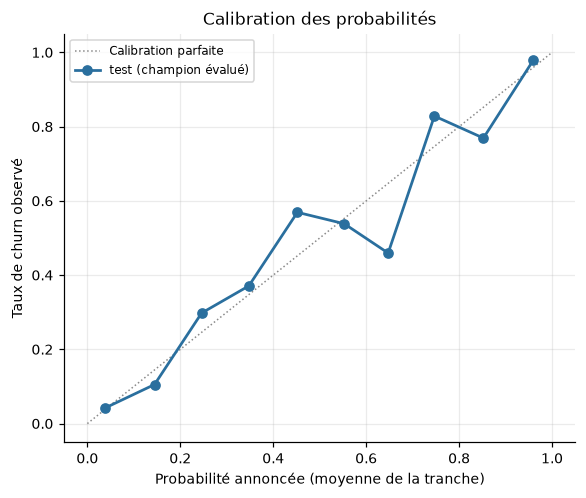

In [45]:
# --- R7: global metrics with intervals, gap with cross-validation, calibration -----------------------
from churn_saas.features import tracer_calibration

validation_9 = _outil("validation_phase9").executer()
afficher_tableau(pd.DataFrame({m: {"valeur": v["valeur"], "intervalle à 95 %": f"[{v['intervalle_95'][0]:.3f} ; {v['intervalle_95'][1]:.3f}]"}
                               for m, v in validation_9["metriques"].items()}).T.reset_index(names="métrique"),
                 titre="Jeu de test — 1 000 comptes")
afficher_tableau(pd.Series(validation_9["ecart_validation_croisee_test"]).astype(str).to_frame("valeur")
                 .reset_index(names="repère"), titre="Validation croisée contre test")
_scores_test = pd.read_csv(RACINE / "resultats" / "scores_test.csv", dtype={"client_id": str})
tracer_calibration({"test (champion évalué)": (_scores_test["churn"], _scores_test["proba"])})
plt.show()

**Lecture.** PR-AUC **0,761** [0,710 ; 0,807] sur le test, contre 0,793 en validation croisée (0,793 aussi en
validation imbriquée) : l'écart de 0,032 reste **dans l'intervalle du test** — le modèle généralise comme prévu.
L'erreur de calibration (0,036) reste sous l'objectif de 0,05 : les probabilités sont utilisables telles quelles
dans la valeur espérée.

### 12.B Matrices de confusion aux deux points de fonctionnement (R5)

In [46]:
# --- R5: the business point (28 accounts by net value) and the protocol point (top 10 %) -------------
afficher_tableau(pd.DataFrame(validation_9["matrices"]).T.reset_index(names="point de fonctionnement"),
                 titre="Matrices de confusion — jeu de test")

point de fonctionnement,vrais positifs,faux positifs,faux négatifs,vrais négatifs,précision,rappel,comptes signalés
"métier (28 comptes, valeur nette)",18.0,10.0,262.0,710.0,0.6429,0.0643,28.0
protocole (10 % les plus risqués),88.0,12.0,192.0,708.0,0.8800,0.3143,100.0


**Lecture.** Au **point métier**, l'équipe contacte 28 comptes (la capacité mensuelle ramenée au test) : **18
partent réellement** (précision 0,64). Le rappel est faible (6 %) **par construction** : 280 comptes partent, et la
capacité n'en permet que 28. Au **point protocole** (100 comptes), la précision est de 0,88 et le rappel de 0,31. Le
point métier vise les comptes de **forte valeur**, pas seulement les plus probables : d'où une précision plus basse,
mais un revenu couvert bien plus élevé (12.C).

### 12.C Revenu récurrent exposé, couvert, préservé (R8)

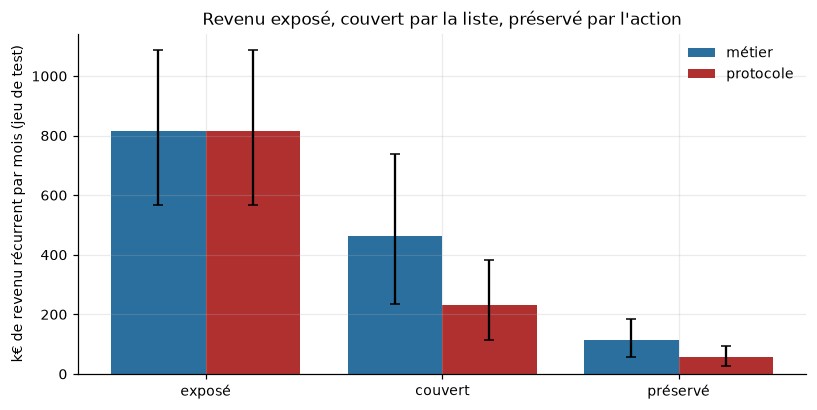

point,exposé,couvert,préservé,part couverte,"préservé, extrapolé au portefeuille (€/mois)"
métier,814442.0,462833.0,115708.0,0.5683,578541.0
protocole,814442.0,231428.0,57857.0,0.2842,289285.0


In [47]:
# --- R8: monthly recurring revenue, in euros, with intervals ----------------------------------------
from churn_saas.features import tracer_niveaux_mrr

tracer_niveaux_mrr(validation_9["mrr"])
plt.show()
afficher_tableau(pd.DataFrame({p: {n: validation_9["mrr"][p][n]["€ par mois (test)"] for n in ("exposé", "couvert", "préservé")}
                               | {"part couverte": validation_9["mrr"][p]["part couverte"],
                                  "préservé, extrapolé au portefeuille (€/mois)": validation_9["mrr"][p]["préservé"]["€ par mois (extrapolé au portefeuille)"]}
                               for p in ("métier", "protocole")}).T.reset_index(names="point"),
                 titre="Revenu récurrent mensuel (€) — " + validation_9["mrr"]["extrapolation"])

**Lecture.** Sur le jeu de test, **814 k€ de revenu mensuel** partent avec les clients perdus (exposé). La liste
de 28 comptes en **couvre 57 %** (463 k€, intervalle 233 k€ à 740 k€) — deux fois plus que les 100 comptes du point
protocole (28 %), parce qu'elle vise la valeur. Avec une efficacité de rétention de 25 %, environ **116 k€ par mois**
seraient **préservés** sur cet échantillon. Rapportés au portefeuille, ces chiffres donnent un ordre de grandeur, pas
une mesure : ils reposent sur l'hypothèse d'efficacité, la plus fragile du projet.

### 12.D Équité par segment (R9)

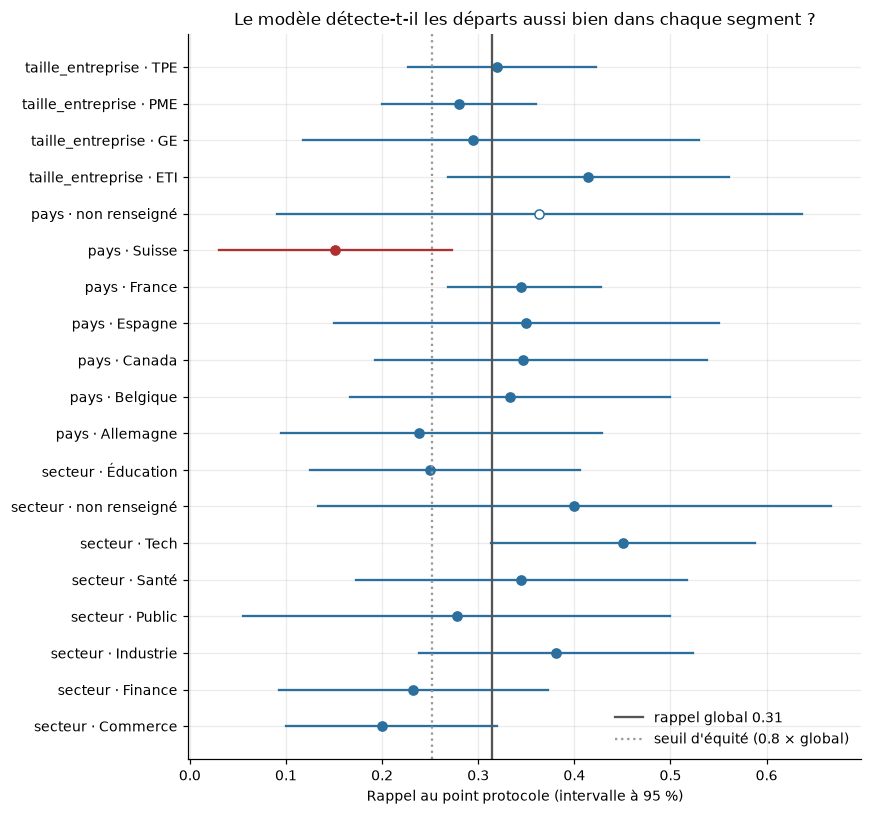

segment,modalité,comptes,départs,taux de départ,signalés,rappel,précision,concluant,critère respecté
secteur,Commerce,162,50,0.3086,13,0.2000,0.7692,True,True
secteur,Finance,170,43,0.2529,11,0.2326,0.9091,True,True
secteur,Industrie,150,42,0.2800,18,0.3810,0.8889,True,True
secteur,Public,59,18,0.3051,5,0.2778,1.0000,True,True
secteur,Santé,123,29,0.2358,11,0.3448,0.9091,True,True
secteur,Tech,168,51,0.3036,23,0.4510,1.0000,True,True
secteur,non renseigné,54,15,0.2778,9,0.4000,0.6667,True,True
secteur,Éducation,114,32,0.2807,10,0.2500,0.8000,True,True
pays,Allemagne,93,21,0.2258,7,0.2381,0.7143,True,True
pays,Belgique,95,24,0.2526,11,0.3333,0.7273,True,True


Segments concluants hors critère : ['pays = Suisse']


In [48]:
# --- R9: recall by sector, country and company size at the protocol point --------------------------
from churn_saas.features import tracer_equite

_rappel_global = validation_9["matrices"]["protocole (10 % les plus risqués)"]["rappel"]
tracer_equite(validation_9["equite"], _rappel_global, config.RATIO_EQUITE)
plt.show()
afficher_tableau(pd.DataFrame(validation_9["equite"]).drop(columns=["intervalle du rappel"]),
                 titre="Rappel et précision par segment (point protocole)")
print("Segments concluants hors critère :", validation_9["equite_synthese"]["segments concluants hors critère"])

**Lecture.** Sur 18 segments concluants, **un seul sort du critère : la Suisse** — rappel 0,15 [0,03 ; 0,27],
alors que son taux de départ est le plus élevé (40 %). Le modèle y détecte donc moins bien les départs. Deux réserves
avant d'en conclure : avec 18 comparaisons au seuil de 95 %, **une alerte fortuite est attendue** ; et le pays a été
retiré du modèle en phase 5 (sous le plancher des leurres), si bien qu'un facteur propre à la Suisse peut lui échapper.
Conformément à R12, l'écart est **documenté, pas corrigé sur le test** : il sera **surveillé** en phase 11 et vérifié
sur les prochains lots mensuels avant toute modification du modèle.

### 12.E Importance des variables sur le jeu de test (R10)

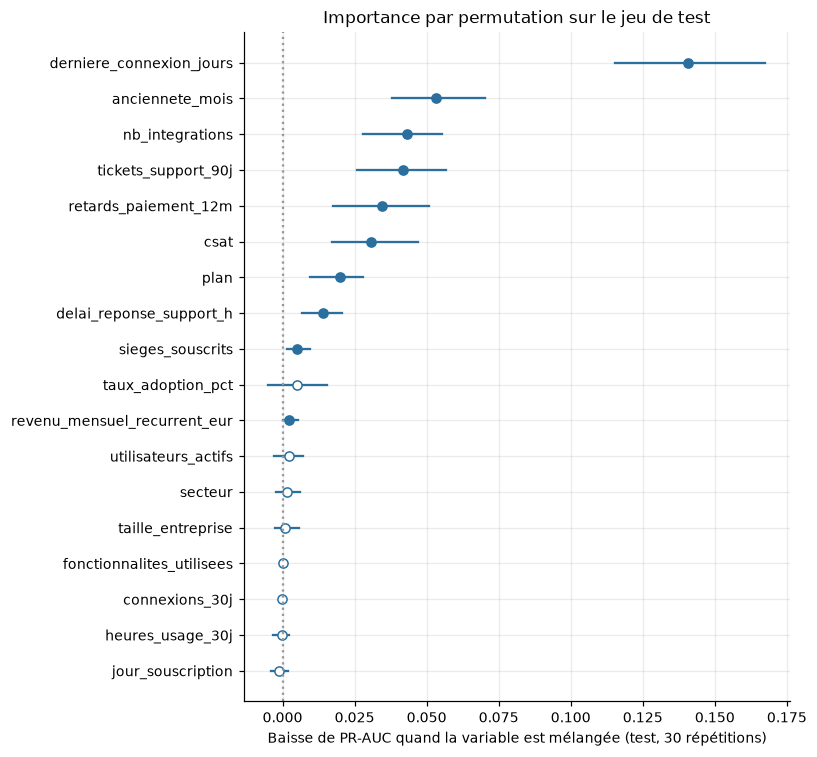

In [49]:
# --- R10: permutation importance on the test part, recorded during the reporting read --------------
from churn_saas.features import tracer_importance_test

_restitution = json.loads((RACINE / "resultats" / "restitution_test.json").read_text(encoding="utf-8"))
tracer_importance_test(_restitution["importance_permutation"])
plt.show()

**Lecture.** La dernière connexion, l'ancienneté, les intégrations et les tickets de support portent l'essentiel
de la performance sur le test. Huit variables n'ont **pas d'apport démontré isolément** (intervalle touchant zéro) :
ce sont surtout les **variables d'usage**, fortement corrélées entre elles — mélanger l'une laisse l'information aux
autres. L'ablation de la phase 5 avait montré que l'usage compte **en tant que famille**. Aucun changement de modèle
n'en découle (R12).

### 12.F Explication d'un score, compte par compte (R11)

In [50]:
# --- R11: exact contributions of three accounts, on the log-odds scale ------------------------------
for role, explication in _restitution["explications_locales"].items():
    print(f"\n{role} — compte {explication['client_id']} : probabilité {explication['probabilite']:.2f}, "
          f"départ réel : {'oui' if explication['depart_reel'] else 'non'} (base {explication['base_cotes']:+.2f} en cotes)")
    afficher_tableau(pd.DataFrame({"valeur du compte": explication["valeurs"],
                                   "contribution (cotes)": explication["contributions_cotes"]}).reset_index(names="variable"),
                     titre=role)


plus forte valeur espérée — compte CLI-004433 : probabilité 0.83, départ réel : oui (base -0.68 en cotes)


variable,valeur du compte,contribution (cotes)
derniere_connexion_jours,45.0,1.9740
plan,Enterprise,-0.7681
nb_integrations,0.0,0.6697
taux_adoption_pct,0.0,0.6253
tickets_support_90j,0.0,-0.5859
anciennete_mois,6.0,0.4513



à la limite de la liste — compte CLI-001795 : probabilité 0.41, départ réel : oui (base -0.68 en cotes)


variable,valeur du compte,contribution (cotes)
csat,2.0,0.6823
nb_integrations,0.0,0.6697
tickets_support_90j,5.0,0.5753
derniere_connexion_jours,1.0,-0.3508
retards_paiement_12m,nan,-0.2908
anciennete_mois,8.0,0.2633



faux positif traité — compte CLI-000778 : probabilité 0.62, départ réel : non (base -0.68 en cotes)


variable,valeur du compte,contribution (cotes)
plan,Enterprise,-0.7681
anciennete_mois,3.0,0.7333
csat,2.0,0.6823
nb_integrations,0.0,0.6697
utilisateurs_actifs,219.0,-0.6110
revenu_mensuel_recurrent_eur,44906.77,0.4968


**Lecture.** Pour chaque compte, la base (le score moyen, en cotes logarithmiques) plus la somme des contributions
redonne exactement son score : le conseiller sait **pourquoi** ce compte est dans sa liste. Le faux positif montre la
limite : un compte peut présenter tous les signaux d'un départ (connexion ancienne, peu d'intégrations) sans partir —
une contribution explique un score, elle ne prédit pas l'issue avec certitude.

**Journal de bord [C8] — phase 9 :**
- Décision : règles R1 à R12 consignées avant tout calcul ; une seule lecture de restitution du test, scores
  enregistrés, aucune décision après lecture.
- Constat : la capacité, pas la rentabilité, limite l'action ; la liste traitée résiste à l'incertitude du modèle.
- Constat : 57 % du revenu exposé couvert avec 28 comptes ; un écart d'équité (Suisse) documenté et mis sous
  surveillance.

## 13. Amélioration continue (ré-entraînement, suivi, versioning) [C9]

**Dérive à surveiller.**
- Dérive des données (*data drift*) : distribution des variables d'usage évolue (ex. nouvelle fonctionnalité
  produit change `heures_usage_30j`).
- Dérive du concept (*concept drift*) : la relation usage → churn change (ex. nouvelle offre concurrente).

**Plan de ré-entraînement.** Ré-entraînement périodique (ex. trimestriel) ou déclenché par un seuil de dégradation
de l'AUC/PR-AUC observé sur les scores en production comparés aux churns réels constatés a posteriori.

**Monitoring proposé.**
- Suivi mensuel de la distribution des features clés vs distribution d'entraînement (ex. test de Kolmogorov-Smirnov
  ou PSI - Population Stability Index).
- Suivi de la performance réelle (AUC/PR-AUC) une fois les churns réels connus (délai d'observation = durée d'un
  cycle contractuel).

**Versioning.** Versionner le pipeline (code + hyperparamètres) et les données d'entraînement (ex. DVC ou simple
convention de nommage horodatée) pour garantir la traçabilité et le rollback en cas de régression.

**Journal de bord [C9] :**
- Décision : fixer une fréquence de ré-entraînement trimestrielle par défaut, ajustable si un monitoring de dérive
  déclenche une alerte avant cette échéance.

**Évaluation automatisée intégrée à la chaîne CI/CD.**

Le suivi décrit ci-dessus n'a de valeur que s'il est exécuté sans intervention humaine. Le dispositif
s'appuie sur la chaîne décrite en section 10 :

| Moment | Contrôle automatisé | Conséquence |
|---|---|---|
| Avant chaque scoring | Validation du schéma et de la qualité des données d'entrée | Blocage et alerte si échec |
| Après chaque scoring | Calcul du PSI vs distribution d'entraînement, journalisation | Alerte si dépassement de seuil |
| Après chaque réentraînement | Comparaison du candidat au modèle en production sur jeu de validation figé | Pas de promotion si dégradation |
| Mensuellement | Recalcul des métriques réelles dès que les issues sont connues | Alerte si dégradation |
| Trimestriellement | Revue de la pertinence des indicateurs et des seuils eux-mêmes | Ajustement documenté |

**Métriques intégrées au dispositif de suivi.**

| Catégorie | Métriques |
|---|---|
| Qualité de prévision | PR-AUC, AUC, rappel et précision au seuil retenu |
| Robustesse | Écart-type des scores en validation croisée, stabilité entre réentraînements |
| Variation de performance | Écart à la référence établie à la mise en production |
| Obsolescence | PSI par variable, ancienneté du modèle, ancienneté des données d'entraînement |
| Exploitation | Taux d'échec du pipeline, durée d'exécution, complétude des données d'entrée |

**Périodicité de révision des indicateurs.** Définie en phase de cadrage (section 2) : revue trimestrielle
des indicateurs et de leurs seuils, alignée sur le cycle de réentraînement. Cette revue ne porte pas sur la
performance du modèle mais sur **la pertinence des indicateurs eux-mêmes** — un seuil de PSI calibré à la
mise en service peut devenir inadapté après une évolution produit.

**Journal de bord [C9] — complément :**
- Décision : interdire la promotion automatique d'un modèle réentraîné. Motif : l'automatisation porte sur
  l'évaluation, pas sur la décision de mise en production — cohérent avec la supervision humaine posée en
  section 4.
- Décision : intégrer l'obsolescence des données d'entraînement comme métrique à part entière. Motif : un
  modèle peut rester performant sur des données anciennes tout en étant devenu inadapté au terrain.

### Boucle de rétroaction : monitoring → données

Le déclenchement d'une alerte ne conduit pas directement au réentraînement : il impose d'abord un retour à
l'étape **Données** du cycle de vie. Réentraîner sur un jeu de données dont la dérive n'a pas été comprise
reviendrait à apprendre le problème plutôt qu'à le corriger.

| Étape du retour | Contenu | Responsable |
|---|---|---|
| 1. Qualification de l'alerte | Dérive réelle, incident de collecte, ou évolution produit légitime ? | Équipe Data |
| 2. Nouvel instantané | Extraction fraîche, versionnée et figée selon la convention de la section 10 | Équipe Data |
| 3. Contrôle du schéma | Colonnes, types, domaines de valeurs, taux de manquants comparés aux références de la section 5 | Automatisé |
| 4. Comparaison des distributions | Nouvel instantané vs instantané d'entraînement en vigueur, variable par variable | Équipe Data |
| 5. Révision des features | Une variable dont la définition a changé côté produit doit être reconstruite, non réapprise | Équipe Data |
| 6. Mise à jour de la référence de dérive | La distribution de référence du PSI devient celle du nouvel instantané | Équipe Data |
| 7. Réentraînement | Uniquement après les étapes 1 à 6 | Équipe Data |

**Le point le plus souvent manqué est l'étape 6.** Si la distribution de référence servant au calcul du PSI
n'est pas mise à jour lors du réentraînement, le système continue de comparer les données courantes à un
état ancien : il signale indéfiniment une dérive déjà absorbée, ou cesse d'en détecter de nouvelles. La
référence de dérive est un artefact versionné au même titre que le modèle.

**Cas particulier — évolution produit.** Une modification fonctionnelle de la plateforme (nouveau plan,
refonte d'une fonctionnalité) produit une dérive légitime qui ne relève pas d'un défaut du modèle. Elle
impose néanmoins un réentraînement, car les variables d'usage changent de signification. Ce cas justifie que
l'équipe produit soit destinataire des alertes de dérive, au même titre que l'équipe Data.

**Journal de bord [C9] — complément :**
- Décision : interposer une étape de qualification entre l'alerte et le réentraînement. Motif : un incident
  de collecte et une dérive réelle produisent la même alerte mais appellent des réponses opposées —
  correction du pipeline dans un cas, réapprentissage dans l'autre.
- Décision : versionner la distribution de référence du PSI comme un artefact à part entière. Motif : sans
  mise à jour, le dispositif de détection de dérive devient inopérant après le premier réentraînement.

### Mise en œuvre de la surveillance

Les indicateurs du § 12 sont publiés par un exporteur Prometheus (`monitoring/exporteur.py`)
et collectés toutes les 30 secondes. Grafana est provisionné au démarrage : sa source de
données est configurée par fichier, sans intervention manuelle — le tableau de bord est
donc reproductible.

| Indicateur exposé | Nature | Origine |
|---|---|---|
| `churn_comptes_scores` | volumétrie | lot mensuel |
| `churn_comptes_a_traiter` | volumétrie | lot mensuel |
| `churn_valeur_esperee_totale_eur` | métier | lot mensuel |
| `churn_psi_max` | dérive | calcul de dérive |
| `churn_pr_auc` | technique | dernière évaluation |
| `churn_taux_manquants_max` | qualité | contrôle d'entrée |
| `churn_psi_score` | dérive | verdict mensuel M5 (phase 11) |
| `churn_variables_psi_au_dessus_de_0_10` | dérive | verdict mensuel M5 (phase 11) |
| `churn_variables_manquants_en_alerte` | qualité | verdict mensuel M8 (phase 11) |
| `churn_comptes_signales` | volumétrie | verdict mensuel M9 (phase 11) |
| `churn_alerte{indicateur}` | alerte | une jauge 0/1 par règle (phase 11) |
| latence, codes de retour | technique | instrumentation de l'API |

**Une séparation de responsabilité à souligner.** L'exporteur **expose**, il ne décide pas.
Les seuils, les actions associées et les responsables nommés restent dans
`monitoring/alertes.py`, en Python testé. Coder un seuil dans la configuration Prometheus
le rendrait invisible depuis le code et difficile à tester ; le laisser dans le code le
rend vérifiable par la suite de tests et lisible par le jury.


### Mise en œuvre de la phase 11 (04/10/2026)

Les règles du suivi — seuils, variables clés, rythme et données de réentraînement (M1 à M10) — et les données de
démonstration (S1 à S8) ont été validées par le porteur et committées **avant tout calcul**
(`docs/00.README_choix_methodologiques.md`, § 7 nonies). Une alerte **avertit** et se qualifie ; elle ne bloque
jamais le scoring (M6) — le blocage reste réservé au contrat de données, quand un lot est inutilisable.

Aucun lot de production n'existe et le jeu de test ne se relit pas : le suivi est démontré sur **trois lots
simulés** à partir de la partie d'entraînement, marqués comme tels. Ils prouvent la **mécanique** — calculs,
alertes, actions, décision de réentraîner —, jamais la performance du modèle (S6). Le détail, figures comprises,
est dans le carnet de travail `notebooks/11_suivi.ipynb`.

**Journal de bord [C9] — phase 11 :**
- Décision : comparer chaque lot à un **profil de référence** versionné avec le modèle
  (`resultats/profil_reference.json`) plutôt qu'aux lignes d'entraînement. Motif : aucune donnée de compte ne part
  en production, et un nouveau champion sans nouveau profil fait échouer un test.
- Constat : un désengagement modeste reste sous les seuils de dérive, et le score bouge peu même en dérive forte ;
  un groupe témoin de 10 % ne suffit pas à prouver l'effet des contacts en un trimestre (cellules ci-dessous).


In [51]:
# Section 13 - phase 11: the validated monitoring rules (M1 to M10), read from the code
from churn_saas.monitoring import table_regles

afficher_tableau(table_regles(), titre="Règles d'alerte du suivi (M1 à M10)")

indicateur,nature,seuil,action,responsable
PR-AUC en production,technique,baisse > 15 % vs référence,diagnostic puis réentraînement,Équipe Data
Couverture du revenu à risque,métier,< 50 % du MRR des comptes partis,révision de la capacité ou du modèle,Équipe Data + CSM
Dérive des entrées et du score (PSI),dérive,"> 0,25 sur une variable clé, ou > 0,10 sur trois variables, ou > 0,10 sur le score",qualification de l'alerte puis retour aux données,Équipe Data
Volume de comptes signalés,volumétrie,écart > 30 % vs mois précédent,contrôle qualité des données d'entrée,Équipe Data
Taux de manquants à l'entrée,qualité,"> 2 × le taux d'entraînement, sur une variable","avertissement, scoring maintenu ; qualification de la collecte",Équipe Data
Rappel sur le segment Suisse,équité,"< 0,8 × rappel global, intervalle excluant le rappel global (critère R9)","revue du segment avec les CSM, sans correction automatique",Équipe Data + CSM
Rétention des comptes traités,métier,non significative vs témoin,remise en cause de l'utilité de l'outil,Commanditaire
Retours de faux positifs CSM,métier,volume anormal,révision du point de fonctionnement,CSM + Équipe Data


**Suivi mensuel sur lots simulés.** Mois 1 sans dérive (témoin), mois 2 avec un désengagement modeste et un
champ qui n'arrive plus, mois 3 avec un désengagement marqué. Chaque lot passe par la chaîne de production — préparation,
modèle servi, liste — puis par les règles M5 (dérive), M8 (manquants) et M9 (comptes signalés).

SIMULÉ — démonstration — mécanique du suivi démontrée ; aucune conclusion sur la performance (S6)


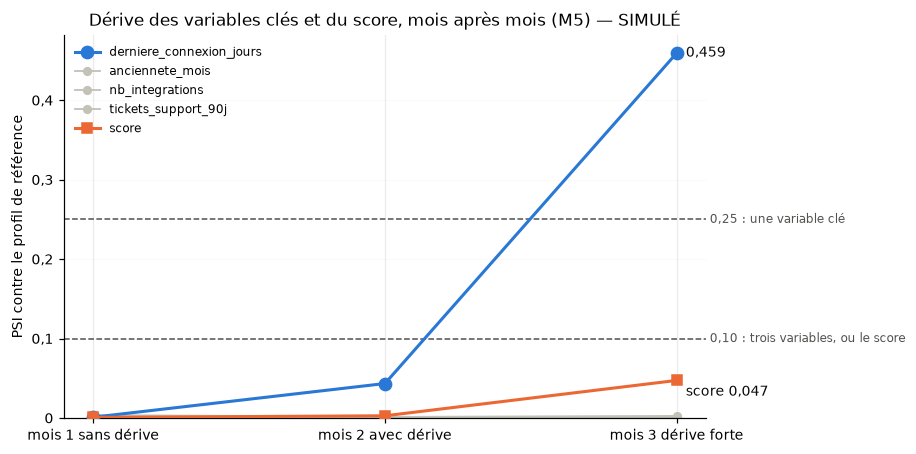

mois,PSI dernière connexion,PSI du score,M5 dérive,M8 manquants,M9 comptes signalés
mois_1_sans_derive,0.0010,0.0007,False,—,156
mois_2_avec_derive,0.0434,0.0028,False,delai_reponse_support_h,156
mois_3_derive_forte,0.4593,0.0473,True,—,156


In [52]:
import json

from churn_saas.features import tracer_evolution_psi
from churn_saas.monitoring import alertes as regles_suivi

suivi_simule = json.loads((RACINE / "resultats" / "suivi_simule.json").read_text(encoding="utf-8"))
profil_reference = json.loads((RACINE / "resultats" / "profil_reference.json").read_text(encoding="utf-8"))
print(suivi_simule["mention"], "—", suivi_simule["portee"])
tracer_evolution_psi(suivi_simule["mois"], profil_reference["variables_cles"], "derniere_connexion_jours",
                     (regles_suivi.SEUIL_PSI_MODERE, regles_suivi.SEUIL_PSI_VARIABLE_CLE))
plt.show()
afficher_tableau(pd.DataFrame([{
    "mois": m["mois"],
    "PSI dernière connexion": m["M5_derive"]["psi"]["derniere_connexion_jours"],
    "PSI du score": m["M5_derive"]["verdict"]["psi du score"],
    "M5 dérive": m["M5_derive"]["verdict"]["déclenchée"],
    "M8 manquants": ", ".join(m["M8_manquants"]["verdict"]["variables en alerte"]) or "—",
    "M9 comptes signalés": m["M9_volume"]["comptes signalés"],
} for m in suivi_simule["mois"]]), titre="Verdicts mensuels — SIMULÉ")

**Revue trimestrielle et réentraînement.** Trois mois après chaque liste, l'issue de chaque compte est tirée selon
la probabilité du modèle, réduite de 25 % pour les comptes contactés (S5) : juste par construction, elle exerce la
revue sans rien mesurer du modèle. La décision de réentraîner applique M2 à M4 ; la qualification des alertes,
décision humaine, est simulée à partir du scénario connu.

In [53]:
revue = suivi_simule["revue_trimestrielle"]
retention = revue["retention_contre_temoin"]
afficher_tableau(pd.DataFrame([
    ("M1 · couverture du revenu à risque", f"{revue['M1_couverture']['part couverte']:.1%}", revue["M1_couverture"]["déclenchée"]),
    ("M7 · rappel, segment Suisse", f"{revue['M7_suisse']['rappel']:.3f} (global {revue['M7_suisse']['rappel global']:.3f})",
     revue["M7_suisse"]["déclenchée"]),
    ("Efficacité contre témoin", f"{retention['efficacité mesurée']:.1%} sur {retention['comptes témoins']} témoins, "
     f"intervalle [{retention['intervalle 95 %'][0]:.0%} ; {retention['intervalle 95 %'][1]:.0%}]", retention["déclenchée"]),
    ("PR-AUC sur les non contactés", f"{revue['pr_auc_en_production']['PR-AUC']:.3f}", revue["pr_auc_en_production"]["déclenchée"]),
], columns=["Indicateur", "Mesure (SIMULÉE)", "Alerte"]), titre="Revue trimestrielle — SIMULÉ")
afficher_tableau(pd.DataFrame([{
    "mois": d["mois"],
    "réentraîner": d["réentraîner"],
    "motifs": "; ".join(d["motifs"]) or "—",
    "retour aux données": ", ".join(d["retour aux données (incidents de collecte)"]) or "—",
} for d in suivi_simule["reentrainement"]["decisions"]]), titre="Décision de réentraînement (M3) — SIMULÉ")
print("Données de réentraînement (M2, M4) :", suivi_simule["reentrainement"]["selection"])

Indicateur,Mesure (SIMULÉE),Alerte
M1 · couverture du revenu à risque,49.9%,True
"M7 · rappel, segment Suisse",0.063 (global 0.053),False
Efficacité contre témoin,"8.6% sur 48 témoins, intervalle [-23% ; 28%]",True
PR-AUC sur les non contactés,0.805,False


mois,réentraîner,motifs,retour aux données
mois_1_sans_derive,False,—,—
mois_2_avec_derive,False,—,Taux de manquants à l'entrée
mois_3_derive_forte,True,échéance trimestrielle (3 mois depuis le dernier entraînement); dérive réelle qualifiée : Dérive des entrées et du score (PSI),—


Données de réentraînement (M2, M4) : {'fenêtre': ['2026-04-01', '2027-04-01'], 'lignes reçues': 15000, 'hors fenêtre': 0, 'contactés, exclus (M2)': 420, 'issue inconnue, écartés': 0, 'retenus': 14580, 'dont témoins': 48, 'taux de départ des retenus': 0.2999}


## 14. Conclusion (synthèse et recommandations)

*(À rédiger après exécution complète du notebook.)*

- Rappel de la performance retenue (AUC/PR-AUC, seuil, impact métier estimé).
- Rappel des limites (variables leurres confirmées, hypothèses de coût métier, taille et représentativité du jeu
  de données synthétique).
- Recommandations opérationnelles pour les équipes Customer Success (ex. priorisation des comptes à forte MRR et
  score de risque élevé).
- Prochaines étapes (cf. section 13 : monitoring, ré-entraînement, enrichissement des données).


## 15. Annexes (versions, paramètres, dépendances, fonctions utilitaires)

- Versions des bibliothèques utilisées (à générer via `pip freeze` ou `%watermark`).
- Hyperparamètres complets des modèles entraînés (`MODELE_FINAL.get_params()`).
- Fonctions utilitaires définies dans le notebook (`nettoyer_decimal_texte`, `parser_dates_multiformat`).
- Dictionnaire de données complet (`DATA_DICT`, section 5).

---

### Annexe A — Reproductibilité

*(voir la cellule de code ci-dessous : versions, dépendances, paramètres.)*

---

### Annexe B — Traçabilité : critères du référentiel ↔ emplacement de la preuve

Cette table permet de retrouver directement l'élément démontrant chaque critère évalué.

| Compétence | Critère | Section |
|---|---|---|
| **C1** | Besoins métiers identifiés, cas d'usage décrits | 2 |
| **C1** | Données pertinentes identifiées | 3, 5 |
| **C1** | Existence, disponibilité et accès vérifiés | 3 |
| **C1** | Solutions alternatives en cas d'indisponibilité | 3 |
| **C2** | Cadres éthiques connus et appliqués | 4 |
| **C2** | Impacts et conséquences du déploiement | 4 |
| **C2** | Biais potentiels identifiés | 4, 6 |
| **C2** | Dilemmes éthiques identifiés | 4 |
| **C2** | Risques portés à la connaissance des acteurs | 4 |
| **C2** | Vérification légale du jeu de données | 4 |
| **C3** | Nommage et formats adaptés | 5, 7 |
| **C3** | Données altérées, doublons et blancs traités | 7 |
| **C3** | Traitements documentés | 7 |
| **C3** | Modèle de stockage justifié | 3, 11 |
| **C3** | Cycle de vie du jeu de données documenté | 3 |
| **C3** | Cycle de vie soumis aux parties prenantes | 3, 4 |
| **C4** | Pertinence évaluée par analyse ROC | 8, 12 |
| **C4** | Contraintes opérationnelles prises en compte | 8, 11 |
| **C4** | Contraintes d'éco-conception portées aux acteurs | 8, 11 |
| **C4** | Familles d'algorithmes connues | 8 |
| **C4** | Démarche scientifique documentée | 8 |
| **C4** | Performance attendue déterminée | 8 |
| **C4** | Type de résultat identifié | 8 |
| **C4** | Solutions sur étagère évaluées | 8 |
| **C5** | Modèle optimisé selon le contexte | 9 |
| **C5** | Hyperparamètres décrits | 9, 15 |
| **C5** | Feature engineering effectué | 7 |
| **C5** | Réentraînement prévu | 13 |
| **C6** | Livraison et déploiement continus | 10 |
| **C6** | Versioning implémenté | 10 |
| **C6** | Besoins d'intégration documentés | 10 |
| **C7** | Architectures et contraintes connues | 11 |
| **C7** | Contraintes économiques chiffrées et portées aux acteurs | 11 |
| **C7** | Acteurs interrogés sur les contraintes | 11 |
| **C8** | Indicateurs et seuils associés définis | 12 |
| **C8** | Performance mesurée par suivi des indicateurs | 12, 13 |
| **C8** | Résultats interprétés et présentés | 12 |
| **C8** | Actions déclenchées selon les résultats | 12 |
| **C9** | Évaluation automatisée intégrée au CI/CD | 13 |
| **C9** | Métriques de robustesse et d'obsolescence intégrées | 13 |
| **C9** | Périodicité de révision définie en cadrage | 2, 13 |

---

### Annexe C — Correspondance notebook ↔ soutenance orale (30 minutes)

La soutenance ne rejoue pas le notebook : elle en restitue le raisonnement. Cette table sert de fil
conducteur au support de présentation.

| Temps | Propos | Sections mobilisées |
|---|---|---|
| 3 min | Présentation du candidat et du problème métier | 2 |
| 3 min | Cadrage : besoin, valeur attendue, ce que le modèle n'est pas | 2 |
| 4 min | Données : sources, qualité constatée, gouvernance, cycle de vie | 3, 5 |
| 3 min | Éthique : biais, cadres applicables, dilemmes, variables exclues | 4 |
| 4 min | Démarche : enseignements de l'EDA, fuite détectée, préparation | 6, 7 |
| 5 min | Modélisation : baseline, modèle retenu, validation, seuil et coût métier | 8, 9 |
| 4 min | Résultats : métriques et traduction métier | 12 |
| 3 min | Exploitation : architecture, intégration, suivi | 10, 11, 13 |
| 3 min | Limites assumées, pistes, recommandation | 14, 13 |

Points que le jury interroge le plus souvent, et section où se trouve la réponse : le choix du seuil (9), la
détection de la fuite (7), l'arbitrage entre modèles (8), la vérification des biais (4), la conduite à tenir
en cas de dégradation en production (13), la valeur métier chiffrée et ses hypothèses (12).

---

### Annexe D — Journal des itérations

Récapitulatif des retours en arrière effectués au cours du projet. Cette table matérialise le caractère
itératif de la démarche : chaque ligne correspond à une boucle du cycle de vie parcourue en sens inverse.

| # | Étape atteinte | Constat déclencheur | Retour vers | Modification apportée | Effet mesuré |
|---|---|---|---|---|---|
| 1 | Modélisation | Performance anormalement élevée du premier modèle | **Cadrage** | Formalisation de la frontière temporelle avant/après décision ; exclusion de `sante_compte_fin_periode` | AUC 0,999 → 0,891, démontré au § 8.A |
| 2 | Analyse métier | 10 % des churners portent 72 % du MRR perdu | **Cadrage** | Objectif reformulé : priorisation par valeur au lieu de rappel global ; capacité CSM ajoutée aux contraintes | Règle de décision revue (§ 9), conséquence éthique traitée (§ 4) |
| 3 | Exploration (phase 3) | 26 catégories fantômes (`TPE`, `tpe`, ` TPE `) | **Cadrage** | Une orthographe par catégorie, sur les valeurs et non la seule clé | Trois écarts publiés au cadrage corrigés : surestimés d'un facteur deux (§ 6.4) |
| 4 | Exploration (phase 3) | Les trous des ratios marquent 297 comptes sans utilisateur actif, 62 points d'écart | **Préparation** | Indicateur explicite, déclaré avant les ratios | Signal conservé — puis jugé redondant avec les variables brutes (itération 9) |
| 5 | Préparation (phase 4) | 570 délais de support effacés par l'unité « h » | **Données** | Conversion générique et garde-fou de perte indépendant du format | Manquants du délai : 21,4 % → 10,0 % |
| 6 | Préparation (phase 4) | 960 dates ISO lues jour et mois inversés | **Données** | Lecture format par format ; le jour de semaine déclaré sert de témoin | Accord avec le jour déclaré : 48 % → 100 % (§ 7.1) |
| 7 | Gouvernance (phase 4) | Empreinte des données différente sous Windows et sous Linux | **Données** | Fin de ligne fixée dans le calcul d'empreinte | Manifeste identique sur le poste et en intégration continue |
| 8 | Validation (phase 5) | Le rapport de dérive lit toute variable catégorielle comme « sans alerte » | **Monitoring** | Indice de stabilité propre aux variables catégorielles | Une dérive 50/50 → 95/5 est désormais détectée (§ 8.A) |
| 9 | Évaluation (phase 5) | Les variables construites n'apportent rien ; deux variables sous le plancher des leurres | **Features** | 4 variables construites, `pays` et les 2 leurres retirés | 25 → 18 variables, PR-AUC +0,003 (§ 8.B, 8.C) |

**Lecture.** Les itérations 1 à 3 sont des retours au **cadrage** : elles ont modifié la définition du problème
ou les chiffres qui le fondent. Les itérations 5 à 8 sont des retours aux **données** et à leur surveillance :
chacune corrige un **défaut silencieux** — aucun ne levait d'erreur, tous auraient faussé le modèle ou sa
surveillance — et chacune est désormais protégée par un test. Les itérations 4 et 9 sont des retours aux
**variables**. Les boucles *monitoring → données* de l'exploitation (§ 13) ne figurent pas ici : le modèle
n'est pas encore déployé.

**Portée méthodologique.** Une démarche scientifique se reconnaît moins aux hypothèses confirmées qu'aux
hypothèses invalidées. Les retours au cadrage ont remis en cause trois présupposés : la disponibilité des
variables, l'objectif de détection exhaustive, et l'ampleur des écarts entre segments. L'itération 9 en
invalide un quatrième : qu'une découverte spectaculaire de l'exploration fasse forcément une bonne variable.


---

### Annexe E — Organisation du code : un seul code, un notebook auto-porteur

**La tension à résoudre.** Le règlement exige un notebook compréhensible sans explication
orale : le lecteur doit voir le code. L'ingénierie exige un code écrit et testé une seule
fois : du code dupliqué diverge toujours. Recopier les fonctions entre le notebook et un
module produirait deux versions, dont une seule serait testée.

**La solution retenue.** Une source de vérité unique — le paquet `src/churn_saas/`, testé
par `pytest` — et un notebook qui **affiche le code au moment où il l'explique**, en le
lisant dans le module :

```python
from churn_saas.notebook import preparer_import, afficher_source
preparer_import()   # rend churn_saas importable, que le paquet soit installé ou non

from churn_saas.donnees.silver import nettoyer_decimal_texte
afficher_source(nettoyer_decimal_texte)          # le jury lit le code ici même
df["taux_adoption_pct"] = nettoyer_decimal_texte(df["taux_adoption_pct"])
```

Le code affiché **est** le code exécuté : il est lu dans le module au moment de
l'affichage et ne peut donc pas diverger de la version testée. Un test le vérifie
(`tests/test_notebook.py`). Le notebook reste auto-porteur ; le code n'existe qu'à un
seul endroit.

**Découpage par activité.** Un dossier par étape du cycle de vie, un fichier de tests par
dossier.

| Activité | Module | Tests | Sections |
|---|---|---|---|
| 1 · Gestion des données (bronze → silver → gold) | `donnees/` | `test_donnees.py` | 3, 5, 7 |
| 2 · Contrôle des features | `features/` | `test_features.py` | 6, 7 |
| 3 · Modélisation (baseline, sélection) | `modelisation/` | — | 8, 9 |
| 4 · Évaluation (métriques, décision, impact) | `evaluation/` | `test_evaluation.py` | 9, 12 |
| 5 · Packaging (artefacts, fiche modèle) | `packaging/` | `test_packaging.py` | 10 |
| 6 · Industrialisation (lot mensuel, service) | `industrialisation/` | — | 10, 11 |
| 7 · Monitoring (dérive, alertes) | `monitoring/` | `test_monitoring.py` | 12, 13 |

**Deux frontières portent une décision, pas une commodité de rangement.**

*silver → gold* : c'est au passage au gold que les colonnes interdites sont retirées. La
règle est générale — aucune variable postérieure à la décision — et non une liste de noms.
`donnees/gold.py` porte la table des motifs, distincts et non interchangeables : fuite
temporelle, identifiant, RGPD, artefact de process, cible secondaire.

*lot mensuel ≠ service unitaire* : `industrialisation/scoring.py` décide, parce qu'il voit
tout le portefeuille et peut classer. `industrialisation/service.py` ne décide pas, parce
qu'il voit un compte à la fois. Le service ne renvoie donc aucun champ `decision` — cette
absence est volontaire.

**Ce que les tests protègent** : ce qui casse sans bruit. Une jointure `STARTER`/`starter`
qui perd des lignes sans lever d'erreur ; une virgule décimale mal convertie ; la
réintroduction accidentelle d'une variable en fuite ; une division par zéro qui propage un
infini ; la perte de l'argument de robustesse du § 9.

Le détail figure dans `docs/ORGANISATION_CODE.md`, et la chaîne CI du § 10 exécute ces
tests à chaque modification.


In [54]:
import sys
print("Python:", sys.version)
for pkg in ["pandas", "numpy", "sklearn", "matplotlib", "seaborn"]:
    mod = __import__(pkg)
    print(pkg, getattr(mod, "__version__", "n/a"))

print("\nHyperparamètres du modèle final :")
print(MODELE_FINAL.get_params())


Python: 3.11.15 (main, Jun 11 2026, 04:59:07) [MSC v.1944 64 bit (AMD64)]
pandas 3.0.6
numpy 2.4.6
sklearn 1.9.1
matplotlib 3.11.2
seaborn 0.13.2

Hyperparamètres du modèle final :
{'cv': StratifiedKFold(n_splits=5, random_state=42, shuffle=True), 'ensemble': False, 'estimator__memory': None, 'estimator__steps': [('preparation', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='median')),
                                                 ('echelle',
                                                  StandardScaler())]),
                                 ['anciennete_mois', 'sieges_souscrits',
                                  'utilisateurs_actifs', 'taux_adoption_pct',
                                  'connexions_30j', 'heures_usage_30j',
                                  'fonctionnalites_utilisees',
                                  'nb_integrations', 'derniere